# Weak-lensing galaxy shape catalogue validation

### Local calibration

Version 06/05/2021

Includes
- PSF residuals
- PSF to galaxy shapes leakage
- Additive shear bias
- Convergence E- and B-modes
- Cluster lensing

## Set-up

In [1]:
import sys
import os
import numpy as np

import shapepipe
from shapepipe.utilities.canfar import download

ImportError: cannot import name 'download' from 'shapepipe.utilities.canfar' (/Users/emmaaycoberry/opt/anaconda3/envs/shapepipe/lib/python3.7/site-packages/shapepipe-0.0.2-py3.7.egg/shapepipe/utilities/canfar.py)

In [2]:
#from sp_validation.basic import *
from sp_validation.plot_style import *

from scipy import ndimage as ndi
from scipy import signal

from lenspack import peaks
from lenspack.peaks import find_peaks2d
from mpl_toolkits.axes_grid1 import make_axes_locatable
import seaborn as sns

import pandas as pd

In [3]:
# The following commands will be replaced by import instructions, once the sp_validation scripts are stable

#sp_val = '{}/astro/repositories/github/sp_validation/sp_validation'.format(os.environ['HOME'])
sp_val = '{}/sp_validation/sp_validation'.format(os.environ['HOME'])

for sc in ['survey', 'params', 'io','basic']:
    script = os.path.join(sp_val, sc)
    %run $script

### Load parameters

### Output files and directories

In [4]:
make_out_dirs(plot_dir, plot_subdirs, verbose=verbose)
stats_file = open_stats_file(plot_dir, stats_file_name)

## Load data

### Load merged (final) galaxy catalogue

In [5]:
print(galaxy_cat_path)

./P3X/final_cat.npy


In [6]:
dd = np.load(galaxy_cat_path, mmap_mode=None)

#### Print some quantities to check nothing obvious is wrong with catalogue

In [7]:
# Print all column names
print('Galaxy cat column names:')
print(dd.dtype.names)
print()

# Mean ellipticity looks reasonable, no `nan`?
print('Mean gal ellipticity =', dd['NGMIX_ELL_NOSHEAR'].mean(axis=0))

# Total number of objects
n_tot_dd = len(dd)
print('Total number of objects = {} = {:.2f} Mio'.format(n_tot_dd, n_tot_dd / 1e6))

Galaxy cat column names:
('XWIN_WORLD', 'YWIN_WORLD', 'TILE_ID', 'FLAGS', 'IMAFLAGS_ISO', 'NGMIX_MCAL_FLAGS', 'NGMIX_ELL_PSFo_NOSHEAR', 'GALSIM_PSF_ELL_ORIGINAL_PSF', 'SPREAD_CLASS', 'SPREAD_MODEL', 'SPREADERR_MODEL', 'N_EPOCH', 'NGMIX_N_EPOCH', 'NGMIX_ELL_1M', 'NGMIX_ELL_1P', 'NGMIX_ELL_2M', 'NGMIX_ELL_2P', 'NGMIX_ELL_NOSHEAR', 'NGMIX_ELL_ERR_NOSHEAR', 'NGMIX_FLAGS_1M', 'NGMIX_FLAGS_1P', 'NGMIX_FLAGS_2M', 'NGMIX_FLAGS_2P', 'NGMIX_FLAGS_NOSHEAR', 'NGMIX_T_1M', 'NGMIX_T_1P', 'NGMIX_T_2M', 'NGMIX_T_2P', 'NGMIX_T_NOSHEAR', 'NGMIX_T_ERR_1M', 'NGMIX_T_ERR_1P', 'NGMIX_T_ERR_2M', 'NGMIX_T_ERR_2P', 'NGMIX_T_ERR_NOSHEAR', 'NGMIX_Tpsf_1M', 'NGMIX_Tpsf_1P', 'NGMIX_Tpsf_2M', 'NGMIX_Tpsf_2P', 'NGMIX_Tpsf_NOSHEAR', 'NGMIX_FLUX_1M', 'NGMIX_FLUX_1P', 'NGMIX_FLUX_2M', 'NGMIX_FLUX_2P', 'NGMIX_FLUX_NOSHEAR', 'NGMIX_FLUX_ERR_1M', 'NGMIX_FLUX_ERR_1P', 'NGMIX_FLUX_ERR_2M', 'NGMIX_FLUX_ERR_2P', 'NGMIX_FLUX_ERR_NOSHEAR', 'GALSIM_GAL_ELL_1M', 'GALSIM_GAL_ELL_1P', 'GALSIM_GAL_ELL_2M', 'GALSIM_GAL_ELL_2P', 'GALS

#### Survey area and potential missing tiles
The approximate observed area is the number of tiles $\times$ 0.25 deg$^2$ (ignoring overlaps and masking).

In [8]:
area_deg2, area_amin2, tile_IDs = get_area(dd, area_tile, verbose=verbose)

Number of tiles found in galaxy catalogue = 1573
Area [deg^2] = 393.25


Identify missing tiles by comparing tile ID from catalogue to external input tile ID file.

In [9]:
n_found, n_missing = missing_tiles(tile_IDs, path_tile_ID, path_missing_ID, verbose=verbose)

0/1573 = 0% tiles missing


### Load star catalogue

In [10]:
d_star = fits.getdata('./P3X/psf_validation_merged/psf_cat_full.fits', 1)

In [11]:
print('Star cat column names:')
print(d_star.dtype.names)
print()

print('Mean PSF ellipticity = ({:.3g}, {:.3g})'
      ''.format(np.mean(d_star['E1_PSF_HSM']), np.mean(d_star['E2_PSF_HSM'])))

print('Number of objects = ', len(d_star))

Star cat column names:
('X', 'Y', 'RA', 'DEC', 'E1_PSF_HSM', 'E2_PSF_HSM', 'SIGMA_PSF_HSM', 'E1_STAR_HSM', 'E2_STAR_HSM', 'SIGMA_STAR_HSM', 'FLAG_PSF_HSM', 'FLAG_STAR_HSM', 'MAG', 'SNR', 'ACCEPTED', 'CCD_NB')

Mean PSF ellipticity = (0.0128, 0.0179)
Number of objects =  456666


# Data

## Matching of star catalogues
Match the star catalogue `d_star` (selected on individual exposures using size-magnitude diagram) to the stars identified on tiles by shape measurement algorithms.

This is mainly for testing, this match will not be used later.

### Match to all objects

In [12]:
# Filter stars outside footprint for efficiency
mask_area_tiles = get_mask_footprint_P3(d_star['RA'], d_star['DEC'])

# Maximum distance in degrees for matching
thresh = 0.0002

# Match stars from exposure (PSF) catalogue to total catalogue
ind_star = match_stars2(dd['XWIN_WORLD'], dd['YWIN_WORLD'], d_star['RA'][mask_area_tiles],
                        d_star['DEC'][mask_area_tiles], thresh=thresh)
msg = 'Number of matched stars from exposures to total catalogue = {} = {:.1f}%' \
      ''.format(len(ind_star), len(ind_star) / len(d_star['RA'][mask_area_tiles])*100)
print_stats(msg, stats_file, verbose=verbose)

# Testing
ind_star_test = match_stars2(dd['XWIN_WORLD'], dd['YWIN_WORLD'], d_star['RA'], d_star['DEC'], thresh=thresh)
print('[ Check: #stars without removing tiles outside footprint = {} ]'.format(len(ind_star_test)))

# Remove stars matched to more than one target object
ind_star = np.array(list(set(ind_star)))

msg = 'Number of matched stars after removing multuple matches = {} = {:.1f}%' \
      ''.format(len(ind_star), len(ind_star) / len(d_star['RA'][mask_area_tiles])*100)
print_stats(msg, stats_file)

Number of matched stars from exposures to total catalogue = 411347 = 94.4%
[ Check: #stars without removing tiles outside footprint = 412544 ]


#### Refine: match to ngmix star sample

In [13]:
# Flags to indicate ngmix star sample
m_star_ngmix = (dd['FLAGS'][ind_star] == 0) & \
               (dd['IMAFLAGS_ISO'][ind_star] == 0) & \
               (dd['NGMIX_MCAL_FLAGS'][ind_star] == 0) & \
               (dd['NGMIX_ELL_PSFo_NOSHEAR'][:,0][ind_star] != -10)

msg = 'Number of stars matched to ngmix star sample = {} = {:.1f}%' \
      ''.format(len(dd['FLAGS'][ind_star][m_star_ngmix]),
                len(dd['FLAGS'][ind_star][m_star_ngmix]) / len(d_star['RA'][mask_area_tiles])*100)
print_stats(msg, stats_file, verbose=verbose)

g_star_psf_ngmix = np.array([dd['NGMIX_ELL_PSFo_NOSHEAR'][:,0][ind_star][m_star_ngmix], dd['NGMIX_ELL_PSFo_NOSHEAR'][:,1][ind_star][m_star_ngmix]])
ra_star_ngmix = dd['XWIN_WORLD'][ind_star][m_star_ngmix]
dec_star_ngmix = dd['YWIN_WORLD'][ind_star][m_star_ngmix]

Number of stars matched to ngmix star sample = 322996 = 74.1%


#### Objects with invalid PSF

In [14]:
n_all = len(dd)

w = dd['NGMIX_ELL_PSFo_NOSHEAR'][:,0] == -10
n_inv_psf = len(np.where(w)[0])
print('Invalid PSF shear found for {}/{} = {:.1g}% objects'.format(n_inv_psf, n_all, n_inv_psf / n_all))

w = dd['NGMIX_ELL_NOSHEAR'][:,0] == -10
n_inv_gal = len(np.where(w)[0])
print('Invalid galaxy shear found for {}/{} = {:.1g}% objects'
      ''.format(n_inv_gal, n_all, n_inv_gal / n_all))

Invalid PSF shear found for 1089471/34863428 = 0.03% objects
Invalid galaxy shear found for 1089471/34863428 = 0.03% objects


#### Star galsim

In [15]:
msg = "Number of star matched : {}  ( {:.2f}% )".format(len(ind_star), len(ind_star)/len(d_star['RA'][mask_area_tiles])*100)
print_stats(msg, stats_file, verbose=verbose)

m_star_galsim = (dd['FLAGS'][ind_star] == 0) & (dd['IMAFLAGS_ISO'][ind_star] == 0) \
          & (dd['GALSIM_PSF_ELL_ORIGINAL_PSF'][:,0][ind_star] != -10)

msg = "Number of star after removing repetition : {}".format(len(dd['FLAGS'][ind_star][m_star_galsim]))
print_stats(msg, stats_file, verbose=verbose)

g_star_psf_galsim = np.array([dd['GALSIM_PSF_ELL_ORIGINAL_PSF'][:,0][ind_star][m_star_galsim], dd['GALSIM_PSF_ELL_ORIGINAL_PSF'][:,1][ind_star][m_star_galsim]])
ra_star_galsim = dd['XWIN_WORLD'][ind_star][m_star_galsim]
dec_star_galsim = dd['YWIN_WORLD'][ind_star][m_star_galsim]

msg = "Number of star matched : {}  ( {:.2f}% )\n".format(len(ind_star), len(ind_star)/len(d_star['RA'][mask_area_tiles])*100)
print_stats(msg, stats_file, verbose=verbose)

Number of star matched : 350308  ( 80.41% )
Number of star after removing repetition : 296758
Number of star matched : 350308  ( 80.41% )



#### Stat stars ngmix

In [16]:
tot_star = len(ra_star_ngmix)
tot_as_star = len(np.where(dd['SPREAD_CLASS'][ind_star][m_star_ngmix] == 0)[0])
tot_as_gal = len(np.where(dd['SPREAD_CLASS'][ind_star][m_star_ngmix] == 1)[0])
tot_as_other = len(np.where(dd['SPREAD_CLASS'][ind_star][m_star_ngmix] == 2)[0])
print("Star (single_selection) as star (spread_model) : {:.3f}%".format(tot_as_star/tot_star*100))
print("Star (single_selection) as gal (spread_model) : {:.3f}%".format(tot_as_gal/tot_star*100))
print("Star (single_selection) as other (spread_model) : {:.3f}%".format(tot_as_other/tot_star*100))
stats_file.write("Star (single_selection) as star (spread_model) : {:.3f}%\n".format(tot_as_star/tot_star*100))
stats_file.write("Star (single_selection) as gal (spread_model) : {:.3f}%\n".format(tot_as_gal/tot_star*100))
dummy = stats_file.write("Star (single_selection) as other (spread_model) : {:.3f}%\n".format(tot_as_other/tot_star*100))

Star (single_selection) as star (spread_model) : 98.483%
Star (single_selection) as gal (spread_model) : 0.002%
Star (single_selection) as other (spread_model) : 1.515%


#### Stat stars galsim

In [17]:
tot_star = len(ra_star_galsim)
tot_as_star = len(np.where(dd['SPREAD_CLASS'][ind_star][m_star_galsim] == 0)[0])
tot_as_gal = len(np.where(dd['SPREAD_CLASS'][ind_star][m_star_galsim] == 1)[0])
tot_as_other = len(np.where(dd['SPREAD_CLASS'][ind_star][m_star_galsim] == 2)[0])
print("Star (single_selection) as star (spread_model) : {:.3f}%".format(tot_as_star/tot_star*100))
print("Star (single_selection) as gal (spread_model) : {:.3f}%".format(tot_as_gal/tot_star*100))
print("Star (single_selection) as other (spread_model) : {:.3f}%".format(tot_as_other/tot_star*100))
stats_file.write("Star (single_selection) as star (spread_model) : {:.3f}%\n".format(tot_as_star/tot_star*100))
stats_file.write("Star (single_selection) as gal (spread_model) : {:.3f}%\n".format(tot_as_gal/tot_star*100))
dummy = stats_file.write("Star (single_selection) as other (spread_model) : {:.3f}%\n".format(tot_as_other/tot_star*100))

Star (single_selection) as star (spread_model) : 99.228%
Star (single_selection) as gal (spread_model) : 0.002%
Star (single_selection) as other (spread_model) : 0.770%


### Select galaxies

#### Galxies ngmix

In [18]:
sm_classif = dd['SPREAD_MODEL']+2*dd['SPREADERR_MODEL']
m_gal_ngmix = \
    (sm_classif > 0.0035) \
    & (dd['SPREAD_MODEL'] > 0.) \
    & (dd['SPREAD_MODEL'] < 0.03) \
    & (dd['MAG_AUTO'] < 26) \
    & (dd['MAG_AUTO'] > 20) \
    & (dd['FLAGS'] == 0) \
    & (dd['IMAFLAGS_ISO'] == 0) \
    & (dd['NGMIX_MCAL_FLAGS'] == 0) \
    & (dd['NGMIX_ELL_PSFo_NOSHEAR'][:,0] != -10) \
    & (dd['NGMIX_MOM_FAIL'] == 0) \
    & (dd['N_EPOCH'] > 0) \
    & (dd['NGMIX_N_EPOCH'] > 0)
print('Objects selected as galaxies = {}'.format(len(np.where(m_gal_ngmix)[0])))

Objects selected as galaxies = 22153971


#### Galaxies galsim

In [19]:
sm_classif = dd['SPREAD_MODEL']+2*dd['SPREADERR_MODEL']
#m_gal = (dd['SPREAD_CLASS'] == 1) & (dd['SPREAD_MODEL'] > 0.)  (dd['MAG_AUTO'] > 20)   ((dd['FLAGS'] == 0) | (dd['FLAGS'] == 2))
m_gal_galsim = (sm_classif > 0.0035) & (dd['SPREAD_MODEL'] > 0.) & (dd['SPREAD_MODEL'] < 0.03) \
        & (dd['MAG_AUTO'] < 26) & (dd['MAG_AUTO'] > 20) \
        & (dd['FLAGS'] == 0) & (dd['IMAFLAGS_ISO'] == 0) \
        & (dd['GALSIM_PSF_ELL_ORIGINAL_PSF'][:,0] != -10) \
        & (dd['N_EPOCH'] > 0)

### Compile metacal for galaxies  

Masking : Flags == 0   &   $\frac{T_{gal}}{T_{psf}}$ > 0.5   &   SNR > 10   &   SNR < 500

#### Ngmix

In [20]:
gal_metacal_ngmix = metacal(dd, m_gal_ngmix)

Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear


In [21]:
g_ngmix = np.array([gal_metacal_ngmix.ns['g1'][gal_metacal_ngmix.mask_dict['ns']], gal_metacal_ngmix.ns['g2'][gal_metacal_ngmix.mask_dict['ns']]])
g_corr_ngmix = np.linalg.inv(gal_metacal_ngmix.R).dot(g_ngmix)
w_ngmix = gal_metacal_ngmix.ns['w'][gal_metacal_ngmix.mask_dict['ns']]
ra_ngmix = dd['XWIN_WORLD'][m_gal_ngmix][gal_metacal_ngmix.mask_dict['ns']]
dec_ngmix = dd['YWIN_WORLD'][m_gal_ngmix][gal_metacal_ngmix.mask_dict['ns']]
mag_ngmix = dd['MAG_AUTO'][m_gal_ngmix][gal_metacal_ngmix.mask_dict['ns']]
snr_ngmix = dd['NGMIX_FLUX_NOSHEAR'][m_gal_ngmix][gal_metacal_ngmix.mask_dict['ns']]/dd['NGMIX_FLUX_ERR_NOSHEAR'][m_gal_ngmix][gal_metacal_ngmix.mask_dict['ns']]

In [22]:
R_shear_moy = np.mean(gal_metacal_ngmix.R_shear,2)
R_shear_moy_std = gal_metacal_ngmix.R_shear_std
R_selec_moy = gal_metacal_ngmix.R_selection
R_selec_moy_std = gal_metacal_ngmix.R_selection_std
R_tot_moy = gal_metacal_ngmix.R

In [23]:
# PSF
Psf1 = dd['NGMIX_ELL_PSFo_NOSHEAR'][:,0][m_gal_ngmix][gal_metacal_ngmix.mask_dict['ns']]
Psf2 = dd['NGMIX_ELL_PSFo_NOSHEAR'][:,1][m_gal_ngmix][gal_metacal_ngmix.mask_dict['ns']]
module_psf = np.sqrt(Psf1**2 + Psf2**2)

# Size gal
size_gal = dd['NGMIX_T_NOSHEAR'][m_gal_ngmix][gal_metacal_ngmix.mask_dict['ns']]

# N epoch
nepoch = dd['NGMIX_N_EPOCH'][m_gal_ngmix][gal_metacal_ngmix.mask_dict['ns']]

# Mag
mag = dd['MAG_AUTO'][m_gal_ngmix][gal_metacal_ngmix.mask_dict['ns']]

# snr
snr_win = dd['SNR_WIN'][m_gal_ngmix][gal_metacal_ngmix.mask_dict['ns']]

#### Local calibration

In [24]:
print('size ra',np.max(dd['XWIN_WORLD'])-np.min(dd['XWIN_WORLD']))
print('size dec',np.max(dd['YWIN_WORLD'])-np.min(dd['YWIN_WORLD']))

size ra 13.818141765163489
size dec 7.016595708623278


In [25]:
# Projection (rad,dec) -> (x,y)
x, y = radec2xy(np.mean(dd['XWIN_WORLD']), np.mean(dd['YWIN_WORLD']), dd['XWIN_WORLD'], dd['YWIN_WORLD'])

In [26]:
# Define mix, max and size
min_x = np.min(x)
max_x = np.max(x)
min_y = np.min(y)
max_y = np.max(y)

size_x = max_x - min_x
size_y = max_y - min_y

In [27]:
print('size ra in deg',np.rad2deg(size_x))
print('size dec in deg',np.rad2deg(size_y))

size ra in deg 8.614568497714435
size dec in deg 7.192988571604766


In [28]:
extend_x = 12-8.614568497714435
extend_y = 8-7.192988571604766

In [29]:
# We want to have a size which can be dived by 1,2,4 so we extend the size (thanks to the max)
print(np.rad2deg(size_x)+(extend_x))
print(np.rad2deg(size_y)+(extend_y))

12.0
8.0


In [30]:
max_x = max_x + np.deg2rad(extend_x)
max_y = max_y + np.deg2rad(extend_y)
size_x = max_x - min_x 
size_y = max_y - min_y

# Check that new size is ok
print(np.rad2deg(size_x))
print(np.rad2deg(size_y))

12.000000000000002
8.0


In [31]:
Nx = int(12*60/0.4) # W3
Ny = int(8*60/0.4)
print(Nx,Ny)

#Nx = int(44*60/0.4) # P3
#Ny = int(16*60/0.4)
#print(Nx,Ny)

#Nx = int(36*60/0.4) # P3X
#Ny = int(20*60/0.4)
#print(Nx,Ny)

1800 1200


In [32]:
# Project (ra,dec) -> (x,y)
xx, yy = radec2xy(np.mean(ra_ngmix), np.mean(dec_ngmix), ra_ngmix, dec_ngmix)

In [33]:
# Additive bias
c1_ngmix, err_c1_ngmix = jackknif_weighted_average(g_corr_ngmix[0], w_ngmix, remove_size=0.05, n_realization=500)
c2_ngmix, err_c2_ngmix = jackknif_weighted_average(g_corr_ngmix[1], w_ngmix, remove_size=0.05, n_realization=500)

In [34]:
def local_calib(npix_x,npix_y,dm):
    g1_final = np.array([])
    g2_final = np.array([])
    g1_final_dm = np.array([])
    g2_final_dm = np.array([])
    R_selec = np.zeros((2,2,npix_y,npix_x))
    R_shear = np.zeros((2,2,npix_y,npix_x))
    ra_ngmix2 = np.array([])
    dec_ngmix2 = np.array([])
    R_selec_std = np.zeros((2,2,npix_y,npix_x))
    R_shear_std = np.zeros((2,2,npix_y,npix_x))
    c1_ngmix_cut = np.zeros((npix_y,npix_x))
    c2_ngmix_cut = np.zeros((npix_y,npix_x))
    err_c1_ngmix_cut = np.zeros((npix_y,npix_x))
    err_c2_ngmix_cut = np.zeros((npix_y,npix_x))
    
    ngal = bin2d(xx, yy, npix=(npix_x,npix_y),extent=(min_x,max_x,min_y,max_y))

    # Cut the catalogue into subpatches -> dd_cut
    for i in range(npix_x):
        for j in range(npix_y):
            if(i==npix_x and j!=npix_y):
                dd_cut = dd[np.where((x >= min_x + (i*size_x/npix_x)) & (x <= max_x) \
                                     & (y >= min_y + (j*size_y/npix_y)) & (y < min_y + ((j+1)*size_y/npix_y)))]
            elif(j==npix_x and i!=npix_y):
                dd_cut = dd[np.where((x >= min_x + (i*size_x/npix_x)) & (x < min_x + ((i+1)*size_x/npix_x)) \
                                     & (y >= min_y + (j*size_y/npix_y)) & (y <= max_y))] 
            elif(j==npix_x and i==npix_y):
                dd_cut = dd[np.where((x >= min_x + (i*size_x/npix_x)) & (x <= max_x) \
                                     & (y >= min_y + (j*size_y/npix_y)) & (y <= max_y ))]
            else:
                dd_cut = dd[np.where((x >= min_x + (i*size_x/npix_x)) & (x < min_x + ((i+1)*size_x/npix_x)) \
                                     & (y >= min_y + (j*size_y/npix_y)) & (y < min_y + ((j+1)*size_y/npix_y)))]
        
            # Mask of dd_cut
            sm_classif_cut = dd_cut['SPREAD_MODEL']+2*dd_cut['SPREADERR_MODEL']
            m_gal_ngmix_cut = \
                (sm_classif_cut > 0.0035) \
                & (dd_cut['SPREAD_MODEL'] > 0.) \
                & (dd_cut['SPREAD_MODEL'] < 0.03) \
                & (dd_cut['MAG_AUTO'] < 26) \
                & (dd_cut['MAG_AUTO'] > 20) \
                & (dd_cut['FLAGS'] == 0) \
                & (dd_cut['IMAFLAGS_ISO'] == 0) \
                & (dd_cut['NGMIX_MCAL_FLAGS'] == 0) \
                & (dd_cut['NGMIX_ELL_PSFo_NOSHEAR'][:,0] != -10) \
                & (dd_cut['NGMIX_MOM_FAIL'] == 0) \
                & (dd_cut['N_EPOCH'] > 0) \
                & (dd_cut['NGMIX_N_EPOCH'] > 0)
            print('Objects selected as galaxies = {}'.format(len(np.where(m_gal_ngmix_cut)[0])))

            # Apply metacal to dd_cut
            gal_metacal_ngmix_cut = metacal(dd_cut, m_gal_ngmix_cut)
        
            # Save ra & dec to keep the order        
            ra_ngmix_temp = dd_cut['XWIN_WORLD'][m_gal_ngmix_cut][gal_metacal_ngmix_cut.mask_dict['ns']]
            ra_ngmix2 = np.concatenate((ra_ngmix2,ra_ngmix_temp))
            dec_ngmix_temp = dd_cut['YWIN_WORLD'][m_gal_ngmix_cut][gal_metacal_ngmix_cut.mask_dict['ns']]
            dec_ngmix2 = np.concatenate((dec_ngmix2,dec_ngmix_temp))
            
            w_ngmix_cut = gal_metacal_ngmix_cut.ns['w'][gal_metacal_ngmix_cut.mask_dict['ns']]
        
            g_ngmix_cut = np.array([gal_metacal_ngmix_cut.ns['g1'][gal_metacal_ngmix_cut.mask_dict['ns']], gal_metacal_ngmix_cut.ns['g2'][gal_metacal_ngmix_cut.mask_dict['ns']]])
        
            # If numver of galaxy is ok, metacal local
            if (ngal[j,i] > (np.mean(ngal))/2):
                g_corr_ngmix_cut = np.linalg.inv(gal_metacal_ngmix_cut.R).dot(g_ngmix_cut)
                
                # Add of delta m
                R_dm = gal_metacal_ngmix_cut.R + np.ones((2,2))*dm
                g_corr_ngmix_cut_dm = np.linalg.inv(R_dm).dot(g_ngmix_cut)
                
                # Additive bias
                c1_ngmix_cut[j,i], err_c1_ngmix_cut[j,i] = jackknif_weighted_average2(g_corr_ngmix_cut[0], w_ngmix_cut, remove_size=0.05, n_realization=500)
                c2_ngmix_cut[j,i], err_c2_ngmix_cut[j,i] = jackknif_weighted_average2(g_corr_ngmix_cut[1], w_ngmix_cut, remove_size=0.05, n_realization=500)
                
                # Save R matrix and std
                R_selec[:,:,j,i] = gal_metacal_ngmix_cut.R_selection
                R_shear[:,:,j,i] = np.mean(gal_metacal_ngmix_cut.R_shear,2)
                R_selec_std[:,:,j,i] = gal_metacal_ngmix_cut.R_selection_std
                R_shear_std[:,:,j,i] = gal_metacal_ngmix_cut.R_shear_std
                
            # If low number of galaxy, we use value of globaal metacal
            else:
                g_corr_ngmix_cut = np.linalg.inv(R_tot_moy).dot(g_ngmix_cut)
                R_dm = R_tot_moy + np.ones((2,2))*dm
                g_corr_ngmix_cut_dm = np.linalg.inv(R_dm).dot(g_ngmix_cut)
                
                c1_ngmix_cut[j,i] = c1_ngmix
                err_c1_ngmix_cut[j,i] = err_c1_ngmix
                c2_ngmix_cut[j,i] = c2_ngmix
                err_c2_ngmix_cut[j,i] = err_c2_ngmix
            
                R_selec[:,:,j,i] = R_selec_moy
                R_shear[:,:,j,i] = R_shear_moy
                R_selec_std[:,:,j,i] = R_selec_moy_std
                R_shear_std[:,:,j,i] = R_shear_moy_std
                             
            g1_final = np.concatenate((g1_final, g_corr_ngmix_cut[0]))  
            g2_final = np.concatenate((g2_final, g_corr_ngmix_cut[1]))
            g1_final_dm = np.concatenate((g1_final_dm, g_corr_ngmix_cut_dm[0]))  
            g2_final_dm = np.concatenate((g2_final_dm, g_corr_ngmix_cut_dm[1]))
            
    return g1_final, g2_final, g1_final_dm, g2_final_dm, R_selec, R_shear, ra_ngmix2, dec_ngmix2, R_selec_std, R_shear_std,c1_ngmix_cut,c2_ngmix_cut,err_c1_ngmix_cut,err_c2_ngmix_cut

In [35]:
size_deg_x = 12
size_deg_y = 8

In [36]:
# Apply local metacal, with different cutting size : 1 px = 0.5, 1, 2, 4 square degree

In [37]:
g1_final_05deg, g2_final_05deg, g1_final_dm_05deg, g2_final_dm_05deg, R_selec_05deg, R_shear_05deg, ra_ngmix2_05deg, dec_ngmix2_05deg, R_selec_std_05deg, R_shear_std_05deg,c1_ngmix_05deg,c2_ngmix_05deg,err_c1_ngmix_05deg,err_c2_ngmix_05deg = local_calib(size_deg_x*2,size_deg_y*2,0.013)

Objects selected as galaxies = 8720
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 15213
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 5729
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 422
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 910
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 1099
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 707
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 210
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects

/Users/emmaaycoberry/opt/anaconda3/envs/shapepipe/lib/python3.7/site-packages/numpy/core/fromnumeric.py:3373: RuntimeWarning: Mean of empty slice.
  out=out, **kwargs)
/Users/emmaaycoberry/opt/anaconda3/envs/shapepipe/lib/python3.7/site-packages/numpy/core/_methods.py:170: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
/Users/emmaaycoberry/opt/anaconda3/envs/shapepipe/lib/python3.7/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in true_divide
  ret, rcount, out=ret, casting='unsafe', subok=False)


Objects selected as galaxies = 10884
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 15974
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 16346
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 13994
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 14462
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 15217
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 15299
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 14135
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 14694
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting 

Objects selected as galaxies = 17574
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 18316
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 15416
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 15717
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 1300
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 15353
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 16275
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 15707
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshe

Objects selected as galaxies = 19196
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 15590
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 15708
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 15322
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 13778
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 16871
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 16642
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 17486
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 13924
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting 

Objects selected as galaxies = 4413
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 12758
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 16991
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 16715
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 15175
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 15868
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 17250
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 20806
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshe

Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies

In [38]:
g1_final_1deg, g2_final_1deg, g1_final_dm_1deg, g2_final_dm_1deg, R_selec_1deg, R_shear_1deg, ra_ngmix2_1deg, dec_ngmix2_1deg, R_selec_std_1deg, R_shear_std_1deg,c1_ngmix_1deg,c2_ngmix_1deg,err_c1_ngmix_1deg,err_c2_ngmix_1deg = local_calib(size_deg_x,size_deg_y,0.013)

Objects selected as galaxies = 50791
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 36491
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 31688
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 30351
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 29393
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 23115
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 14277
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 1842
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 55462
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting n

Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies

In [39]:
g1_final_2deg, g2_final_2deg, g1_final_dm_2deg, g2_final_dm_2deg, R_selec_2deg, R_shear_2deg, ra_ngmix2_2deg, dec_ngmix2_2deg, R_selec_std_2deg, R_shear_std_2deg,c1_ngmix_2deg,c2_ngmix_2deg,err_c1_ngmix_2deg,err_c2_ngmix_2deg = local_calib(int(size_deg_x/2),int(size_deg_y/2),0.013)

Objects selected as galaxies = 205748
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 176587
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 184527
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 92190
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 250833
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 227443
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 267437
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 136795
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 257332
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Ext

In [40]:
g1_final_4deg, g2_final_4deg, g1_final_dm_4deg, g2_final_dm_4deg, R_selec_4deg, R_shear_4deg, ra_ngmix2_4deg, dec_ngmix2_4deg, R_selec_std_4deg, R_shear_std_4deg,c1_ngmix_4deg,c2_ngmix_4deg,err_c1_ngmix_4deg,err_c2_ngmix_4deg = local_calib(int(size_deg_x/4),int(size_deg_y/4),0.013)

Objects selected as galaxies = 860611
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 680949
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 1043652
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 789449
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 82635
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 9201
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear


In [41]:
g1_final_025deg, g2_final_025deg, g1_final_dm_025deg, g2_final_dm_025deg, R_selec_025deg, R_shear_025deg, ra_ngmix2_025deg, dec_ngmix2_025deg, R_selec_std_025deg, R_shear_std_025deg,c1_ngmix_025deg,c2_ngmix_025deg,err_c1_ngmix_025deg,err_c2_ngmix_025deg = local_calib(size_deg_x*4,size_deg_y*4,0.013)

Objects selected as galaxies = 797
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 2906
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 3507
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 3454
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 2664
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects select

Objects selected as galaxies = 3578
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 3642
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 3507
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 3742
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 3703
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 3240
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 3385
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 2928
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 2676
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
O

Objects selected as galaxies = 4146
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 4539
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 3903
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 4110
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 3160
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 2272
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects se

Objects selected as galaxies = 3423
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 3389
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 4024
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 3750
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 3621
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 4121
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 4101
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 3860
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 4499
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
O

Objects selected as galaxies = 226
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 1492
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 3653
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 3901
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 3933
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 4429
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 4555
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects 

...

Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies

Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies

Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies

Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies

Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies

With dm=-0.0208 (DESY3)

In [51]:
g1_final_05deg_y3, g2_final_05deg_y3, g1_final_dm_05deg_y3, g2_final_dm_05deg_y3, R_selec_05deg_y3, R_shear_05deg_y3, ra_ngmix2_05deg_y3, dec_ngmix2_05deg_y3, R_selec_std_05deg_y3, R_shear_std_05deg_y3,c1_ngmix_05deg_y3,c2_ngmix_05deg_y3,err_c1_ngmix_05deg_y3,err_c2_ngmix_05deg_y3 = local_calib(size_deg_x*2,size_deg_y*2,-0.0208)

Objects selected as galaxies = 8720
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 15213
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 5729
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 422
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 910
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 1099
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 707
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 210
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects

Objects selected as galaxies = 17921
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 17594
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 18745
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 15887
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 2419
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 14503
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 16981
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 17547
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshe

Objects selected as galaxies = 16380
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 16361
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 14126
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 13487
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 16496
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 16584
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 15638
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 17864
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 14781
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting 

Objects selected as galaxies = 3062
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 14881
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 19195
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 16355
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 16344
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 16174
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 18605
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 20252
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshe

Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies

Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear


In [52]:
g1_final_1deg_y3, g2_final_1deg_y3, g1_final_dm_1deg_y3, g2_final_dm_1deg_y3, R_selec_1deg_y3, R_shear_1deg_y3, ra_ngmix2_1deg_y3, dec_ngmix2_1deg_y3, R_selec_std_1deg_y3, R_shear_std_1deg_y3,c1_ngmix_1deg_y3,c2_ngmix_1deg_y3,err_c1_ngmix_1deg_y3,err_c2_ngmix_1deg_y3 = local_calib(size_deg_x,size_deg_y,-0.0208)

Objects selected as galaxies = 50791
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 36491
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 31688
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 30351
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 29393
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 23115
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 14277
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 1842
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 55462
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting n

Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies

In [53]:
g1_final_2deg_y3, g2_final_2deg_y3, g1_final_dm_2deg_y3, g2_final_dm_2deg_y3, R_selec_2deg_y3, R_shear_2deg_y3, ra_ngmix2_2deg_y3, dec_ngmix2_2deg_y3, R_selec_std_2deg_y3, R_shear_std_2deg_y3,c1_ngmix_2deg_y3,c2_ngmix_2deg_y3,err_c1_ngmix_2deg_y3,err_c2_ngmix_2deg_y3 = local_calib(int(size_deg_x/2),int(size_deg_y/2),-0.0208)

Objects selected as galaxies = 205748
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 176587
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 184527
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 92190
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 250833
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 227443
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 267437
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 136795
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 257332
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Ext

In [54]:
g1_final_4deg_y3, g2_final_4deg_y3, g1_final_dm_4deg_y3, g2_final_dm_4deg_y3, R_selec_4deg_y3, R_shear_4deg_y3, ra_ngmix2_4deg_y3, dec_ngmix2_4deg_y3, R_selec_std_4deg_y3, R_shear_std_4deg_y3,c1_ngmix_4deg_y3,c2_ngmix_4deg_y3,err_c1_ngmix_4deg_y3,err_c2_ngmix_4deg_y3 = local_calib(int(size_deg_x/4),int(size_deg_y/4),-0.0208)

Objects selected as galaxies = 860611
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 680949
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 1043652
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 789449
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 82635
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 9201
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear


In [55]:
g1_final_025deg_y3, g2_final_025deg_y3, g1_final_dm_025deg_y3, g2_final_dm_025deg_y3, R_selec_025deg_y3, R_shear_025deg_y3, ra_ngmix2_025deg_y3, dec_ngmix2_025deg_y3, R_selec_std_025deg_y3, R_shear_std_025deg_y3,c1_ngmix_025deg_y3,c2_ngmix_025deg_y3,err_c1_ngmix_025deg_y3,err_c2_ngmix_025deg_y3 = local_calib(size_deg_x*4,size_deg_y*4,-0.0208)

Objects selected as galaxies = 797
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 2906
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 3507
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 3454
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 2664
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects select

Objects selected as galaxies = 3578
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 3642
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 3507
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 3742
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 3703
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 3240
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 3385
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 2928
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 2676
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
O

Objects selected as galaxies = 4146
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 4539
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 3903
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 4110
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 3160
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 2272
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects se

Objects selected as galaxies = 3423
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 3389
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 4024
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 3750
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 3621
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 4121
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 4101
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 3860
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 4499
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
O

Objects selected as galaxies = 226
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 1492
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 3653
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 3901
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 3933
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 4429
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 4555
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects 

...

Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies

Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies

Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies

Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies

Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies

With dm=-0.02 +/- 0.0012

In [56]:
def local_calib2(npix_x,npix_y):
    g1_final = np.array([])
    g2_final = np.array([])
    g1_final_dm = np.array([])
    g2_final_dm = np.array([])
    R_selec = np.zeros((2,2,npix_y,npix_x))
    R_shear = np.zeros((2,2,npix_y,npix_x))
    ra_ngmix2 = np.array([])
    dec_ngmix2 = np.array([])
    R_selec_std = np.zeros((2,2,npix_y,npix_x))
    R_shear_std = np.zeros((2,2,npix_y,npix_x))
    c1_ngmix_cut = np.zeros((npix_y,npix_x))
    c2_ngmix_cut = np.zeros((npix_y,npix_x))
    err_c1_ngmix_cut = np.zeros((npix_y,npix_x))
    err_c2_ngmix_cut = np.zeros((npix_y,npix_x))
    
    ngal = bin2d(xx, yy, npix=(npix_x,npix_y),extent=(min_x,max_x,min_y,max_y))

    # Cut the catalogue into subpatches -> dd_cut
    for i in range(npix_x):
        for j in range(npix_y):
            if(i==npix_x and j!=npix_y):
                dd_cut = dd[np.where((x >= min_x + (i*size_x/npix_x)) & (x <= max_x) \
                                     & (y >= min_y + (j*size_y/npix_y)) & (y < min_y + ((j+1)*size_y/npix_y)))]
            elif(j==npix_x and i!=npix_y):
                dd_cut = dd[np.where((x >= min_x + (i*size_x/npix_x)) & (x < min_x + ((i+1)*size_x/npix_x)) \
                                     & (y >= min_y + (j*size_y/npix_y)) & (y <= max_y))] 
            elif(j==npix_x and i==npix_y):
                dd_cut = dd[np.where((x >= min_x + (i*size_x/npix_x)) & (x <= max_x) \
                                     & (y >= min_y + (j*size_y/npix_y)) & (y <= max_y ))]
            else:
                dd_cut = dd[np.where((x >= min_x + (i*size_x/npix_x)) & (x < min_x + ((i+1)*size_x/npix_x)) \
                                     & (y >= min_y + (j*size_y/npix_y)) & (y < min_y + ((j+1)*size_y/npix_y)))]
        
            # Mask of dd_cut
            sm_classif_cut = dd_cut['SPREAD_MODEL']+2*dd_cut['SPREADERR_MODEL']
            m_gal_ngmix_cut = \
                (sm_classif_cut > 0.0035) \
                & (dd_cut['SPREAD_MODEL'] > 0.) \
                & (dd_cut['SPREAD_MODEL'] < 0.03) \
                & (dd_cut['MAG_AUTO'] < 26) \
                & (dd_cut['MAG_AUTO'] > 20) \
                & (dd_cut['FLAGS'] == 0) \
                & (dd_cut['IMAFLAGS_ISO'] == 0) \
                & (dd_cut['NGMIX_MCAL_FLAGS'] == 0) \
                & (dd_cut['NGMIX_ELL_PSFo_NOSHEAR'][:,0] != -10) \
                & (dd_cut['NGMIX_MOM_FAIL'] == 0) \
                & (dd_cut['N_EPOCH'] > 0) \
                & (dd_cut['NGMIX_N_EPOCH'] > 0)
            print('Objects selected as galaxies = {}'.format(len(np.where(m_gal_ngmix_cut)[0])))

            # Apply metacal to dd_cut
            gal_metacal_ngmix_cut = metacal(dd_cut, m_gal_ngmix_cut)
        
            # Save ra & dec to keep the order        
            ra_ngmix_temp = dd_cut['XWIN_WORLD'][m_gal_ngmix_cut][gal_metacal_ngmix_cut.mask_dict['ns']]
            ra_ngmix2 = np.concatenate((ra_ngmix2,ra_ngmix_temp))
            dec_ngmix_temp = dd_cut['YWIN_WORLD'][m_gal_ngmix_cut][gal_metacal_ngmix_cut.mask_dict['ns']]
            dec_ngmix2 = np.concatenate((dec_ngmix2,dec_ngmix_temp))
            
            w_ngmix_cut = gal_metacal_ngmix_cut.ns['w'][gal_metacal_ngmix_cut.mask_dict['ns']]
        
            g_ngmix_cut = np.array([gal_metacal_ngmix_cut.ns['g1'][gal_metacal_ngmix_cut.mask_dict['ns']], gal_metacal_ngmix_cut.ns['g2'][gal_metacal_ngmix_cut.mask_dict['ns']]])
        
            # If numver of galaxy is ok, metacal local
            if (ngal[j,i] > (np.mean(ngal))/2):
                g_corr_ngmix_cut = np.linalg.inv(gal_metacal_ngmix_cut.R).dot(g_ngmix_cut)
                
                # Add of delta m
                R_dm = gal_metacal_ngmix_cut.R + np.ones((2,2))*(-0.0208 + np.random.normal(0, 0.0012))
                g_corr_ngmix_cut_dm = np.linalg.inv(R_dm).dot(g_ngmix_cut)
                
                # Additive bias
                c1_ngmix_cut[j,i], err_c1_ngmix_cut[j,i] = jackknif_weighted_average2(g_corr_ngmix_cut[0], w_ngmix_cut, remove_size=0.05, n_realization=500)
                c2_ngmix_cut[j,i], err_c2_ngmix_cut[j,i] = jackknif_weighted_average2(g_corr_ngmix_cut[1], w_ngmix_cut, remove_size=0.05, n_realization=500)
                
                # Save R matrix and std
                R_selec[:,:,j,i] = gal_metacal_ngmix_cut.R_selection
                R_shear[:,:,j,i] = np.mean(gal_metacal_ngmix_cut.R_shear,2)
                R_selec_std[:,:,j,i] = gal_metacal_ngmix_cut.R_selection_std
                R_shear_std[:,:,j,i] = gal_metacal_ngmix_cut.R_shear_std
                
                print(-0.02 + np.random.normal(0, 0.0012))
                
            # If low number of galaxy, we use value of globaal metacal
            else:
                g_corr_ngmix_cut = np.linalg.inv(R_tot_moy).dot(g_ngmix_cut)
                R_dm = R_tot_moy + np.ones((2,2))*(-0.0208 + np.random.normal(0, 0.0012))
                g_corr_ngmix_cut_dm = np.linalg.inv(R_dm).dot(g_ngmix_cut)
                
                c1_ngmix_cut[j,i] = c1_ngmix
                err_c1_ngmix_cut[j,i] = err_c1_ngmix
                c2_ngmix_cut[j,i] = c2_ngmix
                err_c2_ngmix_cut[j,i] = err_c2_ngmix
            
                R_selec[:,:,j,i] = R_selec_moy
                R_shear[:,:,j,i] = R_shear_moy
                R_selec_std[:,:,j,i] = R_selec_moy_std
                R_shear_std[:,:,j,i] = R_shear_moy_std
                             
            g1_final = np.concatenate((g1_final, g_corr_ngmix_cut[0]))  
            g2_final = np.concatenate((g2_final, g_corr_ngmix_cut[1]))
            g1_final_dm = np.concatenate((g1_final_dm, g_corr_ngmix_cut_dm[0]))  
            g2_final_dm = np.concatenate((g2_final_dm, g_corr_ngmix_cut_dm[1]))
            
    return g1_final, g2_final, g1_final_dm, g2_final_dm, R_selec, R_shear, ra_ngmix2, dec_ngmix2, R_selec_std, R_shear_std,c1_ngmix_cut,c2_ngmix_cut,err_c1_ngmix_cut,err_c2_ngmix_cut

In [57]:
g1_final_05deg_y3dev, g2_final_05deg_y3dev, g1_final_dm_05deg_y3dev, g2_final_dm_05deg_y3dev, R_selec_05deg_y3dev, R_shear_05deg_y3dev, ra_ngmix2_05deg_y3dev, dec_ngmix2_05deg_y3dev, R_selec_std_05deg_y3dev, R_shear_std_05deg_y3dev,c1_ngmix_05deg_y3dev,c2_ngmix_05deg_y3dev,err_c1_ngmix_05deg_y3dev,err_c2_ngmix_05deg_y3dev = local_calib2(size_deg_x*2,size_deg_y*2)

Objects selected as galaxies = 8720
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
-0.019633069994568854
Objects selected as galaxies = 15213
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
-0.02177128327757751
Objects selected as galaxies = 5729
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
-0.019748234649254206
Objects selected as galaxies = 422
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 910
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 1099
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 707
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 210
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Ext

-0.0194231858402634
Objects selected as galaxies = 16680
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
-0.01891197220934579
Objects selected as galaxies = 16756
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
-0.020686642852988702
Objects selected as galaxies = 17059
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
-0.01929478791572064
Objects selected as galaxies = 16344
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
-0.0198398170537442
Objects selected as galaxies = 7215
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
-0.020462844923429205
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 10352
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
-0.020578037838475317
Objects selected as galaxies = 16775
Extracting 1m
Extracting 1p
Extracti

-0.02051515672127783
Objects selected as galaxies = 12567
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
-0.021911411946349258
Objects selected as galaxies = 12852
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
-0.019645509481997947
Objects selected as galaxies = 17501
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
-0.021624247318292666
Objects selected as galaxies = 15628
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
-0.02122633861694961
Objects selected as galaxies = 14875
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
-0.02090419494108089
Objects selected as galaxies = 14887
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
-0.020943697612667858
Objects selected as galaxies = 15285
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
-0.02091040324328309
Objects selected as galaxies = 16842
Extract

-0.01858133090871864
Objects selected as galaxies = 18356
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
-0.020828673517093475
Objects selected as galaxies = 12215
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
-0.020454815686023566
Objects selected as galaxies = 11543
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
-0.01885576482480268
Objects selected as galaxies = 15655
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
-0.021471309866927663
Objects selected as galaxies = 15454
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
-0.017889901267393437
Objects selected as galaxies = 16787
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
-0.02038756480013397
Objects selected as galaxies = 17353
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
-0.019627258392550112
Objects selected as galaxies = 15953
Extrac

-0.02046731466486064
Objects selected as galaxies = 16565
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
-0.017912578030366014
Objects selected as galaxies = 15037
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
-0.01849342591228343
Objects selected as galaxies = 13416
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
-0.01962369447561024
Objects selected as galaxies = 14437
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
-0.020831581495295355
Objects selected as galaxies = 5144
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
-0.021640400099750746
Objects selected as galaxies = 200
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 566
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 1215
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p


Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies

In [58]:
g1_final_1deg_y3dev, g2_final_1deg_y3dev, g1_final_dm_1deg_y3dev, g2_final_dm_1deg_y3dev, R_selec_1deg_y3dev, R_shear_1deg_y3dev, ra_ngmix2_1deg_y3dev, dec_ngmix2_1deg_y3dev, R_selec_std_1deg_y3dev, R_shear_std_1deg_y3dev,c1_ngmix_1deg_y3dev,c2_ngmix_1deg_y3dev,err_c1_ngmix_1deg_y3dev,err_c2_ngmix_1deg_y3dev = local_calib2(size_deg_x,size_deg_y)

Objects selected as galaxies = 50791
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
-0.019824340695180583
Objects selected as galaxies = 36491
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
-0.01906213754958669
Objects selected as galaxies = 31688
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
-0.02004979479664858
Objects selected as galaxies = 30351
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
-0.01892127166047147
Objects selected as galaxies = 29393
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
-0.02086761302989034
Objects selected as galaxies = 23115
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
-0.019947151864977225
Objects selected as galaxies = 14277
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
-0.020410381144059516
Objects selected as galaxies = 1842
Extracting 1m
Extracting 1p
Ex

-0.02091641736567537
Objects selected as galaxies = 7953
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 32595
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
-0.021019059588283606
Objects selected as galaxies = 29664
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
-0.021946482260473653
Objects selected as galaxies = 19610
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 766
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 3605
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 5596
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
E

In [59]:
g1_final_2deg_y3dev, g2_final_2deg_y3dev, g1_final_dm_2deg_y3dev, g2_final_dm_2deg_y3dev, R_selec_2deg_y3dev, R_shear_2deg_y3dev, ra_ngmix2_2deg_y3dev, dec_ngmix2_2deg_y3dev, R_selec_std_2deg_y3dev, R_shear_std_2deg_y3dev,c1_ngmix_2deg_y3dev,c2_ngmix_2deg_y3dev,err_c1_ngmix_2deg_y3dev,err_c2_ngmix_2deg_y3dev = local_calib2(int(size_deg_x/2),int(size_deg_y/2))

Objects selected as galaxies = 205748
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
-0.021795618118530417
Objects selected as galaxies = 176587
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
-0.019181068987125436
Objects selected as galaxies = 184527
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
-0.019112445953225143
Objects selected as galaxies = 92190
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
-0.020256763091329354
Objects selected as galaxies = 250833
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
-0.020460224751137353
Objects selected as galaxies = 227443
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
-0.017735672866460796
Objects selected as galaxies = 267437
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
-0.020177807128704994
Objects selected as galaxies = 136795
Extracting 1m
Extr

In [60]:
g1_final_4deg_y3dev, g2_final_4deg_y3dev, g1_final_dm_4deg_y3dev, g2_final_dm_4deg_y3dev, R_selec_4deg_y3dev, R_shear_4deg_y3dev, ra_ngmix2_4deg_y3dev, dec_ngmix2_4deg_y3dev, R_selec_std_4deg_y3dev, R_shear_std_4deg_y3dev,c1_ngmix_4deg_y3dev,c2_ngmix_4deg_y3dev,err_c1_ngmix_4deg_y3dev,err_c2_ngmix_4deg_y3dev = local_calib2(int(size_deg_x/4),int(size_deg_y/4))

Objects selected as galaxies = 860611
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
-0.020625656263610022
Objects selected as galaxies = 680949
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
-0.020821054736462428
Objects selected as galaxies = 1043652
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
-0.021295958476849106
Objects selected as galaxies = 789449
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
-0.018494135524277602
Objects selected as galaxies = 82635
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 9201
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear


In [61]:
g1_final_025deg_y3dev, g2_final_025deg_y3dev, g1_final_dm_025deg_y3dev, g2_final_dm_025deg_y3dev, R_selec_025deg_y3dev, R_shear_025deg_y3dev, ra_ngmix2_025deg_y3dev, dec_ngmix2_025deg_y3dev, R_selec_std_025deg_y3dev, R_shear_std_025deg_y3dev,c1_ngmix_025deg_y3dev,c2_ngmix_025deg_y3dev,err_c1_ngmix_025deg_y3dev,err_c2_ngmix_025deg_y3dev = local_calib2(size_deg_x*4,size_deg_y*4)

Objects selected as galaxies = 797
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 2906
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
-0.02084926150492554
Objects selected as galaxies = 3507
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
-0.019458491884435058
Objects selected as galaxies = 3454
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
-0.017927000474955136
Objects selected as galaxies = 2664
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
-0.020941297792874562
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Ex

-0.019696733899884314
Objects selected as galaxies = 3401
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
-0.02028706478505931
Objects selected as galaxies = 3739
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
-0.02130088424925379
Objects selected as galaxies = 3559
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
-0.020109115411343054
Objects selected as galaxies = 3811
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
-0.022491392478249012
Objects selected as galaxies = 3725
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
-0.01938941954400378
Objects selected as galaxies = 3578
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
-0.021985897425601107
Objects selected as galaxies = 3642
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
-0.019315567756136545
Objects selected as galaxies = 3507
Extracting 1m


-0.01764674679447284
Objects selected as galaxies = 3618
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
-0.019666112126484152
Objects selected as galaxies = 4152
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
-0.02195531925798919
Objects selected as galaxies = 3631
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
-0.022841536263030145
Objects selected as galaxies = 3801
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
-0.01958199038597994
Objects selected as galaxies = 3612
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
-0.019986625114996548
Objects selected as galaxies = 4235
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
-0.018960055554643633
Objects selected as galaxies = 3757
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
-0.018776745875480675
Objects selected as galaxies = 4009
Extracting 1m


-0.020255394095317833
Objects selected as galaxies = 4805
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
-0.021770741072023727
Objects selected as galaxies = 3356
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
-0.017886377040448844
Objects selected as galaxies = 3859
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
-0.020310661344102646
Objects selected as galaxies = 3596
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
-0.0205394544758936
Objects selected as galaxies = 4430
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
-0.02110615458006239
Objects selected as galaxies = 3934
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
-0.01841047913938027
Objects selected as galaxies = 3679
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
-0.020564317308813706
Objects selected as galaxies = 3072
Extracting 1m
E

-0.01995321205114996
Objects selected as galaxies = 4108
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
-0.019182518685848964
Objects selected as galaxies = 4244
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
-0.01764141537788525
Objects selected as galaxies = 3909
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
-0.020486318181938048
Objects selected as galaxies = 3871
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
-0.01865385916686847
Objects selected as galaxies = 4128
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
-0.01779608706751952
Objects selected as galaxies = 3591
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
-0.020416642299735353
Objects selected as galaxies = 2879
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
-0.019465800575471526
Objects selected as galaxies = 0
Extracting 1m
Extr

...

Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies

Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies

Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies

Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies

Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies

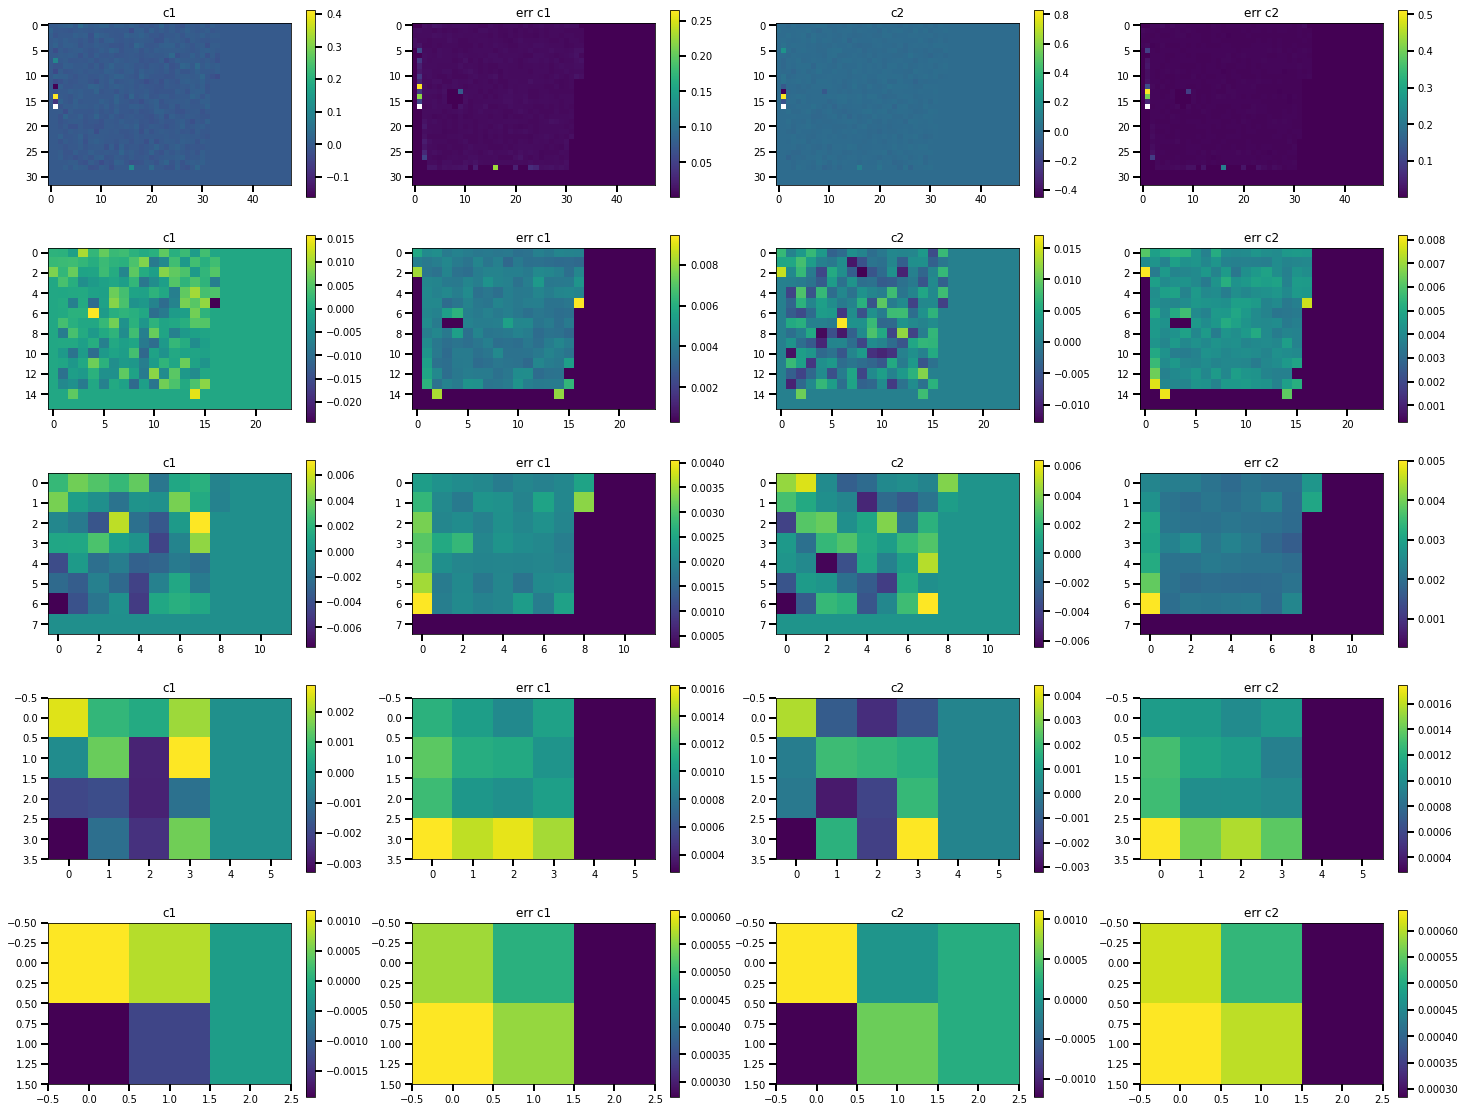

In [123]:
plt.figure(figsize=(25,20))
plt.subplot(5,4,1)
plt.imshow(c1_ngmix_025deg)
plt.colorbar()
plt.title('c1')
plt.subplot(5,4,2)
plt.imshow(err_c1_ngmix_025deg)
plt.colorbar()
plt.title('err c1')
plt.subplot(5,4,3)
plt.imshow(c2_ngmix_025deg)
plt.colorbar()
plt.title('c2')
plt.subplot(5,4,4)
plt.imshow(err_c2_ngmix_025deg)
plt.colorbar()
plt.title('err c2')

plt.subplot(5,4,5)
plt.imshow(c1_ngmix_05deg)
plt.colorbar()
plt.title('c1')
plt.subplot(5,4,6)
plt.imshow(err_c1_ngmix_05deg)
plt.colorbar()
plt.title('err c1')
plt.subplot(5,4,7)
plt.imshow(c2_ngmix_05deg)
plt.colorbar()
plt.title('c2')
plt.subplot(5,4,8)
plt.imshow(err_c2_ngmix_05deg)
plt.colorbar()
plt.title('err c2')

plt.subplot(5,4,9)
plt.imshow(c1_ngmix_1deg)
plt.colorbar()
plt.title('c1')
plt.subplot(5,4,10)
plt.imshow(err_c1_ngmix_1deg)
plt.colorbar()
plt.title('err c1')
plt.subplot(5,4,11)
plt.imshow(c2_ngmix_1deg)
plt.colorbar()
plt.title('c2')
plt.subplot(5,4,12)
plt.imshow(err_c2_ngmix_1deg)
plt.colorbar()
plt.title('err c2')

plt.subplot(5,4,13)
plt.imshow(c1_ngmix_2deg)
plt.colorbar()
plt.title('c1')
plt.subplot(5,4,14)
plt.imshow(err_c1_ngmix_2deg)
plt.colorbar()
plt.title('err c1')
plt.subplot(5,4,15)
plt.imshow(c2_ngmix_2deg)
plt.colorbar()
plt.title('c2')
plt.subplot(5,4,16)
plt.imshow(err_c2_ngmix_2deg)
plt.colorbar()
plt.title('err c2')

plt.subplot(5,4,17)
plt.imshow(c1_ngmix_4deg)
plt.colorbar()
plt.title('c1')
plt.subplot(5,4,18)
plt.imshow(err_c1_ngmix_4deg)
plt.colorbar()
plt.title('err c1')
plt.subplot(5,4,19)
plt.imshow(c2_ngmix_4deg)
plt.colorbar()
plt.title('c2')
plt.subplot(5,4,20)
plt.imshow(err_c2_ngmix_4deg)
plt.colorbar()
plt.title('err c2')
plt.savefig('./W3/c.png')
plt.show()

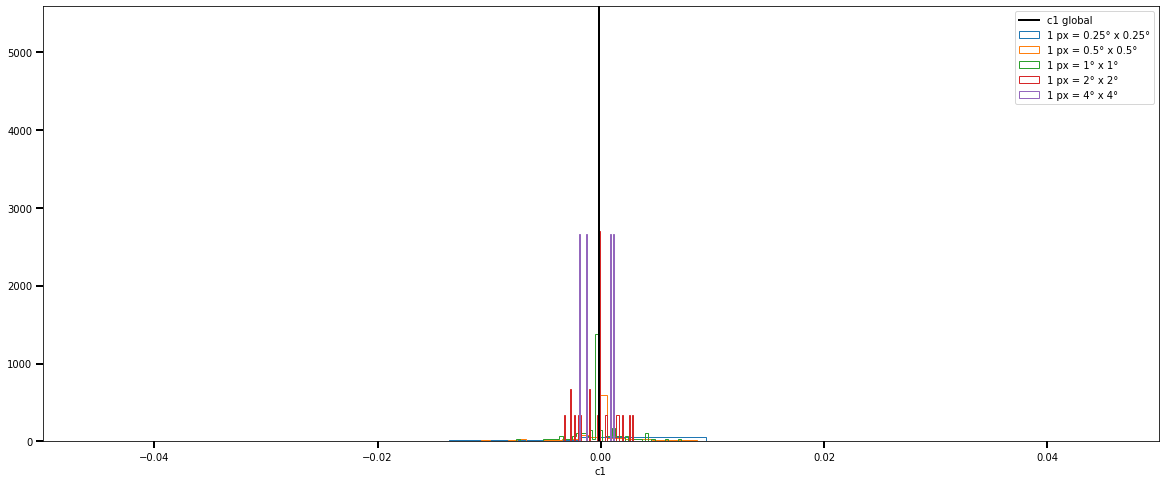

In [133]:
plt.figure(figsize=(20,8))
plt.hist(np.ravel(c1_ngmix_025deg),label='1 px = 0.25° x 0.25°',histtype='step',density=True,bins=50)
plt.hist(np.ravel(c1_ngmix_05deg),label='1 px = 0.5° x 0.5°',histtype='step',density=True,bins=50)
plt.hist(np.ravel(c1_ngmix_1deg),label='1 px = 1° x 1°',histtype='step',density=True,bins=50)
plt.hist(np.ravel(c1_ngmix_2deg),label='1 px = 2° x 2°',histtype='step',density=True,bins=50)
plt.hist(np.ravel(c1_ngmix_4deg),label='1 px = 4° x 4°',histtype='step',density=True,bins=50)
plt.axvline(x=c1_ngmix,c='k',label='c1 global')
plt.legend()
plt.xlim(-0.05,0.05)
plt.xlabel('c1')
plt.savefig('./W3/c1_hist.png')
plt.show()

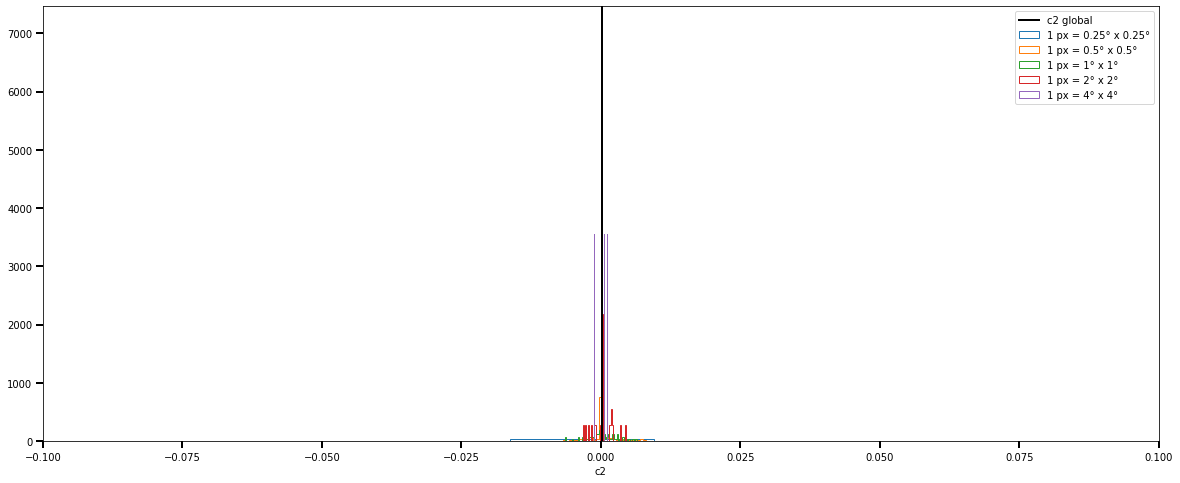

In [135]:
plt.figure(figsize=(20,8))
plt.hist(np.ravel(c2_ngmix_025deg),label='1 px = 0.25° x 0.25°',histtype='step',density=True,bins=50)
plt.hist(np.ravel(c2_ngmix_05deg),label='1 px = 0.5° x 0.5°',histtype='step',density=True,bins=50)
plt.hist(np.ravel(c2_ngmix_1deg),label='1 px = 1° x 1°',histtype='step',density=True,bins=50)
plt.hist(np.ravel(c2_ngmix_2deg),label='1 px = 2° x 2°',histtype='step',density=True,bins=50)
plt.hist(np.ravel(c2_ngmix_4deg),label='1 px = 4° x 4°',histtype='step',density=True,bins=50)
plt.axvline(x=c2_ngmix,c='k',label='c2 global')
plt.legend()
plt.xlim(-0.1,0.1)
plt.xlabel('c2')
plt.savefig('./W3/c2_hist.png')
plt.show()

In [136]:
print(np.shape(g1_final_1deg))

(1515205,)


In [137]:
print(np.shape(xx))

(1515205,)


In [67]:
# Binning e with global calibration
e1map, e2map = bin2d(xx, yy, npix=(Nx,Ny), v=(g_corr_ngmix[0],g_corr_ngmix[1]),extent=(min_x,max_x,min_y,max_y))
emap = np.array([e1map,e2map])

In [138]:
# Binning local calibration
# Calib with 0.5 deg
xx_025deg, yy_025deg = radec2xy(np.mean(ra_ngmix2_025deg), np.mean(dec_ngmix2_025deg), ra_ngmix2_025deg, dec_ngmix2_025deg)

g1map_025deg, g2map_025deg = bin2d(xx_025deg, yy_025deg, npix=(Nx,Ny), v=(g1_final_025deg,g2_final_025deg),extent=(min_x,max_x,min_y,max_y))
gmap_025deg = np.array([g1map_025deg,g2map_025deg])

g1map_dm_025deg, g2map_dm_025deg = bin2d(xx_025deg, yy_025deg, npix=(Nx,Ny), v=(g1_final_dm_025deg,g2_final_dm_025deg),extent=(min_x,max_x,min_y,max_y))
gmap_dm_025deg = np.array([g1map_dm_025deg,g2map_dm_025deg])

# Calib with 0.5 deg
xx_05deg, yy_05deg = radec2xy(np.mean(ra_ngmix2_05deg), np.mean(dec_ngmix2_05deg), ra_ngmix2_05deg, dec_ngmix2_05deg)

g1map_05deg, g2map_05deg = bin2d(xx_05deg, yy_05deg, npix=(Nx,Ny), v=(g1_final_05deg,g2_final_05deg),extent=(min_x,max_x,min_y,max_y))
gmap_05deg = np.array([g1map_05deg,g2map_05deg])

g1map_dm_05deg, g2map_dm_05deg = bin2d(xx_05deg, yy_05deg, npix=(Nx,Ny), v=(g1_final_dm_05deg,g2_final_dm_05deg),extent=(min_x,max_x,min_y,max_y))
gmap_dm_05deg = np.array([g1map_dm_05deg,g2map_dm_05deg])

# Calib with 1 deg
xx_1deg, yy_1deg = radec2xy(np.mean(ra_ngmix2_1deg), np.mean(dec_ngmix2_1deg), ra_ngmix2_1deg, dec_ngmix2_1deg)

g1map_1deg, g2map_1deg = bin2d(xx_1deg, yy_1deg, npix=(Nx,Ny), v=(g1_final_1deg,g2_final_1deg),extent=(min_x,max_x,min_y,max_y))
gmap_1deg = np.array([g1map_1deg,g2map_1deg])

g1map_dm_1deg, g2map_dm_1deg = bin2d(xx_1deg, yy_1deg, npix=(Nx,Ny), v=(g1_final_dm_1deg,g2_final_dm_1deg),extent=(min_x,max_x,min_y,max_y))
gmap_dm_1deg = np.array([g1map_dm_1deg,g2map_dm_1deg])

# Calib with 2 deg
xx_2deg, yy_2deg = radec2xy(np.mean(ra_ngmix2_2deg), np.mean(dec_ngmix2_2deg), ra_ngmix2_2deg, dec_ngmix2_2deg)

g1map_2deg, g2map_2deg = bin2d(xx_2deg, yy_2deg, npix=(Nx,Ny), v=(g1_final_2deg,g2_final_2deg),extent=(min_x,max_x,min_y,max_y))
gmap_2deg = np.array([g1map_2deg,g2map_2deg])

g1map_dm_2deg, g2map_dm_2deg = bin2d(xx_2deg, yy_2deg, npix=(Nx,Ny), v=(g1_final_dm_2deg,g2_final_dm_2deg),extent=(min_x,max_x,min_y,max_y))
gmap_dm_2deg = np.array([g1map_dm_2deg,g2map_dm_2deg])

# Calib with 4 deg
xx_4deg, yy_4deg = radec2xy(np.mean(ra_ngmix2_4deg), np.mean(dec_ngmix2_4deg), ra_ngmix2_4deg, dec_ngmix2_4deg)

g1map_4deg, g2map_4deg = bin2d(xx_4deg, yy_4deg, npix=(Nx,Ny), v=(g1_final_4deg,g2_final_4deg),extent=(min_x,max_x,min_y,max_y))
gmap_4deg = np.array([g1map_4deg,g2map_4deg])

g1map_dm_4deg, g2map_dm_4deg = bin2d(xx_4deg, yy_4deg, npix=(Nx,Ny), v=(g1_final_dm_4deg,g2_final_dm_4deg),extent=(min_x,max_x,min_y,max_y))
gmap_dm_4deg = np.array([g1map_dm_4deg,g2map_dm_4deg])

In [69]:
# Binning for dm = -0.0208  and dm = -0.0208 +/- random G(0,0.0012)
# 4 deg
xx_4deg_y3, yy_4deg_y3 = radec2xy(np.mean(ra_ngmix2_4deg_y3), np.mean(dec_ngmix2_4deg_y3), ra_ngmix2_4deg_y3, dec_ngmix2_4deg_y3)
g1map_dm_4deg_y3, g2map_dm_4deg_y3 = bin2d(xx_4deg_y3, yy_4deg_y3, npix=(Nx,Ny), v=(g1_final_dm_4deg_y3,g2_final_dm_4deg_y3),extent=(min_x,max_x,min_y,max_y))
gmap_dm_4deg_y3 = np.array([g1map_dm_4deg_y3,g2map_dm_4deg_y3])

xx_4deg_y3dev, yy_4deg_y3dev = radec2xy(np.mean(ra_ngmix2_4deg_y3dev), np.mean(dec_ngmix2_4deg_y3dev), ra_ngmix2_4deg_y3dev, dec_ngmix2_4deg_y3dev)
g1map_dm_4deg_y3dev, g2map_dm_4deg_y3dev = bin2d(xx_4deg_y3dev, yy_4deg_y3dev, npix=(Nx,Ny), v=(g1_final_dm_4deg_y3dev,g2_final_dm_4deg_y3dev),extent=(min_x,max_x,min_y,max_y))
gmap_dm_4deg_y3dev = np.array([g1map_dm_4deg_y3dev,g2map_dm_4deg_y3dev])

# 2 deg
xx_2deg_y3, yy_2deg_y3 = radec2xy(np.mean(ra_ngmix2_2deg_y3), np.mean(dec_ngmix2_2deg_y3), ra_ngmix2_2deg_y3, dec_ngmix2_2deg_y3)
g1map_dm_2deg_y3, g2map_dm_2deg_y3 = bin2d(xx_2deg_y3, yy_2deg_y3, npix=(Nx,Ny), v=(g1_final_dm_2deg_y3,g2_final_dm_2deg_y3),extent=(min_x,max_x,min_y,max_y))
gmap_dm_2deg_y3 = np.array([g1map_dm_2deg_y3,g2map_dm_2deg_y3])

xx_2deg_y3dev, yy_2deg_y3dev = radec2xy(np.mean(ra_ngmix2_2deg_y3dev), np.mean(dec_ngmix2_2deg_y3dev), ra_ngmix2_2deg_y3dev, dec_ngmix2_2deg_y3dev)
g1map_dm_2deg_y3dev, g2map_dm_2deg_y3dev = bin2d(xx_2deg_y3dev, yy_2deg_y3dev, npix=(Nx,Ny), v=(g1_final_dm_2deg_y3dev,g2_final_dm_2deg_y3dev),extent=(min_x,max_x,min_y,max_y))
gmap_dm_2deg_y3dev = np.array([g1map_dm_2deg_y3dev,g2map_dm_2deg_y3dev])

# 1 deg
xx_1deg_y3, yy_1deg_y3 = radec2xy(np.mean(ra_ngmix2_1deg_y3), np.mean(dec_ngmix2_1deg_y3), ra_ngmix2_1deg_y3, dec_ngmix2_1deg_y3)
g1map_dm_1deg_y3, g2map_dm_1deg_y3 = bin2d(xx_1deg_y3, yy_1deg_y3, npix=(Nx,Ny), v=(g1_final_dm_1deg_y3,g2_final_dm_1deg_y3),extent=(min_x,max_x,min_y,max_y))
gmap_dm_1deg_y3 = np.array([g1map_dm_1deg_y3,g2map_dm_1deg_y3])

xx_1deg_y3dev, yy_1deg_y3dev = radec2xy(np.mean(ra_ngmix2_1deg_y3dev), np.mean(dec_ngmix2_1deg_y3dev), ra_ngmix2_1deg_y3dev, dec_ngmix2_1deg_y3dev)
g1map_dm_1deg_y3dev, g2map_dm_1deg_y3dev = bin2d(xx_1deg_y3dev, yy_1deg_y3dev, npix=(Nx,Ny), v=(g1_final_dm_1deg_y3dev,g2_final_dm_1deg_y3dev),extent=(min_x,max_x,min_y,max_y))
gmap_dm_1deg_y3dev = np.array([g1map_dm_1deg_y3dev,g2map_dm_1deg_y3dev])

# 0.5 deg
xx_05deg_y3, yy_05deg_y3 = radec2xy(np.mean(ra_ngmix2_05deg_y3), np.mean(dec_ngmix2_05deg_y3), ra_ngmix2_05deg_y3, dec_ngmix2_05deg_y3)
g1map_dm_05deg_y3, g2map_dm_05deg_y3 = bin2d(xx_05deg_y3, yy_05deg_y3, npix=(Nx,Ny), v=(g1_final_dm_05deg_y3,g2_final_dm_05deg_y3),extent=(min_x,max_x,min_y,max_y))
gmap_dm_05deg_y3 = np.array([g1map_dm_05deg_y3,g2map_dm_05deg_y3])

xx_05deg_y3dev, yy_05deg_y3dev = radec2xy(np.mean(ra_ngmix2_05deg_y3dev), np.mean(dec_ngmix2_05deg_y3dev), ra_ngmix2_05deg_y3dev, dec_ngmix2_05deg_y3dev)
g1map_dm_05deg_y3dev, g2map_dm_05deg_y3dev = bin2d(xx_05deg_y3dev, yy_05deg_y3dev, npix=(Nx,Ny), v=(g1_final_dm_05deg_y3dev,g2_final_dm_05deg_y3dev),extent=(min_x,max_x,min_y,max_y))
gmap_dm_05deg_y3dev = np.array([g1map_dm_05deg_y3dev,g2map_dm_05deg_y3dev])

# 0.25 deg
xx_025deg_y3, yy_025deg_y3 = radec2xy(np.mean(ra_ngmix2_025deg_y3), np.mean(dec_ngmix2_025deg_y3), ra_ngmix2_025deg_y3, dec_ngmix2_025deg_y3)
g1map_dm_025deg_y3, g2map_dm_025deg_y3 = bin2d(xx_025deg_y3, yy_025deg_y3, npix=(Nx,Ny), v=(g1_final_dm_025deg_y3,g2_final_dm_025deg_y3),extent=(min_x,max_x,min_y,max_y))
gmap_dm_025deg_y3 = np.array([g1map_dm_025deg_y3,g2map_dm_025deg_y3])

xx_025deg_y3dev, yy_025deg_y3dev = radec2xy(np.mean(ra_ngmix2_025deg_y3dev), np.mean(dec_ngmix2_025deg_y3dev), ra_ngmix2_025deg_y3dev, dec_ngmix2_025deg_y3dev)
g1map_dm_025deg_y3dev, g2map_dm_025deg_y3dev = bin2d(xx_025deg_y3dev, yy_025deg_y3dev, npix=(Nx,Ny), v=(g1_final_dm_025deg_y3dev,g2_final_dm_025deg_y3dev),extent=(min_x,max_x,min_y,max_y))
gmap_dm_025deg_y3dev = np.array([g1map_dm_025deg_y3dev,g2map_dm_025deg_y3dev])

In [70]:
# Quantity for correlation
psf1map, psf2map = bin2d(xx, yy, npix=(Nx,Ny), v=(Psf1,Psf2),extent=(min_x,max_x,min_y,max_y))
psf = np.array([psf1map,psf2map])

module_psf_map, size_gal_map, nepoch_map, mag_map, snr_map = bin2d(xx, yy, npix=(Nx,Ny), v=(module_psf,size_gal,nepoch,mag,snr_win),extent=(min_x,max_x,min_y,max_y))

In [71]:
def bin_Rshear(npix):
    # Binning of R shear on npix
    
    R_11, R_22, R_12, R_21 = bin2d(xx, yy, npix=npix, v=(gal_metacal_ngmix.R_shear[0,0,:],gal_metacal_ngmix.R_shear[1,1,:],gal_metacal_ngmix.R_shear[0,1,:],gal_metacal_ngmix.R_shear[1,0,:]),extent=(min_x,max_x,min_y,max_y)) 
    Rmap = np.array([[R_11,R_12],[R_21,R_22]])
    
    return Rmap

In [72]:
# R shear with binning on different px
Rmap1 = bin_Rshear(1)
Rmap5 = bin_Rshear(5)
Rmap10 = bin_Rshear(10)
Rmap32 = bin_Rshear(32)
Rmap64 = bin_Rshear(64)
Rmap128 = bin_Rshear(128)
Rmap256 = bin_Rshear(256)
Rmap512 = bin_Rshear(512)

In [73]:
def compute_R_real_std(npix_x,npix_y,factor,R):
    # Compute std of R with jackknife spatial
    
    R_real_std = np.zeros((2,2,npix_y,npix_x))

    for i in range(npix_y):
        for j in range(npix_x):
            if (np.sum(R[0,0,factor*i:factor*(i+1),factor*j:factor*(j+1)])!=0):
                R_real_std[0,0,i,j] = jackknif_weighted_average(np.ravel(R[0,0,factor*i:factor*(i+1),factor*j:factor*(j+1)]), np.ones_like(np.ravel(R[0,0,factor*i:factor*(i+1),factor*j:factor*(j+1)])))[1]
            else:
                R_real_std[0,0,i,j] = np.nan
                
            if (np.sum(R[1,1,factor*i:factor*(i+1),factor*j:factor*(j+1)])!=0):
                R_real_std[1,1,i,j] = jackknif_weighted_average(np.ravel(R[1,1,factor*i:factor*(i+1),factor*j:factor*(j+1)]), np.ones_like(np.ravel(R[1,1,factor*i:factor*(i+1),factor*j:factor*(j+1)])))[1]
            else:
                R_real_std[1,1,i,j] = np.nan
                
            if (np.sum(R[0,1,factor*i:factor*(i+1),factor*j:factor*(j+1)])!=0):
                R_real_std[0,1,i,j] = jackknif_weighted_average(np.ravel(R[0,1,factor*i:factor*(i+1),factor*j:factor*(j+1)]), np.ones_like(np.ravel(R[0,1,factor*i:factor*(i+1),factor*j:factor*(j+1)])))[1]
            else:
                R_real_std[0,1,i,j] = np.nan
                
            if (np.sum(R[1,0,factor*i:factor*(i+1),factor*j:factor*(j+1)])!=0):
                R_real_std[1,0,i,j] = jackknif_weighted_average(np.ravel(R[1,0,factor*i:factor*(i+1),factor*j:factor*(j+1)]), np.ones_like(np.ravel(R[1,0,factor*i:factor*(i+1),factor*j:factor*(j+1)])))[1]
            else:
                R_real_std[1,0,i,j] = np.nan
                
    return R_real_std

In [74]:
# Std of R selec 1 deg thanks to 2x2 px of R selec 0.5 deg
R_selec_real_std_1deg = compute_R_real_std(size_deg_x,size_deg_y,2,R_selec_05deg)

# Std of R selec 2 deg thanks to 2x2 px of R selec 1 deg
R_selec_real_std_2deg = compute_R_real_std(int(size_deg_x/2),int(size_deg_y/2),2,R_selec_1deg)

# Std of R selec 4 deg thanks to 4x4 px of R selec 1 deg
R_selec_real_std_4deg = compute_R_real_std(int(size_deg_x/4),int(size_deg_y/4),4,R_selec_1deg)

In [75]:
# Std of R selec 2 deg thanks to 4x4 px of R selec 0.5 deg
R_selec_real_std_2deg_from05 = compute_R_real_std(int(size_deg_x/2),int(size_deg_y/2),4,R_selec_05deg)

# Std of R selec 4 deg thanks to 8x8 px of R selec 0.5 deg
R_selec_real_std_4deg_from05 = compute_R_real_std(int(size_deg_x/4),int(size_deg_y/4),8,R_selec_05deg)

In [76]:
# Std of R selec 05deg thanks to 2x2 px of R selec 0.25 deg
R_selec_real_std_05deg_from025 = compute_R_real_std(size_deg_x*2,size_deg_y*2,2,R_selec_025deg)

In [77]:
# n gal needed
ngal_05deg = bin2d(xx,yy,npix=(size_deg_x*2,size_deg_y*2),extent=(min_x,max_x,min_y,max_y))
ngal_025deg = bin2d(xx,yy,npix=(size_deg_x*4,size_deg_y*4),extent=(min_x,max_x,min_y,max_y))
ngal_1deg = bin2d(xx,yy,npix=(size_deg_x,size_deg_y),extent=(min_x,max_x,min_y,max_y))
ngal_2deg = bin2d(xx,yy,npix=(int(size_deg_x/2),int(size_deg_y/2)),extent=(min_x,max_x,min_y,max_y))
ngal_4deg = bin2d(xx,yy,npix=(int(size_deg_x/4),int(size_deg_y/4)),extent=(min_x,max_x,min_y,max_y))

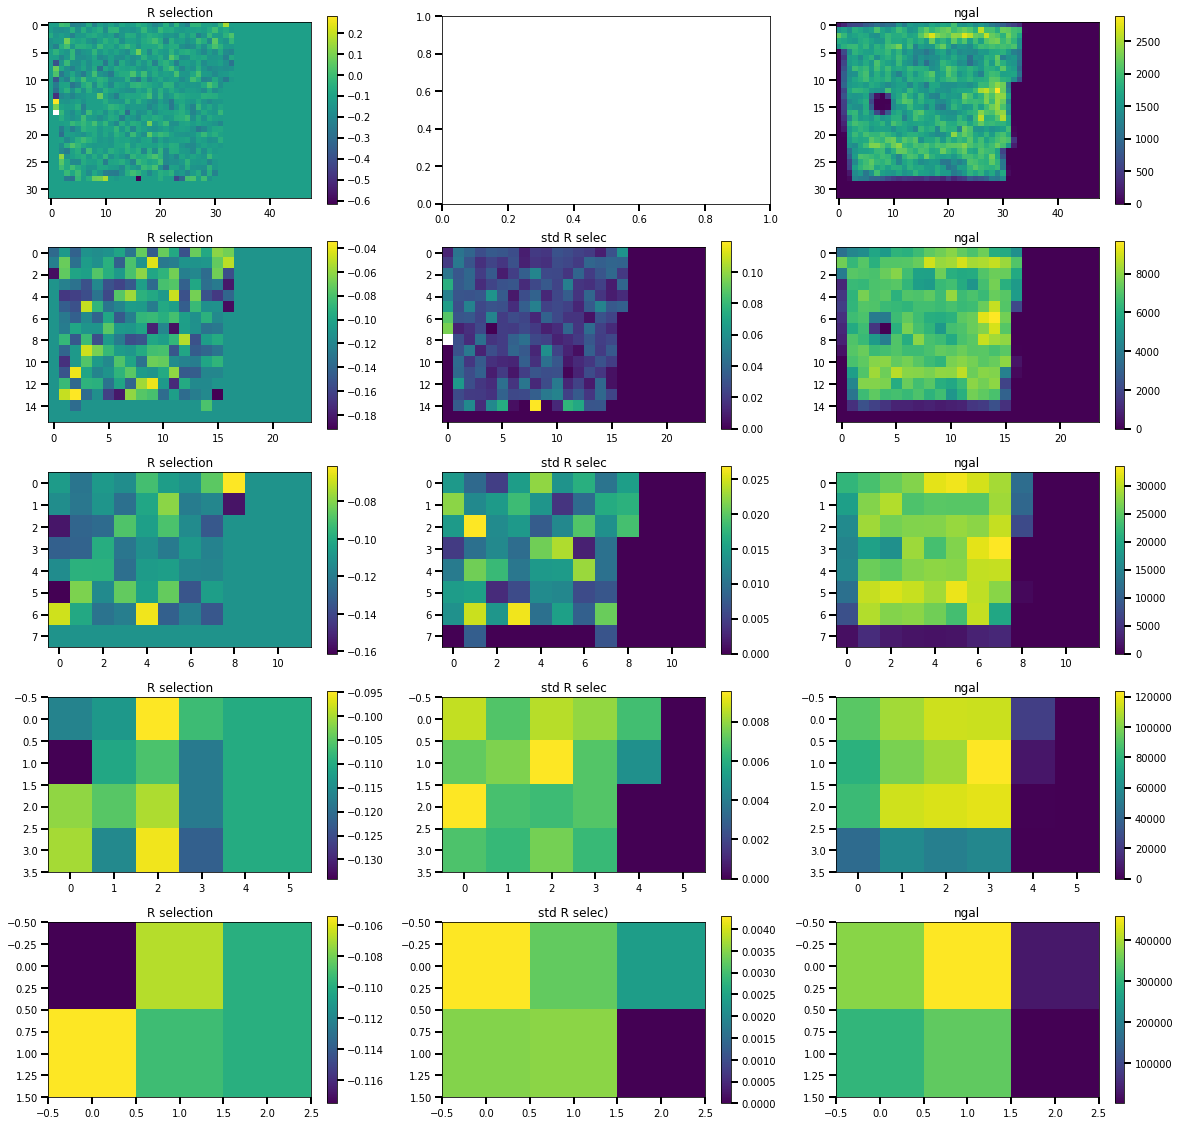

In [140]:
# Plot R_11 selec, its std, ngal
plt.figure(figsize=(20,20))
plt.subplot(5,3,1)
plt.imshow(R_selec_025deg[0,0,:,:])
plt.colorbar()
plt.title('R selection')
plt.subplot(5,3,2)
plt.subplot(5,3,3)
plt.imshow(ngal_025deg)
plt.title('ngal')
plt.colorbar()

plt.subplot(5,3,4)
plt.imshow(R_selec_05deg[0,0,:,:])
plt.colorbar()
plt.title('R selection')
plt.subplot(5,3,5)
plt.imshow(R_selec_real_std_05deg_from025[0,0,:,:])
plt.colorbar()
plt.title('std R selec')
plt.subplot(5,3,6)
plt.imshow(ngal_05deg)
plt.title('ngal')
plt.colorbar()

plt.subplot(5,3,7)
plt.imshow(R_selec_1deg[0,0,:,:])
plt.colorbar()
plt.title('R selection')
plt.subplot(5,3,8)
plt.imshow(R_selec_real_std_1deg[0,0,:,:])
plt.colorbar()
plt.title('std R selec')
plt.subplot(5,3,9)
plt.imshow(ngal_1deg)
plt.title('ngal')
plt.colorbar()

plt.subplot(5,3,10)
plt.imshow(R_selec_2deg[0,0,:,:])
plt.colorbar()
plt.title('R selection')
plt.subplot(5,3,11)
plt.imshow(R_selec_real_std_2deg_from05[0,0,:,:])
plt.colorbar()
plt.title('std R selec')
plt.subplot(5,3,12)
plt.imshow(ngal_2deg)
plt.title('ngal')
plt.colorbar()

plt.subplot(5,3,13)
plt.imshow(R_selec_4deg[0,0,:,:])
plt.colorbar()
plt.title('R selection')
plt.subplot(5,3,14)
plt.imshow(R_selec_real_std_4deg_from05[0,0,:,:])
plt.colorbar()
plt.title('std R selec)')
plt.subplot(5,3,15)
plt.imshow(ngal_4deg)
plt.title('ngal')
plt.colorbar()
plt.savefig('./W3/R_selec.png')
plt.show()

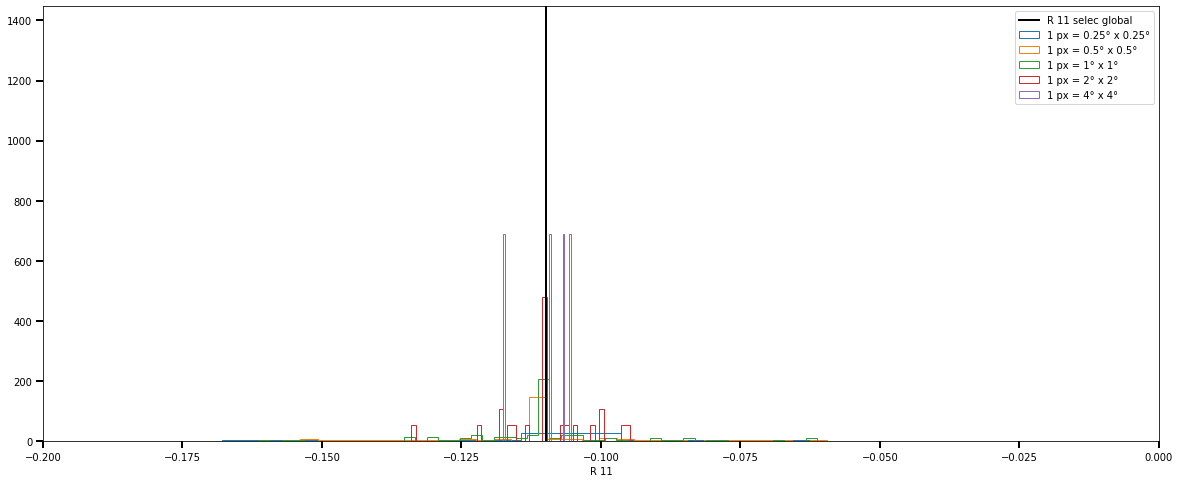

In [142]:
plt.figure(figsize=(20,8))
plt.hist(np.ravel(R_selec_025deg[0,0,:,:]),label='1 px = 0.25° x 0.25°',histtype='step',density=True,bins=50)
plt.hist(np.ravel(R_selec_05deg[0,0,:,:]),label='1 px = 0.5° x 0.5°',histtype='step',density=True,bins=50)
plt.hist(np.ravel(R_selec_1deg[0,0,:,:]),label='1 px = 1° x 1°',histtype='step',density=True,bins=50)
plt.hist(np.ravel(R_selec_2deg[0,0,:,:]),label='1 px = 2° x 2°',histtype='step',density=True,bins=50)
plt.hist(np.ravel(R_selec_4deg[0,0,:,:]),label='1 px = 4° x 4°',histtype='step',density=True,bins=50)
plt.axvline(x=R_selec_moy[0,0],c='k',label='R 11 selec global')
plt.legend()
plt.xlim(-0.2,0)
plt.xlabel('R 11')
plt.savefig('./W3/Rselec_hist.png')
plt.show()

In [88]:
ind_change_025deg = np.shape((np.where(ngal_025deg < (np.mean(ngal_025deg))/2))[1])
ind_change_05deg = np.shape((np.where(ngal_05deg < (np.mean(ngal_05deg))/2))[1])
ind_change_1deg = np.shape((np.where(ngal_1deg < (np.mean(ngal_1deg))/2))[1])
ind_change_2deg = np.shape((np.where(ngal_2deg < (np.mean(ngal_2deg))/2))[1])
ind_change_4deg = np.shape((np.where(ngal_4deg < (np.mean(ngal_4deg))/2))[1])

In [89]:
tot_025deg = (size_deg_x*4)*(size_deg_y*4)
tot_05deg = (size_deg_x*2)*(size_deg_y*2)
tot_1deg = (size_deg_x)*(size_deg_y)
tot_2deg = (int(size_deg_x/2))*(int(size_deg_y/2))
tot_4deg = (int(size_deg_x/4))*(int(size_deg_y/4))

In [94]:
old_size = 8.614568497714435*7.192988571604766
new_size = 12*8
size_add_prct = 100-(old_size*100/new_size) # what we add in percent
print(size_add_prct)

35.45365338191003


In [95]:
change_prct_025deg = ind_change_025deg[0]*100/tot_025deg - size_add_prct
change_prct_05deg = ind_change_05deg[0]*100/tot_05deg - size_add_prct
change_prct_1deg = ind_change_1deg[0]*100/tot_1deg - size_add_prct
change_prct_2deg = ind_change_2deg[0]*100/tot_2deg - size_add_prct
change_prct_4deg = ind_change_4deg[0]*100/tot_4deg - size_add_prct

In [96]:
x=np.array([0.25,0.5,1,2,4])
y=np.array([change_prct_025deg,change_prct_05deg,change_prct_1deg,change_prct_2deg,change_prct_4deg])

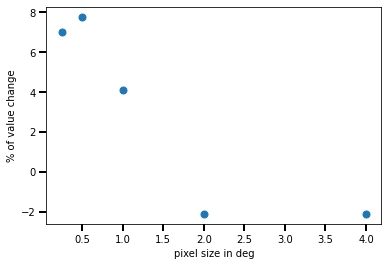

In [97]:
plt.figure()
plt.scatter(x,y)
plt.xlabel('pixel size in deg')
plt.ylabel('% of value change')
plt.show()

In [143]:
# R shear bin needed
R_11, R_22, R_12, R_21 = bin2d(xx, yy, npix=(size_deg_x*4,size_deg_y*4), v=(gal_metacal_ngmix.R_shear[0,0,:],gal_metacal_ngmix.R_shear[1,1,:],gal_metacal_ngmix.R_shear[0,1,:],gal_metacal_ngmix.R_shear[1,0,:]),extent=(min_x,max_x,min_y,max_y)) 
Rmap_025deg = np.array([[R_11,R_12],[R_21,R_22]])

R_11, R_22, R_12, R_21 = bin2d(xx, yy, npix=(size_deg_x*2,size_deg_y*2), v=(gal_metacal_ngmix.R_shear[0,0,:],gal_metacal_ngmix.R_shear[1,1,:],gal_metacal_ngmix.R_shear[0,1,:],gal_metacal_ngmix.R_shear[1,0,:]),extent=(min_x,max_x,min_y,max_y)) 
Rmap_05deg = np.array([[R_11,R_12],[R_21,R_22]])

R_11, R_22, R_12, R_21 = bin2d(xx, yy, npix=(size_deg_x,size_deg_y), v=(gal_metacal_ngmix.R_shear[0,0,:],gal_metacal_ngmix.R_shear[1,1,:],gal_metacal_ngmix.R_shear[0,1,:],gal_metacal_ngmix.R_shear[1,0,:]),extent=(min_x,max_x,min_y,max_y)) 
Rmap_1deg = np.array([[R_11,R_12],[R_21,R_22]])

R_11, R_22, R_12, R_21 = bin2d(xx, yy, npix=(int(size_deg_x/2),int(size_deg_y/2)), v=(gal_metacal_ngmix.R_shear[0,0,:],gal_metacal_ngmix.R_shear[1,1,:],gal_metacal_ngmix.R_shear[0,1,:],gal_metacal_ngmix.R_shear[1,0,:]),extent=(min_x,max_x,min_y,max_y)) 
Rmap_2deg = np.array([[R_11,R_12],[R_21,R_22]])

R_11, R_22, R_12, R_21 = bin2d(xx, yy, npix=(int(size_deg_x/4),int(size_deg_y/4)), v=(gal_metacal_ngmix.R_shear[0,0,:],gal_metacal_ngmix.R_shear[1,1,:],gal_metacal_ngmix.R_shear[0,1,:],gal_metacal_ngmix.R_shear[1,0,:]),extent=(min_x,max_x,min_y,max_y)) 
Rmap_4deg = np.array([[R_11,R_12],[R_21,R_22]])

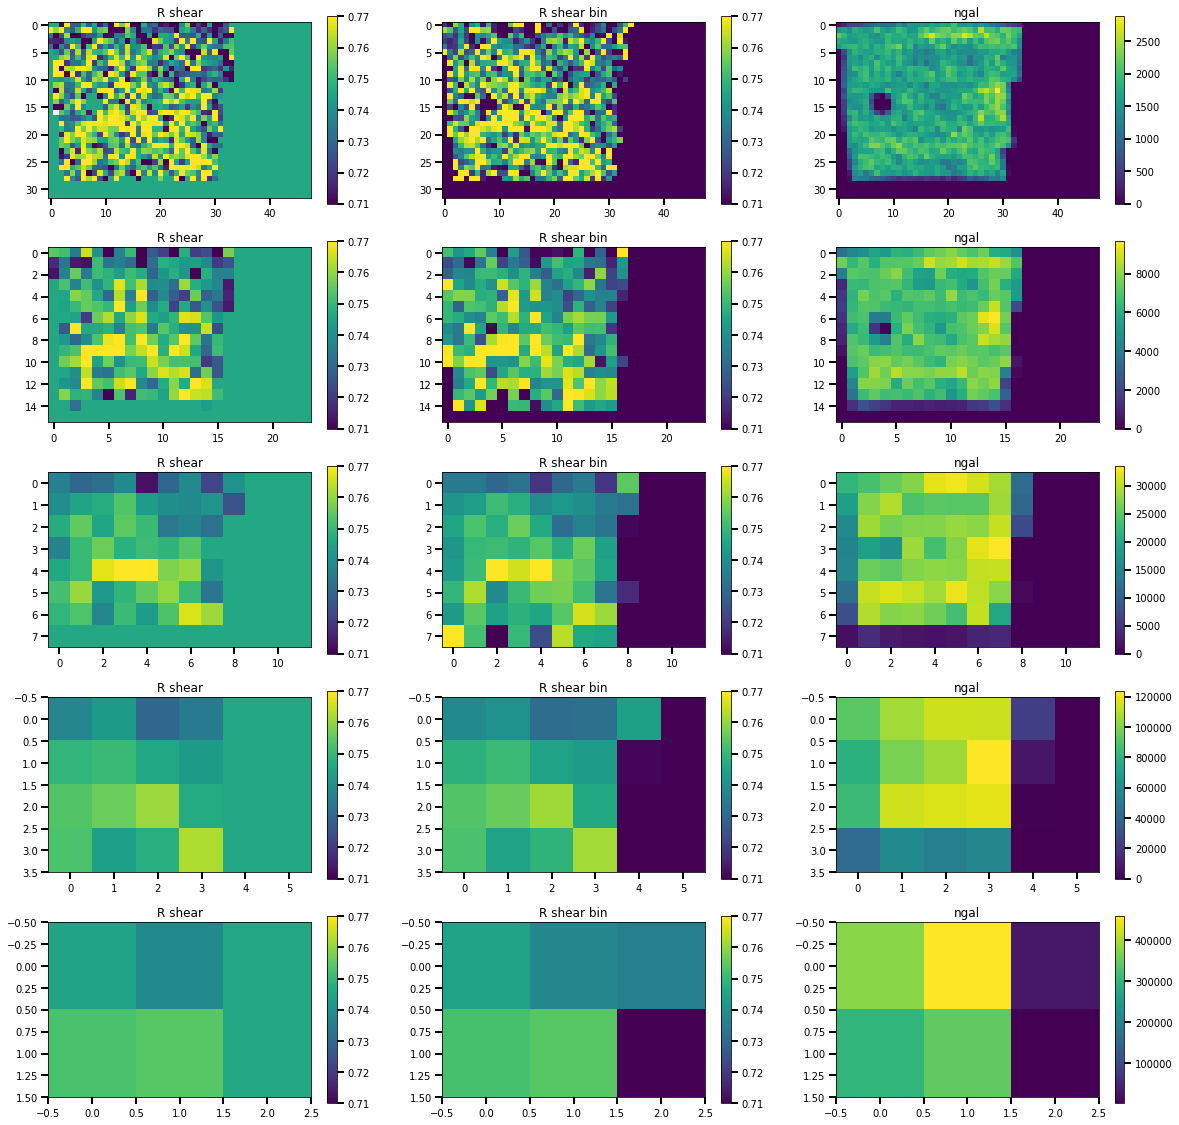

In [144]:
# Plot R shear, R shear bin, ngal
plt.figure(figsize=(20,20))
plt.subplot(5,3,1)
plt.imshow(R_shear_025deg[0,0,:,:])
plt.colorbar()
plt.clim(0.71,0.77)
plt.title('R shear')
plt.subplot(5,3,2)
plt.imshow(Rmap_025deg[0,0,:,:])
plt.colorbar()
plt.clim(0.71,0.77)
plt.title('R shear bin')
plt.subplot(5,3,3)
plt.imshow(ngal_025deg)
plt.title('ngal')
plt.colorbar()

plt.subplot(5,3,4)
plt.imshow(R_shear_05deg[0,0,:,:])
plt.colorbar()
plt.clim(0.71,0.77)
plt.title('R shear')
plt.subplot(5,3,5)
plt.imshow(Rmap_05deg[0,0,:,:])
plt.colorbar()
plt.clim(0.71,0.77)
plt.title('R shear bin')
plt.subplot(5,3,6)
plt.imshow(ngal_05deg)
plt.title('ngal')
plt.colorbar()

plt.subplot(5,3,7)
plt.imshow(R_shear_1deg[0,0,:,:])
plt.colorbar()
plt.clim(0.71,0.77)
plt.title('R shear')
plt.subplot(5,3,8)
plt.imshow(Rmap_1deg[0,0,:,:])
plt.colorbar()
plt.clim(0.71,0.77)
plt.title('R shear bin')
plt.subplot(5,3,9)
plt.imshow(ngal_1deg)
plt.title('ngal')
plt.colorbar()

plt.subplot(5,3,10)
plt.imshow(R_shear_2deg[0,0,:,:])
plt.colorbar()
plt.clim(0.71,0.77)
plt.title('R shear')
plt.subplot(5,3,11)
plt.imshow(Rmap_2deg[0,0,:,:])
plt.colorbar()
plt.clim(0.71,0.77)
plt.title('R shear bin')
plt.subplot(5,3,12)
plt.imshow(ngal_2deg)
plt.title('ngal')
plt.colorbar()

plt.subplot(5,3,13)
plt.imshow(R_shear_4deg[0,0,:,:])
plt.colorbar()
plt.clim(0.71,0.77)
plt.title('R shear')
plt.subplot(5,3,14)
plt.imshow(Rmap_4deg[0,0,:,:])
plt.colorbar()
plt.clim(0.71,0.77)
plt.title('R shear bin')
plt.subplot(5,3,15)
plt.imshow(ngal_4deg)
plt.title('ngal')
plt.colorbar()
plt.savefig('./W3/R_shear.png')
plt.show()

In [100]:
# Std of R shear
R_shear_real_std_05deg = compute_R_real_std(size_deg_x*2,size_deg_y*2,2,R_shear_025deg)
R_shear_real_std_1deg = compute_R_real_std(size_deg_x,size_deg_y,2,R_shear_05deg)
R_shear_real_std_2deg = compute_R_real_std(int(size_deg_x/2),int(size_deg_y/2),4,R_shear_05deg)
R_shear_real_std_4deg = compute_R_real_std(int(size_deg_x/4),int(size_deg_y/4),8,R_shear_05deg)

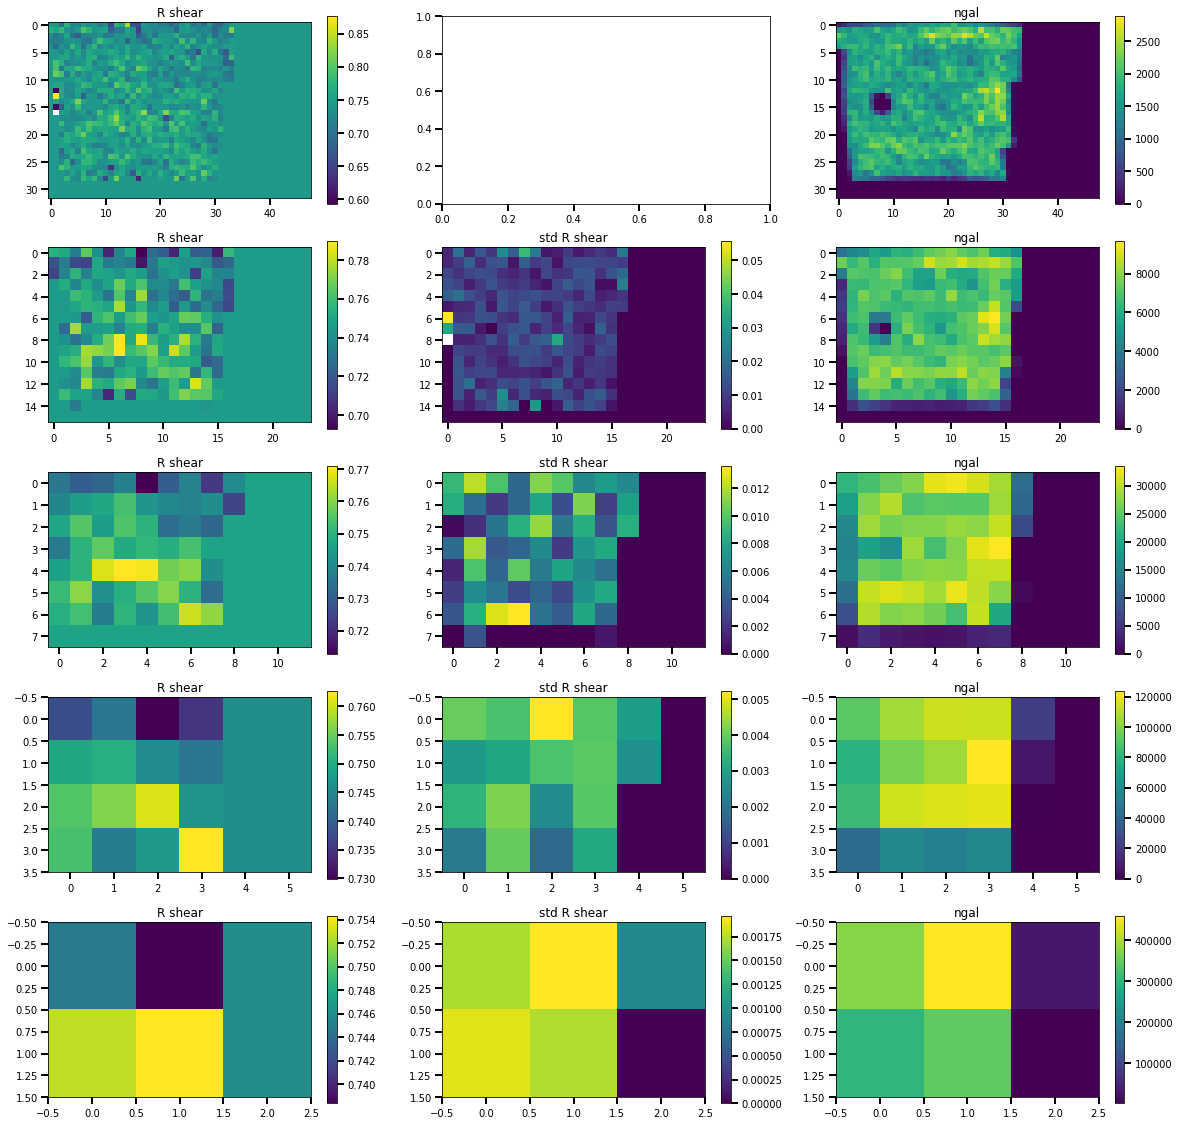

In [145]:
plt.figure(figsize=(20,20))
plt.subplot(5,3,1)
plt.imshow(R_shear_025deg[0,0,:,:])
plt.colorbar()
plt.title('R shear')
plt.subplot(5,3,2)
plt.subplot(5,3,3)
plt.imshow(ngal_025deg)
plt.title('ngal')
plt.colorbar()

plt.subplot(5,3,4)
plt.imshow(R_shear_05deg[0,0,:,:])
plt.colorbar()
plt.title('R shear')
plt.subplot(5,3,5)
plt.imshow(R_shear_real_std_05deg[0,0,:,:])
plt.colorbar()
plt.title('std R shear')
plt.subplot(5,3,6)
plt.imshow(ngal_05deg)
plt.title('ngal')
plt.colorbar()

plt.subplot(5,3,7)
plt.imshow(R_shear_1deg[0,0,:,:])
plt.colorbar()
plt.title('R shear')
plt.subplot(5,3,8)
plt.imshow(R_shear_real_std_1deg[0,0,:,:])
plt.colorbar()
plt.title('std R shear')
plt.subplot(5,3,9)
plt.imshow(ngal_1deg)
plt.title('ngal')
plt.colorbar()

plt.subplot(5,3,10)
plt.imshow(R_shear_2deg[0,0,:,:])
plt.colorbar()
plt.title('R shear')
plt.subplot(5,3,11)
plt.imshow(R_shear_real_std_2deg[0,0,:,:])
plt.colorbar()
plt.title('std R shear')
plt.subplot(5,3,12)
plt.imshow(ngal_2deg)
plt.title('ngal')
plt.colorbar()

plt.subplot(5,3,13)
plt.imshow(R_shear_4deg[0,0,:,:])
plt.colorbar()
plt.title('R shear')
plt.subplot(5,3,14)
plt.imshow(R_shear_real_std_4deg[0,0,:,:])
plt.colorbar()
plt.title('std R shear')
plt.subplot(5,3,15)
plt.imshow(ngal_4deg)
plt.title('ngal')
plt.colorbar()
plt.savefig('./W3/R_shear_std.png')
plt.show()

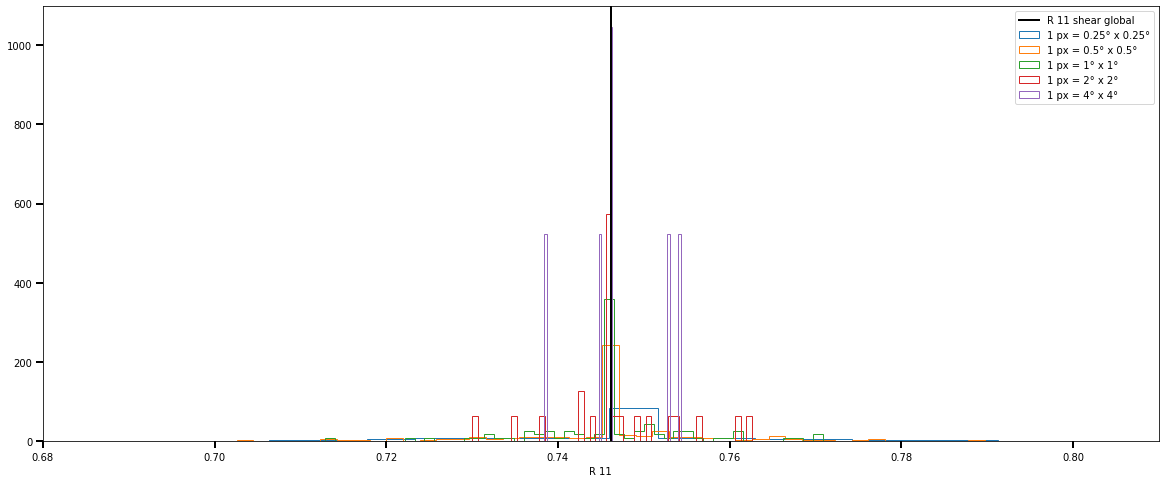

In [147]:
plt.figure(figsize=(20,8))
plt.hist(np.ravel(R_shear_025deg[0,0,:,:]),label='1 px = 0.25° x 0.25°',histtype='step',density=True,bins=50)
plt.hist(np.ravel(R_shear_05deg[0,0,:,:]),label='1 px = 0.5° x 0.5°',histtype='step',density=True,bins=50)
plt.hist(np.ravel(R_shear_1deg[0,0,:,:]),label='1 px = 1° x 1°',histtype='step',density=True,bins=50)
plt.hist(np.ravel(R_shear_2deg[0,0,:,:]),label='1 px = 2° x 2°',histtype='step',density=True,bins=50)
plt.hist(np.ravel(R_shear_4deg[0,0,:,:]),label='1 px = 4° x 4°',histtype='step',density=True,bins=50)
plt.axvline(x=R_shear_moy[0,0],c='k',label='R 11 shear global')
plt.legend()
plt.xlim(0.68,0.81)
plt.xlabel('R 11')
plt.savefig('./W3/Rshear_hist.png')
plt.show()

In [103]:
def replace_Rshear(npix,R):
    # Replace value were there is low number of galaxy per mean value
    
    ngal = bin2d(xx, yy, npix=npix,extent=(min_x,max_x,min_y,max_y))
    ind = np.where(ngal  < (np.mean(ngal))/2)
    Rmask = np.copy(R)
    Rmask[0,0,ind[0],ind[1]] = Rmap1[0,0,:,:]
    Rmask[0,1,ind[0],ind[1]] = Rmap1[0,1,:,:]
    Rmask[1,0,ind[0],ind[1]] = Rmap1[1,0,:,:]
    Rmask[1,1,ind[0],ind[1]] = Rmap1[1,1,:,:]
    
    return Rmask

In [104]:
ngaltot = bin2d(xx, yy, npix=(Nx,Ny),extent=(min_x,max_x,min_y,max_y))

In [105]:
# R shear with different binning, where value were there is low number of galaxy is replace by the mean value of Rshear
Rmask5 = replace_Rshear(5,Rmap5)
Rmask10 = replace_Rshear(10,Rmap10)
Rmask32 = replace_Rshear(32,Rmap32)
Rmask64 = replace_Rshear(64,Rmap64)
Rmask128 = replace_Rshear(128,Rmap128)
Rmask256 = replace_Rshear(256,Rmap256)
Rmask512 = replace_Rshear(512,Rmap512)

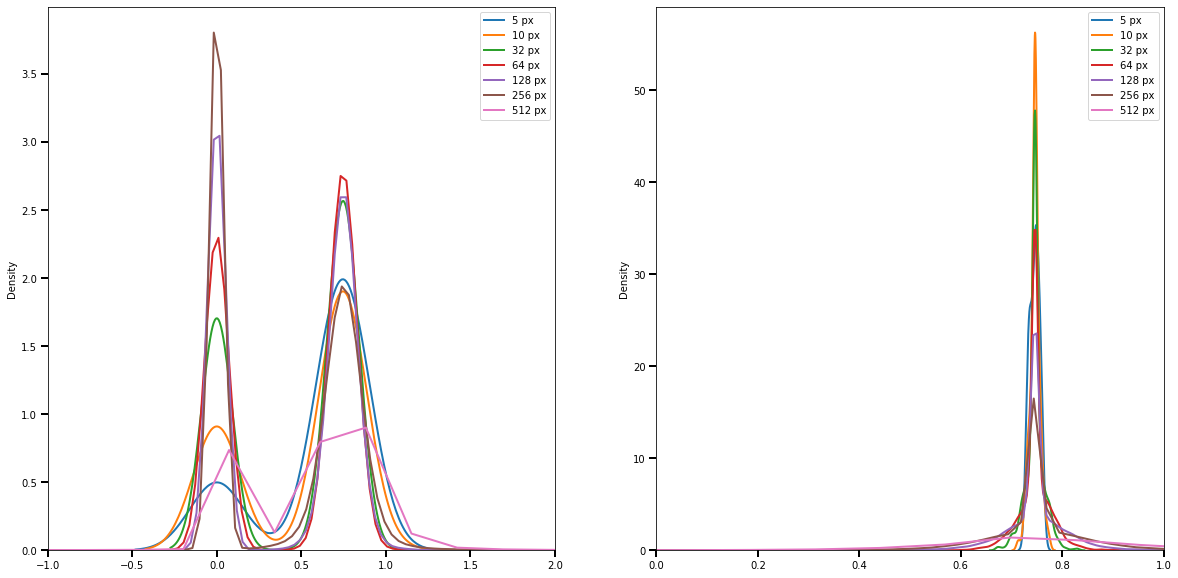

In [106]:
# Distribution of R11 before and after changing some values
plt.figure(figsize=(20,10))
plt.subplot(1,2,1)
sns.kdeplot(np.ravel(Rmap5[0,0,:,:]),label='5 px')
sns.kdeplot(np.ravel(Rmap10[0,0,:,:]),label='10 px')
sns.kdeplot(np.ravel(Rmap32[0,0,:,:]),label='32 px')
sns.kdeplot(np.ravel(Rmap64[0,0,:,:]),label='64 px')
sns.kdeplot(np.ravel(Rmap128[0,0,:,:]),label='128 px')
sns.kdeplot(np.ravel(Rmap256[0,0,:,:]),label='256 px')
sns.kdeplot(np.ravel(Rmap512[0,0,:,:]),label='512 px')
plt.legend()
plt.xlim(-1,2)

plt.subplot(1,2,2)
sns.kdeplot(np.ravel(Rmask5[0,0,:,:]),label='5 px')
sns.kdeplot(np.ravel(Rmask10[0,0,:,:]),label='10 px')
sns.kdeplot(np.ravel(Rmask32[0,0,:,:]),label='32 px')
sns.kdeplot(np.ravel(Rmask64[0,0,:,:]),label='64 px')
sns.kdeplot(np.ravel(Rmask128[0,0,:,:]),label='128 px')
sns.kdeplot(np.ravel(Rmask256[0,0,:,:]),label='256 px')
sns.kdeplot(np.ravel(Rmask512[0,0,:,:]),label='512 px')
plt.legend()
plt.xlim(0,1)
plt.savefig('./W3/Rshear_hist_all.png')
plt.show()

In [107]:
def Rtot_extent(npix_x,npix_y,R):
    # From R, create R with same size as g
    
    R_large = np.zeros((Ny, Nx))
    srx = int(Nx / npix_x)
    sry = int(Ny/npix_y)

    for i in range(npix_y):
        for j in range(npix_x):
            r = np.ones((sry, srx)) * R[i,j]
            R_large[i*sry:(i+1)*sry, j*srx:(j+1)*srx] = r
    return R_large

In [148]:
# Extend R shear from calib 0.5 deg
Rshear_metacal_025deg = np.zeros((2,2,Ny,Nx))
Rshear_metacal_025deg[0,0,:,:] = Rtot_extent(size_deg_x*4,size_deg_y*4,R_shear_025deg[0,0,:,:])
Rshear_metacal_025deg[0,1,:,:] = Rtot_extent(size_deg_x*4,size_deg_y*4,R_shear_025deg[0,1,:,:])
Rshear_metacal_025deg[1,0,:,:] = Rtot_extent(size_deg_x*4,size_deg_y*4,R_shear_025deg[1,0,:,:])
Rshear_metacal_025deg[1,1,:,:] = Rtot_extent(size_deg_x*4,size_deg_y*4,R_shear_025deg[1,1,:,:])

# Extend R selec from calib 0.5 deg
Rselec_metacal_025deg = np.zeros((2,2,Ny,Nx))
Rselec_metacal_025deg[0,0,:,:] = Rtot_extent(size_deg_x*4,size_deg_y*4,R_selec_025deg[0,0,:,:])
Rselec_metacal_025deg[0,1,:,:] = Rtot_extent(size_deg_x*4,size_deg_y*4,R_selec_025deg[0,1,:,:])
Rselec_metacal_025deg[1,0,:,:] = Rtot_extent(size_deg_x*4,size_deg_y*4,R_selec_025deg[1,0,:,:])
Rselec_metacal_025deg[1,1,:,:] = Rtot_extent(size_deg_x*4,size_deg_y*4,R_selec_025deg[1,1,:,:])

In [149]:
# Extend c from calib 0.5 deg
c1_ngmix_metacal_025deg = Rtot_extent(size_deg_x*4,size_deg_y*4,c1_ngmix_025deg)
c2_ngmix_metacal_025deg = Rtot_extent(size_deg_x*4,size_deg_y*4,c2_ngmix_025deg)

In [110]:
# Extend R shear from calib 0.5 deg
Rshear_metacal_05deg = np.zeros((2,2,Ny,Nx))
Rshear_metacal_05deg[0,0,:,:] = Rtot_extent(size_deg_x*2,size_deg_y*2,R_shear_05deg[0,0,:,:])
Rshear_metacal_05deg[0,1,:,:] = Rtot_extent(size_deg_x*2,size_deg_y*2,R_shear_05deg[0,1,:,:])
Rshear_metacal_05deg[1,0,:,:] = Rtot_extent(size_deg_x*2,size_deg_y*2,R_shear_05deg[1,0,:,:])
Rshear_metacal_05deg[1,1,:,:] = Rtot_extent(size_deg_x*2,size_deg_y*2,R_shear_05deg[1,1,:,:])

# Extend R selec from calib 0.5 deg
Rselec_metacal_05deg = np.zeros((2,2,Ny,Nx))
Rselec_metacal_05deg[0,0,:,:] = Rtot_extent(size_deg_x*2,size_deg_y*2,R_selec_05deg[0,0,:,:])
Rselec_metacal_05deg[0,1,:,:] = Rtot_extent(size_deg_x*2,size_deg_y*2,R_selec_05deg[0,1,:,:])
Rselec_metacal_05deg[1,0,:,:] = Rtot_extent(size_deg_x*2,size_deg_y*2,R_selec_05deg[1,0,:,:])
Rselec_metacal_05deg[1,1,:,:] = Rtot_extent(size_deg_x*2,size_deg_y*2,R_selec_05deg[1,1,:,:])

In [112]:
# Extend c from calib 0.5 deg
c1_ngmix_metacal_05deg = Rtot_extent(size_deg_x*2,size_deg_y*2,c1_ngmix_05deg)
c2_ngmix_metacal_05deg = Rtot_extent(size_deg_x*2,size_deg_y*2,c2_ngmix_05deg)

In [113]:
# Extend R shear from calib 1 deg
Rshear_metacal_1deg = np.zeros((2,2,Ny,Nx))
Rshear_metacal_1deg[0,0,:,:] = Rtot_extent(size_deg_x,size_deg_y,R_shear_1deg[0,0,:,:])
Rshear_metacal_1deg[0,1,:,:] = Rtot_extent(size_deg_x,size_deg_y,R_shear_1deg[0,1,:,:])
Rshear_metacal_1deg[1,0,:,:] = Rtot_extent(size_deg_x,size_deg_y,R_shear_1deg[1,0,:,:])
Rshear_metacal_1deg[1,1,:,:] = Rtot_extent(size_deg_x,size_deg_y,R_shear_1deg[1,1,:,:])

# Extend R selec from calib 1 deg
Rselec_metacal_1deg = np.zeros((2,2,Ny,Nx))
Rselec_metacal_1deg[0,0,:,:] = Rtot_extent(size_deg_x,size_deg_y,R_selec_1deg[0,0,:,:])
Rselec_metacal_1deg[0,1,:,:] = Rtot_extent(size_deg_x,size_deg_y,R_selec_1deg[0,1,:,:])
Rselec_metacal_1deg[1,0,:,:] = Rtot_extent(size_deg_x,size_deg_y,R_selec_1deg[1,0,:,:])
Rselec_metacal_1deg[1,1,:,:] = Rtot_extent(size_deg_x,size_deg_y,R_selec_1deg[1,1,:,:])

In [114]:
# Extend c from calib 1 deg
c1_ngmix_metacal_1deg = Rtot_extent(size_deg_x,size_deg_y,c1_ngmix_1deg)
c2_ngmix_metacal_1deg = Rtot_extent(size_deg_x,size_deg_y,c2_ngmix_1deg)

In [115]:
# Extend R shear from calib 2 deg
Rshear_metacal_2deg = np.zeros((2,2,Ny,Nx))
Rshear_metacal_2deg[0,0,:,:] = Rtot_extent(int(size_deg_x/2),int(size_deg_y/2),R_shear_2deg[0,0,:,:])
Rshear_metacal_2deg[0,1,:,:] = Rtot_extent(int(size_deg_x/2),int(size_deg_y/2),R_shear_2deg[0,1,:,:])
Rshear_metacal_2deg[1,0,:,:] = Rtot_extent(int(size_deg_x/2),int(size_deg_y/2),R_shear_2deg[1,0,:,:])
Rshear_metacal_2deg[1,1,:,:] = Rtot_extent(int(size_deg_x/2),int(size_deg_y/2),R_shear_2deg[1,1,:,:])

# Extend R selec from calib 2 deg
Rselec_metacal_2deg = np.zeros((2,2,Ny,Nx))
Rselec_metacal_2deg[0,0,:,:] = Rtot_extent(int(size_deg_x/2),int(size_deg_y/2),R_selec_2deg[0,0,:,:])
Rselec_metacal_2deg[0,1,:,:] = Rtot_extent(int(size_deg_x/2),int(size_deg_y/2),R_selec_2deg[0,1,:,:])
Rselec_metacal_2deg[1,0,:,:] = Rtot_extent(int(size_deg_x/2),int(size_deg_y/2),R_selec_2deg[1,0,:,:])
Rselec_metacal_2deg[1,1,:,:] = Rtot_extent(int(size_deg_x/2),int(size_deg_y/2),R_selec_2deg[1,1,:,:])

In [116]:
# Extend c from calib 2 deg
c1_ngmix_metacal_2deg = Rtot_extent(int(size_deg_x/2),int(size_deg_y/2),c1_ngmix_2deg)
c2_ngmix_metacal_2deg = Rtot_extent(int(size_deg_x/2),int(size_deg_y/2),c2_ngmix_2deg)

In [117]:
# Extend R shear from calib 2 deg
Rshear_metacal_4deg = np.zeros((2,2,Ny,Nx))
Rshear_metacal_4deg[0,0,:,:] = Rtot_extent(int(size_deg_x/4),int(size_deg_y/4),R_shear_4deg[0,0,:,:])
Rshear_metacal_4deg[0,1,:,:] = Rtot_extent(int(size_deg_x/4),int(size_deg_y/4),R_shear_4deg[0,1,:,:])
Rshear_metacal_4deg[1,0,:,:] = Rtot_extent(int(size_deg_x/4),int(size_deg_y/4),R_shear_4deg[1,0,:,:])
Rshear_metacal_4deg[1,1,:,:] = Rtot_extent(int(size_deg_x/4),int(size_deg_y/4),R_shear_4deg[1,1,:,:])

# Extend R selec from calib 2 deg
Rselec_metacal_4deg = np.zeros((2,2,Ny,Nx))
Rselec_metacal_4deg[0,0,:,:] = Rtot_extent(int(size_deg_x/4),int(size_deg_y/4),R_selec_4deg[0,0,:,:])
Rselec_metacal_4deg[0,1,:,:] = Rtot_extent(int(size_deg_x/4),int(size_deg_y/4),R_selec_4deg[0,1,:,:])
Rselec_metacal_4deg[1,0,:,:] = Rtot_extent(int(size_deg_x/4),int(size_deg_y/4),R_selec_4deg[1,0,:,:])
Rselec_metacal_4deg[1,1,:,:] = Rtot_extent(int(size_deg_x/4),int(size_deg_y/4),R_selec_4deg[1,1,:,:])

In [118]:
# Extend c from calib 4 deg
c1_ngmix_metacal_4deg = Rtot_extent(int(size_deg_x/4),int(size_deg_y/4),c1_ngmix_4deg)
c2_ngmix_metacal_4deg = Rtot_extent(int(size_deg_x/4),int(size_deg_y/4),c2_ngmix_4deg)

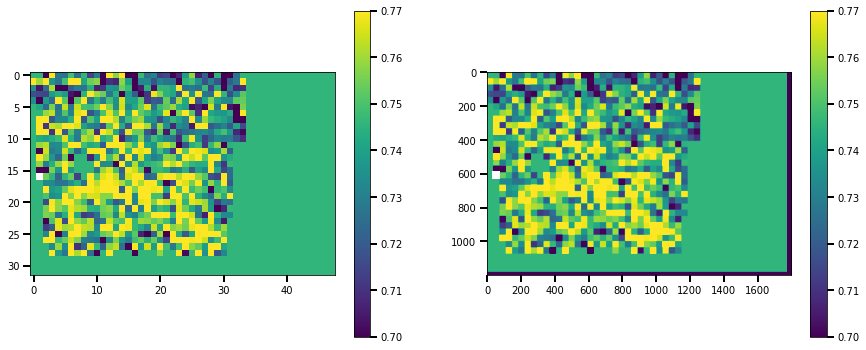

(array([   0,    0,    0, ..., 1199, 1199, 1199]), array([1776, 1777, 1778, ..., 1797, 1798, 1799]))


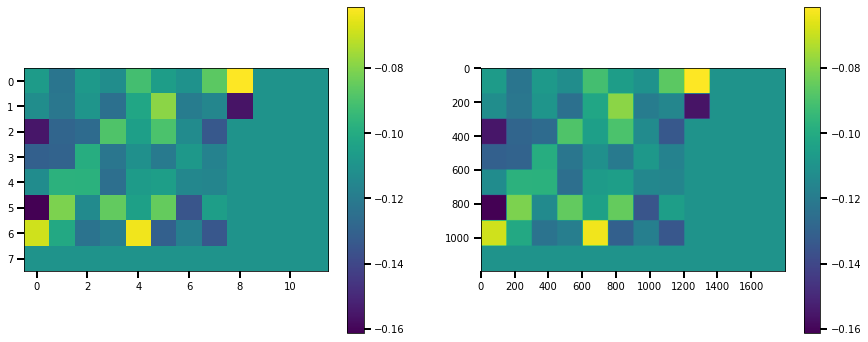

(array([], dtype=int64), array([], dtype=int64))


In [150]:
# Check
plt.figure(figsize=(15,6))
plt.subplot(1,2,1)
plt.imshow(R_shear_025deg[0,0,:,:])
plt.colorbar()
plt.clim(0.7,0.77)
plt.subplot(1,2,2)
plt.imshow(Rshear_metacal_025deg[0,0,:,:])
plt.colorbar()
plt.clim(0.7,0.77)
plt.show()
print(np.where(Rshear_metacal_025deg[0,0,:,:]==0))

plt.figure(figsize=(15,6))
plt.subplot(1,2,1)
plt.imshow(R_selec_1deg[0,0,:,:])
plt.colorbar()
plt.subplot(1,2,2)
plt.imshow(Rselec_metacal_1deg[0,0,:,:])
plt.colorbar()
plt.show()
print(np.where(Rselec_metacal_1deg[0,0,:,:]==0))

In [120]:
def bin_Rtot(Rshear,Rselec):
    # R tot = R shear + R selection
    
    Rtot = np.zeros((2,2,Ny,Nx))
    for i in range(Ny):
        for j in range(Nx):
            Rtot[:,:,i,j] = Rshear[:,:,i,j] + Rselec[:,:,i,j]
    return Rtot

In [121]:
Rtot_metacal_05deg = bin_Rtot(Rshear_metacal_05deg,Rselec_metacal_05deg)
Rtot_metacal_1deg = bin_Rtot(Rshear_metacal_1deg,Rselec_metacal_1deg)
Rtot_metacal_2deg = bin_Rtot(Rshear_metacal_2deg,Rselec_metacal_2deg)
Rtot_metacal_4deg = bin_Rtot(Rshear_metacal_4deg,Rselec_metacal_4deg)

Kappa map

In [151]:
# Kappa map
# Global calibration
kappaE_cal, kappaB_cal = ks93(e1map-c1_ngmix,-(e2map-c2_ngmix))

# From local calibration
kappaE_05deg, kappaB_05deg = ks93(gmap_05deg[0]-c1_ngmix_metacal_05deg, -(gmap_05deg[1]-c2_ngmix_metacal_05deg)) 
kappaE_1deg, kappaB_1deg = ks93(gmap_1deg[0]-c1_ngmix_metacal_1deg, -(gmap_1deg[1]-c2_ngmix_metacal_1deg)) 
kappaE_2deg, kappaB_2deg = ks93(gmap_2deg[0]-c1_ngmix_metacal_2deg, -(gmap_2deg[1]-c2_ngmix_metacal_2deg)) 
kappaE_4deg, kappaB_4deg = ks93(gmap_4deg[0]-c1_ngmix_metacal_4deg, -(gmap_4deg[1]-c2_ngmix_metacal_4deg))

kappaE_05deg_globalc, kappaB_05deg_globalc = ks93(gmap_05deg[0]-c1_ngmix, -(gmap_05deg[1]-c2_ngmix)) 
kappaE_1deg_globalc, kappaB_1deg_globalc = ks93(gmap_1deg[0]-c1_ngmix, -(gmap_1deg[1]-c2_ngmix)) 
kappaE_2deg_globalc, kappaB_2deg_globalc = ks93(gmap_2deg[0]-c1_ngmix, -(gmap_2deg[1]-c2_ngmix)) 
kappaE_4deg_globalc, kappaB_4deg_globalc = ks93(gmap_4deg[0]-c1_ngmix, -(gmap_4deg[1]-c2_ngmix))

# From local calibration + dm
kappaE_dm_05deg, kappaB_dm_05deg = ks93(gmap_dm_05deg[0]-c1_ngmix_metacal_05deg, -(gmap_dm_05deg[1]-c2_ngmix_metacal_05deg))
kappaE_dm_1deg, kappaB_dm_1deg = ks93(gmap_dm_1deg[0]-c1_ngmix_metacal_1deg, -(gmap_dm_1deg[1]-c2_ngmix_metacal_1deg))
kappaE_dm_2deg, kappaB_dm_2deg = ks93(gmap_dm_2deg[0]-c1_ngmix_metacal_2deg, -(gmap_dm_2deg[1]-c2_ngmix_metacal_2deg)) 
kappaE_dm_4deg, kappaB_dm_4deg = ks93(gmap_dm_4deg[0]-c1_ngmix_metacal_4deg, -(gmap_dm_4deg[1]-c2_ngmix_metacal_4deg))

In [158]:
# From local calibration + dm = -0.0208
kappaE_dm_05deg_y3, kappaB_dm_05deg_y3 = ks93(gmap_dm_05deg_y3[0]-c1_ngmix_metacal_05deg, -(gmap_dm_05deg_y3[1]-c2_ngmix_metacal_05deg))
kappaE_dm_1deg_y3, kappaB_dm_1deg_y3 = ks93(gmap_dm_1deg_y3[0]-c1_ngmix_metacal_1deg, -(gmap_dm_1deg_y3[1]-c2_ngmix_metacal_1deg))
kappaE_dm_2deg_y3, kappaB_dm_2deg_y3 = ks93(gmap_dm_2deg_y3[0]-c1_ngmix_metacal_2deg, -(gmap_dm_2deg_y3[1]-c2_ngmix_metacal_2deg)) 
kappaE_dm_4deg_y3, kappaB_dm_4deg_y3 = ks93(gmap_dm_4deg_y3[0]-c1_ngmix_metacal_4deg, -(gmap_dm_4deg_y3[1]-c2_ngmix_metacal_4deg))

# From local calibration + dm = -0.0208
kappaE_dm_05deg_y3dev, kappaB_dm_05deg_y3dev = ks93(gmap_dm_05deg_y3dev[0]-c1_ngmix_metacal_05deg, -(gmap_dm_05deg_y3dev[1]-c2_ngmix_metacal_05deg))
kappaE_dm_1deg_y3dev, kappaB_dm_1deg_y3dev = ks93(gmap_dm_1deg_y3dev[0]-c1_ngmix_metacal_1deg, -(gmap_dm_1deg_y3dev[1]-c2_ngmix_metacal_1deg))
kappaE_dm_2deg_y3dev, kappaB_dm_2deg_y3dev = ks93(gmap_dm_2deg_y3dev[0]-c1_ngmix_metacal_2deg, -(gmap_dm_2deg_y3dev[1]-c2_ngmix_metacal_2deg)) 
kappaE_dm_4deg_y3dev, kappaB_dm_4deg_y3dev = ks93(gmap_dm_4deg_y3dev[0]-c1_ngmix_metacal_4deg, -(gmap_dm_4deg_y3dev[1]-c2_ngmix_metacal_4deg))

In [169]:
hdu = fits.PrimaryHDU(kappaE_05deg)
hdul = fits.HDUList([hdu])
hdul.writeto('./W3/kappaE_05deg.fits')

In [ ]:
#galaxy number density in gal/arcmin^2
n_gal=7 # gal/arcmin^2 in the survey

#pixel size in arcmin
pix_arcmin=0.4

#compute shape noise for CFIS
shape_noise=0.44
sigma_noise_CFIS=shape_noise/(np.sqrt(2*n_gal*pix_arcmin**2))
noise_CFIS_z05=sigma_noise_CFIS*np.random.randn(Ny, Nx)

In [ ]:
#smooth the map with Gaussian kernel
precision_Peaks = 2/pix_arcmin

kappa_noisy_smoothedB = ndi.gaussian_filter(kappaB_cal, precision_Peaks) 
kappa_noisy_smoothed_cal = ndi.gaussian_filter(kappaE_cal, precision_Peaks)

kappa_noisy_smoothed_1deg = ndi.gaussian_filter(kappaE_1deg, precision_Peaks)
kappa_noisy_smoothed_2deg = ndi.gaussian_filter(kappaE_2deg, precision_Peaks)
kappa_noisy_smoothed_4deg = ndi.gaussian_filter(kappaE_4deg, precision_Peaks)

kappa_noisy_smoothed_dm_1deg = ndi.gaussian_filter(kappaE_dm_1deg, precision_Peaks)
kappa_noisy_smoothed_dm_2deg = ndi.gaussian_filter(kappaE_dm_2deg, precision_Peaks)
kappa_noisy_smoothed_dm_4deg = ndi.gaussian_filter(kappaE_dm_4deg, precision_Peaks)

In [ ]:
plt.figure(figsize=(25,10))
plt.subplot(1,2,1)
ax = plt.gca()
im = ax.imshow(kappa_noisy_smoothed_cal)
divider = make_axes_locatable(ax)
plt.title('Global')
cax = divider.append_axes("right", size="5%", pad=0.05)
plt.colorbar(im, cax=cax)

plt.subplot(1,2,2)
ax = plt.gca()
im = ax.imshow(kappa_noisy_smoothed_1deg)
divider = make_axes_locatable(ax)
plt.title('metacal deg')
cax = divider.append_axes("right", size="5%", pad=0.05)
plt.colorbar(im, cax=cax)
plt.show()

In [ ]:
# snr map
snr_cal = kappa_noisy_smoothed_cal/np.std(ndi.gaussian_filter(noise_CFIS_z05, precision_Peaks))
snrB = kappa_noisy_smoothedB/np.std(ndi.gaussian_filter(noise_CFIS_z05, precision_Peaks))

snr_1deg = kappa_noisy_smoothed_1deg/np.std(ndi.gaussian_filter(noise_CFIS_z05, precision_Peaks))
snr_2deg = kappa_noisy_smoothed_2deg/np.std(ndi.gaussian_filter(noise_CFIS_z05, precision_Peaks))
snr_4deg = kappa_noisy_smoothed_4deg/np.std(ndi.gaussian_filter(noise_CFIS_z05, precision_Peaks))

snr_dm_1deg = kappa_noisy_smoothed_dm_1deg/np.std(ndi.gaussian_filter(noise_CFIS_z05, precision_Peaks))
snr_dm_2deg = kappa_noisy_smoothed_dm_2deg/np.std(ndi.gaussian_filter(noise_CFIS_z05, precision_Peaks))
snr_dm_4deg = kappa_noisy_smoothed_dm_4deg/np.std(ndi.gaussian_filter(noise_CFIS_z05, precision_Peaks))

In [ ]:
# Compute peak count on kappa smooth
kappa_th = np.linspace(-0.06, 0.06, 31)
kappa_th_center = 0.5*(kappa_th[:-1]+kappa_th[1:])

peak_counts_cal, bins_cal = peaks.peaks_histogram(kappa_noisy_smoothed_cal,kappa_th)

peak_counts_1deg, bins = peaks.peaks_histogram(kappa_noisy_smoothed_1deg,kappa_th)
peak_counts_2deg, bins = peaks.peaks_histogram(kappa_noisy_smoothed_2deg,kappa_th)
peak_counts_4deg, bins = peaks.peaks_histogram(kappa_noisy_smoothed_4deg,kappa_th)

peak_counts_dm_1deg, bins = peaks.peaks_histogram(kappa_noisy_smoothed_dm_1deg,kappa_th)
peak_counts_dm_2deg, bins = peaks.peaks_histogram(kappa_noisy_smoothed_dm_2deg,kappa_th)
peak_counts_dm_4deg, bins = peaks.peaks_histogram(kappa_noisy_smoothed_dm_4deg,kappa_th)

In [ ]:
# Compute peaks on snr map
kappa_snr = np.linspace(-2,6,31)
kappa_th_center_snr = 0.5*(kappa_snr[:-1]+kappa_snr[1:])

peak_counts_cal_snr, bins_cal = peaks.peaks_histogram(snr_cal,kappa_snr)

peak_counts_1deg_snr, bins = peaks.peaks_histogram(snr_1deg,kappa_snr)
peak_counts_2deg_snr, bins = peaks.peaks_histogram(snr_2deg,kappa_snr)
peak_counts_4deg_snr, bins = peaks.peaks_histogram(snr_4deg,kappa_snr)

peak_counts_dm_1deg_snr, bins = peaks.peaks_histogram(snr_dm_1deg,kappa_snr)
peak_counts_dm_2deg_snr, bins = peaks.peaks_histogram(snr_dm_2deg,kappa_snr)
peak_counts_dm_4deg_snr, bins = peaks.peaks_histogram(snr_dm_4deg,kappa_snr)

In [ ]:
#plot single-Gaussian peak counts : Verification
plt.figure(figsize=(20,6))
plt.subplot(1,2,1)
plt.plot(kappa_th_center,peak_counts_cal,label='Global cal')
plt.legend()
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.xlabel('kappa smooth', fontsize=18)
plt.ylabel('peak counts', fontsize=18)
plt.subplot(1,2,2)
plt.plot(kappa_th_center_snr,peak_counts_cal_snr)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.xlabel('snr', fontsize=18)
plt.ylabel('peak counts', fontsize=18)
plt.show()

In [ ]:
#plot single-Gaussian peak counts : method
plt.figure(figsize=(20,6))
plt.subplot(1,2,1)
plt.plot(kappa_th_center,peak_counts_cal,label='Global cal')
plt.plot(kappa_th_center,peak_counts_1deg,label='Local metacal 1 deg')
plt.plot(kappa_th_center,peak_counts_2deg,label='Local metacal 2 deg')
plt.plot(kappa_th_center,peak_counts_4deg,label='Local metacal 4 deg')
plt.legend()
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.xlabel('kappa smooth', fontsize=18)
plt.ylabel('peak counts', fontsize=18)

plt.subplot(1,2,2)
plt.plot(kappa_th_center_snr,peak_counts_cal_snr,label='Global cal')
plt.plot(kappa_th_center_snr,peak_counts_1deg_snr,label='Local metacal 1 deg')
plt.plot(kappa_th_center_snr,peak_counts_2deg_snr,label='Local metacal 2 deg')
plt.plot(kappa_th_center_snr,peak_counts_4deg_snr,label='Local metacal 4 deg')
plt.legend()
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.xlabel('snr', fontsize=18)
plt.ylabel('peak counts', fontsize=18)
plt.show()

In [ ]:
#plot single-Gaussian peak counts from metacal on patches
plt.figure(figsize=(20,12))
plt.subplot(2,2,1)
plt.plot(kappa_th_center_snr,peak_counts_cal_snr,label='Global cal')
plt.plot(kappa_th_center_snr,peak_counts_1deg_snr,label='Local metacal 1 deg')
plt.plot(kappa_th_center_snr,peak_counts_dm_1deg_snr,label='Local metacal 1 deg + dm')
plt.legend()
plt.xlabel('snr', fontsize=18)
plt.ylabel('peak counts', fontsize=18)

plt.subplot(2,2,2)
plt.plot(kappa_th_center_snr,(peak_counts_1deg_snr-peak_counts_dm_1deg_snr)/peak_counts_1deg_snr)
plt.axhline(y=0,c='k')
plt.ylim(-0.5,1)
plt.xlabel('snr', fontsize=18)
plt.ylabel('fractionnal diff without - with dm', fontsize=18)

plt.subplot(2,2,3)
plt.plot(kappa_th_center_snr,(peak_counts_cal_snr-peak_counts_1deg_snr)/peak_counts_cal_snr)
plt.axhline(y=0,c='k')
plt.ylim(-0.5,1)
plt.xlabel('snr', fontsize=18)
plt.ylabel('fractionnal diff global - without dm', fontsize=18)

plt.subplot(2,2,4)
plt.plot(kappa_th_center_snr,(peak_counts_cal_snr-peak_counts_dm_1deg_snr)/peak_counts_cal_snr)
plt.axhline(y=0,c='k')
plt.ylim(-0.5,1)
plt.xlabel('snr', fontsize=18)
plt.ylabel('fractionnal diff global - with dm', fontsize=18)
#plt.savefig('./P3/frac_diff_1deg.jpg')
plt.show()

In [ ]:
#plot single-Gaussian peak counts from metacal on patches
plt.figure(figsize=(20,12))
plt.subplot(2,2,1)
plt.plot(kappa_th_center_snr,peak_counts_cal_snr,label='Global cal')
plt.plot(kappa_th_center_snr,peak_counts_2deg_snr,label='Local metacal 2 deg')
plt.plot(kappa_th_center_snr,peak_counts_dm_2deg_snr,label='Local metacal 2 deg + dm')
plt.legend()
plt.xlabel('snr', fontsize=18)
plt.ylabel('peak counts', fontsize=18)

plt.subplot(2,2,2)
plt.plot(kappa_th_center_snr,(peak_counts_2deg_snr-peak_counts_dm_2deg_snr)/peak_counts_2deg_snr)
plt.axhline(y=0,c='k')
plt.ylim(-0.5,1)
plt.xlabel('snr', fontsize=18)
plt.ylabel('fractionnal diff without - with dm', fontsize=18)

plt.subplot(2,2,3)
plt.plot(kappa_th_center_snr,(peak_counts_cal_snr-peak_counts_2deg_snr)/peak_counts_cal_snr)
plt.axhline(y=0,c='k')
plt.ylim(-0.5,1)
plt.xlabel('snr', fontsize=18)
plt.ylabel('fractionnal diff global - without dm', fontsize=18)

plt.subplot(2,2,4)
plt.plot(kappa_th_center_snr,(peak_counts_cal_snr-peak_counts_dm_2deg_snr)/peak_counts_cal_snr)
plt.axhline(y=0,c='k')
plt.ylim(-0.5,1)
plt.xlabel('snr', fontsize=18)
plt.ylabel('fractionnal diff global - with dm', fontsize=18)
#plt.savefig('./P3/frac_diff_2deg.jpg')
plt.show()

In [ ]:

#plot single-Gaussian peak counts from metacal on patches
plt.figure(figsize=(20,12))
plt.subplot(2,2,1)
plt.plot(kappa_th_center_snr,peak_counts_cal_snr,label='Global cal')
plt.plot(kappa_th_center_snr,peak_counts_4deg_snr,label='Local metacal 4 deg')
plt.plot(kappa_th_center_snr,peak_counts_dm_4deg_snr,label='Local metacal 4 deg + dm')
plt.legend()
plt.xlabel('snr', fontsize=18)
plt.ylabel('peak counts', fontsize=18)

plt.subplot(2,2,2)
plt.plot(kappa_th_center_snr,(peak_counts_4deg_snr-peak_counts_dm_4deg_snr)/peak_counts_4deg_snr)
plt.axhline(y=0,c='k')
plt.ylim(-0.5,1)
plt.xlabel('snr', fontsize=18)
plt.ylabel('fractionnal diff without - with dm', fontsize=18)

plt.subplot(2,2,3)
plt.plot(kappa_th_center_snr,(peak_counts_cal_snr-peak_counts_4deg_snr)/peak_counts_cal_snr)
plt.axhline(y=0,c='k')
plt.ylim(-0.5,1)
plt.xlabel('snr', fontsize=18)
plt.ylabel('fractionnal diff global - without dm', fontsize=18)

plt.subplot(2,2,4)
plt.plot(kappa_th_center_snr,(peak_counts_cal_snr-peak_counts_dm_4deg_snr)/peak_counts_cal_snr)
plt.axhline(y=0,c='k')
plt.ylim(-0.5,1)
plt.xlabel('snr', fontsize=18)
plt.ylabel('fractionnal diff global - with dm', fontsize=18)
#plt.savefig('./P3/frac_diff_3deg.jpg')
plt.show()

In [ ]:
# Histogram to see difference btw R^-1 * e with and without dm
kappa_map1D_deg= np.ravel(kappa_noisy_smoothed_1deg)
kappa_map1D_dm_deg = np.ravel(kappa_noisy_smoothed_dm_1deg)

kappa_th_hist = np.linspace(-0.06, 0.06, 100)
kappa_th_center_hist = 0.5*(kappa_th_hist[:-1]+kappa_th_hist[1:])

kappa_map_1D_hist_deg, bins1 = np.histogram(kappa_map1D_deg,bins=kappa_th_hist)
kappa_map_1D_dm_hist_deg, bins2 = np.histogram(kappa_map1D_dm_deg,bins=kappa_th_hist)

plt.figure(figsize=(20,6))
plt.subplot(1,2,1)
plt.hist(kappa_map1D_deg,label='without dm',histtype='step',bins=kappa_th_hist)
plt.hist(kappa_map1D_dm_deg,label='with dm',histtype='step',bins=kappa_th_hist)
plt.xlabel('$\kappa smooth$')
plt.ylabel('count')
plt.legend()
plt.subplot(1,2,2)
plt.plot(kappa_th_center_hist,(kappa_map_1D_hist_deg-kappa_map_1D_dm_hist_deg))
plt.xlabel('$\kappa smooth$')
plt.ylabel('with - without dm')
#plt.savefig('./P3/hist_diff_1deg.jpg')
plt.show()

In [ ]:
# Histogram to see difference btw R^-1 * e with and without dm
kappa_map1D_2deg= np.ravel(kappa_noisy_smoothed_2deg)
kappa_map1D_dm_2deg = np.ravel(kappa_noisy_smoothed_dm_2deg)

kappa_map_1D_hist_2deg, bins1 = np.histogram(kappa_map1D_2deg,bins=kappa_th_hist)
kappa_map_1D_dm_hist_2deg, bins2 = np.histogram(kappa_map1D_dm_2deg,bins=kappa_th_hist)

plt.figure(figsize=(20,6))
plt.subplot(1,2,1)
plt.hist(kappa_map1D_2deg,label='without dm',histtype='step',bins=kappa_th_hist)
plt.hist(kappa_map1D_dm_2deg,label='with dm',histtype='step',bins=kappa_th_hist)
plt.xlabel('$\kappa smooth$')
plt.ylabel('count')
plt.legend()
plt.subplot(1,2,2)
plt.plot(kappa_th_center_hist,(kappa_map_1D_hist_2deg-kappa_map_1D_dm_hist_2deg))
plt.xlabel('$\kappa smooth$')
plt.ylabel('with - without dm')
#plt.savefig('./P3/hist_diff_2deg.jpg')
plt.show()

In [ ]:
# Histogram to see difference btw R^-1 * e with and without dm
kappa_map1D_4deg= np.ravel(kappa_noisy_smoothed_4deg)
kappa_map1D_dm_4deg = np.ravel(kappa_noisy_smoothed_dm_4deg)

kappa_map_1D_hist_4deg, bins1 = np.histogram(kappa_map1D_4deg,bins=kappa_th_hist)
kappa_map_1D_dm_hist_4deg, bins2 = np.histogram(kappa_map1D_dm_4deg,bins=kappa_th_hist)

plt.figure(figsize=(20,6))
plt.subplot(1,2,1)
plt.hist(kappa_map1D_4deg,label='without dm',histtype='step',bins=kappa_th_hist)
plt.hist(kappa_map1D_dm_4deg,label='with dm',histtype='step',bins=kappa_th_hist)
plt.xlabel('$\kappa smooth$')
plt.ylabel('count')
plt.legend()
plt.subplot(1,2,2)
plt.plot(kappa_th_center_hist,(kappa_map_1D_hist_4deg-kappa_map_1D_dm_hist_4deg))
plt.xlabel('$\kappa smooth$')
plt.ylabel('with - without dm')
#plt.savefig('./P3/hist_diff_3deg.jpg')
plt.show()

In [ ]:
# Find the peaks positions and bin it
x_peaks, y_peaks, h_peaks = find_peaks2d(snr_cal, threshold=-2, include_border=True)
pos_peaks = bin2d(x_peaks, y_peaks, npix=(Nx,Ny))

plt.figure()
plt.imshow(pos_peaks)
plt.colorbar()
plt.clim(-0.01,0.01)
plt.show()

In [ ]:
np.shape(pos_peaks)

Cross correlation

In [ ]:
from scipy import stats
stats.pearsonr(np.ravel(kappaE_cal),np.ravel(kappaB_cal))

In [ ]:
# R shear, selec, tot diagonal and off-diag
Rshear_diag_1deg = (Rshear_metacal_1deg[0,0,:,:]+Rshear_metacal_1deg[1,1,:,:])/2
Rshear_off_diag_1deg = (Rshear_metacal_1deg[0,1,:,:]+Rshear_metacal_1deg[1,0,:,:])/2

Rselec_diag_1deg = (Rselec_metacal_1deg[0,0,:,:]+Rselec_metacal_1deg[1,1,:,:])/2
Rselec_off_diag_1deg = (Rselec_metacal_1deg[0,1,:,:]+Rselec_metacal_1deg[1,0,:,:])/2

Rtot_diag_1deg = (Rtot_metacal_1deg[0,0,:,:]+Rtot_metacal_1deg[1,1,:,:])/2
Rtot_off_diag_1deg = (Rtot_metacal_1deg[0,1,:,:]+Rtot_metacal_1deg[1,0,:,:])/2

In [ ]:
Rshear_diag_2deg = (Rshear_metacal_2deg[0,0,:,:]+Rshear_metacal_2deg[1,1,:,:])/2
Rshear_off_diag_2deg = (Rshear_metacal_2deg[0,1,:,:]+Rshear_metacal_2deg[1,0,:,:])/2

Rselec_diag_2deg = (Rselec_metacal_2deg[0,0,:,:]+Rselec_metacal_2deg[1,1,:,:])/2
Rselec_off_diag_2deg = (Rselec_metacal_2deg[0,1,:,:]+Rselec_metacal_2deg[1,0,:,:])/2

Rtot_diag_2deg = (Rtot_metacal_2deg[0,0,:,:]+Rtot_metacal_2deg[1,1,:,:])/2
Rtot_off_diag_2deg = (Rtot_metacal_2deg[0,1,:,:]+Rtot_metacal_2deg[1,0,:,:])/2

Rshear_diag_4deg = (Rshear_metacal_4deg[0,0,:,:]+Rshear_metacal_4deg[1,1,:,:])/2
Rshear_off_diag_4deg = (Rshear_metacal_4deg[0,1,:,:]+Rshear_metacal_4deg[1,0,:,:])/2

Rselec_diag_4deg = (Rselec_metacal_4deg[0,0,:,:]+Rselec_metacal_4deg[1,1,:,:])/2
Rselec_off_diag_4deg = (Rselec_metacal_4deg[0,1,:,:]+Rselec_metacal_4deg[1,0,:,:])/2

Rtot_diag_4deg = (Rtot_metacal_4deg[0,0,:,:]+Rtot_metacal_4deg[1,1,:,:])/2
Rtot_off_diag_4deg = (Rtot_metacal_4deg[0,1,:,:]+Rtot_metacal_4deg[1,0,:,:])/2

In [ ]:
data = {'n gal': np.ravel(ngaltot),
        'kappa_E': np.ravel(kappaE_cal),
        'kappa_E smooth': np.ravel(kappa_noisy_smoothed_cal),
        'kappa_B': np.ravel(kappaB_cal),
        'kappa_B smooth': np.ravel(kappa_noisy_smoothedB),
        'kappa_E 1 deg': np.ravel(kappaE_1deg),
        'kappa_B 1 deg': np.ravel(kappaB_1deg),
        'kappa_E 2 deg': np.ravel(kappaE_2deg),
        'kappa_B 2 deg': np.ravel(kappaB_2deg),
        'kappa_E 4 deg': np.ravel(kappaE_4deg),
        'kappa_B 4 deg': np.ravel(kappaB_4deg),
        'R_11 shear 1 deg': np.ravel(Rshear_metacal_1deg[0,0,:,:]),
        'R_22 shear 1 deg': np.ravel(Rshear_metacal_1deg[1,1,:,:]),
        'R_12 shear 1 deg': np.ravel(Rshear_metacal_1deg[0,1,:,:]),
        'R_21 shear 1 deg': np.ravel(Rshear_metacal_1deg[1,0,:,:]),
        'R_11 selec 1 deg': np.ravel(Rselec_metacal_1deg[0,0,:,:]),
        'R_22 selec 1 deg': np.ravel(Rselec_metacal_1deg[1,1,:,:]),
        'R_12 selec 1 deg': np.ravel(Rselec_metacal_1deg[0,1,:,:]),
        'R_21 selec 1 deg': np.ravel(Rselec_metacal_1deg[1,0,:,:]),
        'R_11 tot 1 deg': np.ravel(Rtot_metacal_1deg[0,0,:,:]),
        'R_22 tot 1 deg': np.ravel(Rtot_metacal_1deg[1,1,:,:]),
        'R_12 tot 1 deg': np.ravel(Rtot_metacal_1deg[0,1,:,:]),
        'R_21 tot 1 deg': np.ravel(Rtot_metacal_1deg[1,0,:,:]),
        'R_11 shear 2 deg': np.ravel(Rshear_metacal_2deg[0,0,:,:]),
        'R_22 shear 2 deg': np.ravel(Rshear_metacal_2deg[1,1,:,:]),
        'R_12 shear 2 deg': np.ravel(Rshear_metacal_2deg[0,1,:,:]),
        'R_21 shear 2 deg': np.ravel(Rshear_metacal_2deg[1,0,:,:]),
        'R_11 selec 2 deg': np.ravel(Rselec_metacal_2deg[0,0,:,:]),
        'R_22 selec 2 deg': np.ravel(Rselec_metacal_2deg[1,1,:,:]),
        'R_12 selec 2 deg': np.ravel(Rselec_metacal_2deg[0,1,:,:]),
        'R_21 selec 2 deg': np.ravel(Rselec_metacal_2deg[1,0,:,:]),
        'R_11 tot 2 deg': np.ravel(Rtot_metacal_2deg[0,0,:,:]),
        'R_22 tot 2 deg': np.ravel(Rtot_metacal_2deg[1,1,:,:]),
        'R_12 tot 2 deg': np.ravel(Rtot_metacal_2deg[0,1,:,:]),
        'R_21 tot 2 deg': np.ravel(Rtot_metacal_2deg[1,0,:,:]),
        'R_11 shear 4 deg': np.ravel(Rshear_metacal_4deg[0,0,:,:]),
        'R_22 shear 4 deg': np.ravel(Rshear_metacal_4deg[1,1,:,:]),
        'R_12 shear 4 deg': np.ravel(Rshear_metacal_4deg[0,1,:,:]),
        'R_21 shear 4 deg': np.ravel(Rshear_metacal_4deg[1,0,:,:]),
        'R_11 selec 4 deg': np.ravel(Rselec_metacal_4deg[0,0,:,:]),
        'R_22 selec 4 deg': np.ravel(Rselec_metacal_4deg[1,1,:,:]),
        'R_12 selec 4 deg': np.ravel(Rselec_metacal_4deg[0,1,:,:]),
        'R_21 selec 4 deg': np.ravel(Rselec_metacal_4deg[1,0,:,:]),
        'R_11 tot 4 deg': np.ravel(Rtot_metacal_4deg[0,0,:,:]),
        'R_22 tot 4 deg': np.ravel(Rtot_metacal_4deg[1,1,:,:]),
        'R_12 tot 4 deg': np.ravel(Rtot_metacal_4deg[0,1,:,:]),
        'R_21 tot 4 deg': np.ravel(Rtot_metacal_4deg[1,0,:,:]),
        'psf 1': np.ravel(psf[0]),
        'psf 2': np.ravel(psf[1]),
        'module psf': np.ravel(module_psf_map),
        'size gal': np.ravel(size_gal_map),
        'n epoch': np.ravel(nepoch_map),
        'mag': np.ravel(mag_map),
        'snr': np.ravel(snr_map),
        'R diag shear 1 deg': np.ravel(Rshear_diag_1deg),
        'R off diag shear 1 deg': np.ravel(Rshear_off_diag_1deg),
        'R diag selec 1 deg': np.ravel(Rselec_diag_1deg),
        'R off diag selec 1 deg': np.ravel(Rselec_off_diag_1deg),
        'R diag tot 1 deg': np.ravel(Rtot_diag_1deg),
        'R off diag tot 1 deg': np.ravel(Rtot_off_diag_1deg),
        'R diag shear 2 deg': np.ravel(Rshear_diag_2deg),
        'R off diag shear 2 deg': np.ravel(Rshear_off_diag_2deg),
        'R diag selec 2 deg': np.ravel(Rselec_diag_2deg),
        'R off diag selec 2 deg': np.ravel(Rselec_off_diag_2deg),
        'R diag tot 2 deg': np.ravel(Rtot_diag_2deg),
        'R off diag tot 2 deg': np.ravel(Rtot_off_diag_2deg),
        'R diag shear 4 deg': np.ravel(Rshear_diag_4deg),
        'R off diag shear 4 deg': np.ravel(Rshear_off_diag_4deg),
        'R diag selec 4 deg': np.ravel(Rselec_diag_4deg),
        'R off diag selec 4 deg': np.ravel(Rselec_off_diag_4deg),
        'R diag tot 4 deg': np.ravel(Rtot_diag_4deg),
        'R off diag tot 4 deg': np.ravel(Rtot_off_diag_4deg),
        'peaks': np.ravel(pos_peaks),
        'c1 1 deg': np.ravel(c1_ngmix_metacal_1deg),
        'c2 1 deg': np.ravel(c2_ngmix_metacal_1deg),
        'c1 2 deg': np.ravel(c1_ngmix_metacal_2deg),
        'c2 2 deg': np.ravel(c2_ngmix_metacal_2deg),
        'c1 4 deg': np.ravel(c1_ngmix_metacal_4deg),
        'c2 4 deg': np.ravel(c2_ngmix_metacal_4deg)
        }

In [ ]:
df = pd.DataFrame(data,columns=['n gal','kappa_E','kappa_E smooth','kappa_B','kappa_B smooth','kappa_E 1 deg',
                                'kappa_B 1 deg','R_11 shear 1 deg','R_22 shear 1 deg','R_12 shear 1 deg',
                                'R_21 shear 1 deg','R_11 selec 1 deg','R_22 selec 1 deg', 'R_12 selec 1 deg',
                                'R_21 selec 1 deg','R_11 tot 1 deg','R_22 tot 1 deg','R_12 tot 1 deg',
                                'R_21 tot 1 deg','psf 1','psf 2','module psf','size gal','n epoch','mag',
                                'snr','peaks','c1 1 deg','c2 1 deg'])

df2 = pd.DataFrame(data,columns=['n gal','kappa_E 1 deg','kappa_B 1 deg','R diag shear 1 deg','R off diag shear 1 deg',
                                 'R diag selec 1 deg','R off diag selec 1 deg','R diag tot 1 deg',
                                 'R off diag tot 1 deg','module psf','c1 1 deg','c2 1 deg'])

In [ ]:
corrMatrix = df.corr()
plt.figure(figsize=(25,25))
sns.heatmap(corrMatrix, annot=True, annot_kws={"fontsize":8},vmin=-0.2,vmax=1.)
plt.savefig('./P3X/matrix_corr.png')
plt.show()

In [ ]:
corrMatrix = df2.corr()
plt.figure(figsize=(12,12))
sns.heatmap(corrMatrix, annot=True, annot_kws={"fontsize":9},vmin=-0.2,vmax=1.)
plt.savefig('./P3X/matrix_corr_reduite.png')
plt.show()

In [ ]:
df_2deg = pd.DataFrame(data,columns=['n gal','kappa_E','kappa_E smooth','kappa_B','kappa_B smooth','kappa_E 2 deg',
                                'kappa_B 2 deg','R_11 shear 2 deg','R_22 shear 2 deg','R_12 shear 2 deg','R_21 shear 2 deg',
                                'R_11 selec 2 deg','R_22 selec 2 deg','R_12 selec 2 deg','R_21 selec 2 deg','R_11 tot 2 deg',
                                'R_22 tot 2 deg','R_12 tot 2 deg','R_21 tot 2 deg','psf 1','psf 2','module psf','size gal',
                                'n epoch','mag','snr','peaks','c1 2 deg','c2 2 deg'])

df2_2deg = pd.DataFrame(data,columns=['n gal','kappa_E 2 deg','kappa_B 2 deg','R diag shear 2 deg','R off diag shear 2 deg',
                                 'R diag selec 2 deg','R off diag selec 2 deg','R diag tot 2 deg','R off diag tot 2 deg',
                                'module psf','c1 2 deg','c2 2 deg'])

In [ ]:
corrMatrix = df_2deg.corr()
plt.figure(figsize=(25,25))
sns.heatmap(corrMatrix, annot=True, annot_kws={"fontsize":8},vmin=-0.2,vmax=1.)
plt.savefig('./P3X/matrix_corr_2deg.png')
plt.show()

In [ ]:
corrMatrix = df2_2deg.corr()
plt.figure(figsize=(12,12))
sns.heatmap(corrMatrix, annot=True, annot_kws={"fontsize":9},vmin=-0.2,vmax=1.)
plt.savefig('./P3X/matrix_corr_reduite_2deg.png')
plt.show()

In [ ]:
df_4deg = pd.DataFrame(data,columns=['n gal','kappa_E','kappa_E smooth','kappa_B','kappa_B smooth','kappa_E 4 deg',
                                'kappa_B 4 deg','R_11 shear 4 deg','R_22 shear 4 deg','R_12 shear 4 deg','R_21 shear 4 deg',
                                'R_11 selec 4 deg','R_22 selec 4 deg','R_12 selec 4 deg','R_21 selec 4 deg','R_11 tot 4 deg',
                                'R_22 tot 4 deg','R_12 tot 4 deg','R_21 tot 4 deg','psf 1','psf 2','module psf','size gal',
                                'n epoch','mag','snr','peaks','c1 4 deg','c2 4 deg'])

df2_4deg = pd.DataFrame(data,columns=['n gal','kappa_E 4 deg','kappa_B 4 deg','R diag shear 4 deg','R off diag shear 4 deg',
                                 'R diag selec 4 deg','R off diag selec 4 deg','R diag tot 4 deg','R off diag tot 4 deg',
                                'module psf','c1 4 deg','c2 4 deg'])

In [ ]:
corrMatrix = df_4deg.corr()
plt.figure(figsize=(25,25))
sns.heatmap(corrMatrix, annot=True, annot_kws={"fontsize":8},vmin=-0.2,vmax=1.)
plt.savefig('./P3X/matrix_corr_4deg.png')
plt.show()

In [ ]:
corrMatrix = df2_4deg.corr()
plt.figure(figsize=(12,12))
sns.heatmap(corrMatrix, annot=True, annot_kws={"fontsize":9},vmin=-0.2,vmax=1.)
plt.savefig('./P3X/matrix_corr_reduite_4deg.png')
plt.show()

In [ ]:
psf_e_corr2(np.ravel(ngaltot),np.ravel(Rshear_diag_1deg),
            'ngal_Rshear','R shear','ngal', weights=None,n_bin=50,save_plot=False)

In [ ]:
psf_e_corr2(np.ravel(ngaltot),np.ravel(Rshear_diag_2deg),
            'ngal_Rshear','R shear','ngal', weights=None,n_bin=50,save_plot=False)

In [ ]:
psf_e_corr2(np.ravel(ngaltot),np.ravel(Rshear_diag_4deg),
            'ngal_Rshear','R shear','ngal', weights=None,n_bin=50,save_plot=False)

In [ ]:
psf_e_corr2(np.ravel(ngaltot),np.ravel(Rselec_diag_1deg),
            'ngal_Rselec','R selec','ngal', weights=None,n_bin=50,save_plot=False)

In [ ]:
psf_e_corr2(np.ravel(ngaltot),np.ravel(Rselec_diag_2deg),
            'ngal_Rselec','R selec','ngal', weights=None,n_bin=50,save_plot=False)

In [ ]:
psf_e_corr2(np.ravel(ngaltot),np.ravel(Rselec_diag_4deg),
            'ngal_Rselec','R selec','ngal', weights=None,n_bin=50,save_plot=False)

In [ ]:
psf_e_corr2(np.ravel(ngaltot),np.ravel(Rtot_diag_1deg),
            'ngal_Rtot','R tot','ngal', weights=None,n_bin=50,save_plot=False)

In [ ]:
psf_e_corr2(np.ravel(ngaltot),np.ravel(Rtot_diag_2deg),
            'ngal_Rtot','R tot','ngal', weights=None,n_bin=50,save_plot=False)

In [ ]:
psf_e_corr2(np.ravel(ngaltot),np.ravel(Rtot_diag_4deg),
            'ngal_Rtot','R tot','ngal', weights=None,n_bin=50,save_plot=False)

End of local calib

In [ ]:
n_gal_ngmix = len(g_ngmix[0])
d_gal_ngmix = n_gal_ngmix / area_amin2
print("Final number of galaxies : {}\nGalaxy density : {:.2f} gal/arcmin2".format(n_gal_ngmix, d_gal_ngmix))
stat_file.write("Final number of galaxies : {}\nGalaxy density : {:.2f} gal/arcmin2\n".format(n_gal_ngmix, d_gal_ngmix))

In [ ]:
plt.figure(figsize=(30, 30))
plt.hexbin(ra_ngmix, dec_ngmix, gridsize=1000)
cbar = plt.colorbar()
cbar.set_label('Number count', rotation=270)
plt.title("Galaxy number count")
plt.xlabel("Ra (Deg)")
plt.ylabel("Dec (Deg)")
plt.savefig(plot_dir + 'galaxy_number_count_ngmix.png')

In [ ]:
ra_all = dd['XWIN_WORLD']
dec_all = dd['YWIN_WORLD']
plt.figure(figsize=(30, 30))
plt.hexbin(ra_all, dec_all, gridsize=100)
cbar = plt.colorbar()
cbar.set_label('Number count', rotation=270)
plt.title("All objects")
plt.xlabel("Ra (Deg)")
dummy = plt.ylabel("Dec (Deg)")

#### Galsim

In [ ]:
plt.figure(figsize=(30,20))
plt.hist(dd['NGMIX_FLUX_NOSHEAR'][m_gal_ngmix]/dd['NGMIX_FLUX_ERR_NOSHEAR'][m_gal_ngmix], 500, range=(0,200), histtype='step', density=True, label='flux snr ngmix')
plt.hist(dd['SNR_WIN'][m_gal_ngmix], 500, range=(0,200), histtype='step', density=True, label='SEx snr ngmix')
plt.vlines(x=10, ymax=plt.ylim()[1], ymin=0, linestyles='--', colors='k', label='cut : 10')
plt.legend()
plt.xlabel('SNR')
plt.ylabel('frequency')
plt.title('SNR cut')

In [ ]:
plt.figure(figsize=(30,20))
plt.hist(dd['SNR_WIN'][m_gal_galsim], 500, range=(0,200), histtype='step', density=True, label='SEx snr galsim')
plt.vlines(x=10, ymax=plt.ylim()[1], ymin=0, linestyles='--', colors='k', label='cut : 10')
plt.legend()
plt.xlabel('SNR')
plt.ylabel('frequency')
dummy = plt.title('SNR cut')

In [ ]:
gal_metacal_galsim = metacal(dd, m_gal_galsim, prefix='GALSIM')

In [ ]:
g_galsim = np.array([gal_metacal_galsim.ns['g1'][gal_metacal_galsim.mask_dict['ns']], gal_metacal_galsim.ns['g2'][gal_metacal_galsim.mask_dict['ns']]])
g_corr_galsim = np.linalg.inv(gal_metacal_galsim.R).dot(g_galsim)
w_galsim = gal_metacal_galsim.ns['w'][gal_metacal_galsim.mask_dict['ns']]
ra_galsim = dd['XWIN_WORLD'][m_gal_galsim][gal_metacal_galsim.mask_dict['ns']]
dec_galsim = dd['YWIN_WORLD'][m_gal_galsim][gal_metacal_galsim.mask_dict['ns']]
mag_galsim = dd['MAG_AUTO'][m_gal_galsim][gal_metacal_galsim.mask_dict['ns']]
#snr_galsim = dd['NGMIX_FLUX_NOSHEAR'][m_gal_galsim][gal_metacal_galsim.mask_dict['ns']]/dd['NGMIX_FLUX_ERR_NOSHEAR'][m_gal_galsim][gal_metacal_galsim.mask_dict['ns']]

In [ ]:
n_gal_galsim = len(g_galsim[0])
n_tiles = 214 #len(list(set(dd['TILE_ID'])))
area_tiles = 0.25
area_deg = n_tiles*area_tiles
tot_area = area_deg*3600
d_gal_galsim = n_gal_galsim / tot_area
print("Final number of galaxies : {}\nGalaxy density : {:.2f} gal/arcmin2".format(n_gal_galsim, d_gal_galsim))
stat_file.write("Final number of galaxies : {}\nGalaxy density : {:.2f} gal/arcmin2\n".format(n_gal_galsim, d_gal_galsim))

In [ ]:
plt.figure(figsize=(30, 30))
plt.hexbin(ra_galsim, dec_galsim, gridsize=1000)
cbar = plt.colorbar()
cbar.set_label('Number count', rotation=270)
plt.title("Galaxy number count")
plt.xlabel("Ra (Deg)")
plt.ylabel("Dec (Deg)")
plt.savefig(plot_dir + 'galaxy_number_count_galsim.png')

### Compile metacal for stars   
Masking : Flags == 0   &   SNR > 10   &   SNR < 500

#### Ngmix

In [ ]:
star_metacal_ngmix = metacal(dd[ind_star], m_star_ngmix, masking_type='star')

In [ ]:
n_star = len(star_metacal_ngmix.ns['g1'][star_metacal_ngmix.mask_dict['ns']])
tot_area = area_deg*3600
d_star = n_star / tot_area
print("Final number of stars : {}\nStar density : {:.2f}    star/arcmin^2\n               {:.2f} star/deg^2".format(n_star, d_star, d_star*3600))
dummy = stat_file.write("Final number of stars : {}\nStar density : {:.2f}    star/arcmin^2\n               {:.2f} star/deg^2\n".format(n_star, d_star, d_star*3600))

#### Galsim

In [ ]:
star_metacal_galsim = metacal(dd[ind_star], m_star_galsim, masking_type='star')

In [ ]:
n_star = len(star_metacal_galsim.ns['g1'][star_metacal_galsim.mask_dict['ns']])
tot_area = area_deg*3600
d_star = n_star / tot_area
print("Final number of stars : {}\nStar density : {:.2f}    star/arcmin^2\n               {:.2f} star/deg^2".format(n_star, d_star, d_star*3600))
stat_file.write("Final number of stars : {}\nStar density : {:.2f}    star/arcmin^2\n               {:.2f} star/deg^2\n".format(n_star, d_star, d_star*3600))

In [ ]:
plt.figure(figsize=(30,20))
plt.hist(gal_metacal_ngmix.R_shear[0,0], 500, range=(-3,3), histtype='step', density=True, linestyle="-", linewidth=2, color='blue', label='$R11_{gal}$')
plt.hist(gal_metacal_ngmix.R_shear[1,1], 500, range=(-3,3), histtype='step', density=True, linestyle="-", linewidth=2, color='red', label='$R22_{gal}$')
plt.hist(star_metacal_ngmix.R_shear[0,0,:], 500, histtype='step', range=(-3,3), density=True, linestyle=":", linewidth=2, color='blue', label='$R11_{star}$')
plt.hist(star_metacal_ngmix.R_shear[1,1,:], 500, histtype='step', range=(-3,3), density=True, linestyle=":", linewidth=2, color='red', label='$R22_{star}$')
plt.legend()
plt.xlabel('$R_{ii}$')
plt.ylabel('Nb')
plt.title('Response matrix ngmix')
plt.savefig(plot_dir + 'response_matrix_ngmix.png')

In [ ]:
plt.figure(figsize=(30,20))
plt.hist(gal_metacal_galsim.R_shear[0,0], 500, range=(-3,3), histtype='step', density=True, linestyle="-", linewidth=2, color='blue', label='$R11_{gal}$')
plt.hist(gal_metacal_galsim.R_shear[1,1], 500, range=(-3,3), histtype='step', density=True, linestyle="-", linewidth=2, color='red', label='$R22_{gal}$')
plt.hist(star_metacal_galsim.R_shear[0,0,:], 500, histtype='step', range=(-3,3), density=True, linestyle=":", linewidth=2, color='blue', label='$R11_{star}$')
plt.hist(star_metacal_galsim.R_shear[1,1,:], 500, histtype='step', range=(-3,3), density=True, linestyle=":", linewidth=2, color='red', label='$R22_{star}$')
plt.legend()
plt.xlabel('$R_{ii}$')
plt.ylabel('Nb')
plt.title('Response matrix galsim')
plt.savefig(plot_dir + 'response_matrix_galsim.png')

### Galaxy response

#### Ngmix

In [ ]:
print('Galaxy total response matrix ngmix : [[{:.2f}    {:.2e}]\n                                [{:.2e}    {:.2f}]]'.format(gal_metacal_ngmix.R[0,0], gal_metacal_ngmix.R[0,1], gal_metacal_ngmix.R[1,0], gal_metacal_ngmix.R[1,1]))
dummy = stat_file.write('Galaxy total response matrix ngmix : [[{:.2f}    {:.2e}]\n                                [{:.2e}    {:.2f}]]\n'.format(gal_metacal_ngmix.R[0,0], gal_metacal_ngmix.R[0,1], gal_metacal_ngmix.R[1,0], gal_metacal_ngmix.R[1,1]))

In [ ]:
print('Galaxy selection response matrix ngmix : [[{:.3f}    {:.2e}]\n                                    [{:.2e}    {:.3f}]]'.format(gal_metacal_ngmix.R_selection[0,0], gal_metacal_ngmix.R_selection[0,1], gal_metacal_ngmix.R_selection[1,0], gal_metacal_ngmix.R_selection[1,1]))
dummy = stat_file.write('Galaxy selection response matrix ngmix : [[{:.3f}    {:.2e}]\n                                    [{:.2e}    {:.3f}]]\n'.format(gal_metacal_ngmix.R_selection[0,0], gal_metacal_ngmix.R_selection[0,1], gal_metacal_ngmix.R_selection[1,0], gal_metacal_ngmix.R_selection[1,1]))

In [ ]:
R_shear = np.mean(gal_metacal_ngmix.R_shear, 2)
print(R_shear)
print(gal_metacal_ngmix.R_selection)
R_sum = R_shear + gal_metacal_ngmix.R_selection
print(R_sum)

In [ ]:
print(np.shape(gal_metacal_ngmix.R_selection))

#### Galsim

In [ ]:
print('Galaxy total response matrix galsim : [[{:.2f}    {:.2e}]\n                                [{:.2e}    {:.2f}]]'.format(gal_metacal_galsim.R[0,0], gal_metacal_galsim.R[0,1], gal_metacal_galsim.R[1,0], gal_metacal_galsim.R[1,1]))
stat_file.write('Galaxy total response matrix galsim : [[{:.2f}    {:.2e}]\n                                [{:.2e}    {:.2f}]]\n'.format(gal_metacal_galsim.R[0,0], gal_metacal_galsim.R[0,1], gal_metacal_galsim.R[1,0], gal_metacal_galsim.R[1,1]))

In [ ]:
print('Galaxy selection response matrix galsim : [[{:.3f}    {:.2e}]\n                                    [{:.2e}    {:.3f}]]'.format(gal_metacal_galsim.R_selection[0,0], gal_metacal_galsim.R_selection[0,1], gal_metacal_galsim.R_selection[1,0], gal_metacal_galsim.R_selection[1,1]))
stat_file.write('Galaxy selection response matrix galsim : [[{:.3f}    {:.2e}]\n                                    [{:.2e}    {:.3f}]]\n'.format(gal_metacal_galsim.R_selection[0,0], gal_metacal_galsim.R_selection[0,1], gal_metacal_galsim.R_selection[1,0], gal_metacal_galsim.R_selection[1,1]))

### Star response

In [ ]:
print('Star total response matrix ngmix : [[{:.2f}     {:.2e}]\n                              [{:.2e}    {:.2f}]]'.format(star_metacal_ngmix.R[0,0], star_metacal_ngmix.R[0,1], star_metacal_ngmix.R[1,0], star_metacal_ngmix.R[1,1]))
stat_file.write('Star total response matrix ngmix : [[{:.2f}     {:.2e}]\n                              [{:.2e}    {:.2f}]]\n'.format(star_metacal_ngmix.R[0,0], star_metacal_ngmix.R[0,1], star_metacal_ngmix.R[1,0], star_metacal_ngmix.R[1,1]))

In [ ]:
print('Star total response matrix galsim : [[{:.2f}     {:.2e}]\n                              [{:.2e}    {:.2f}]]'.format(star_metacal_galsim.R[0,0], star_metacal_galsim.R[0,1], star_metacal_galsim.R[1,0], star_metacal_galsim.R[1,1]))
stat_file.write('Star total response matrix galsim : [[{:.2f}     {:.2e}]\n                              [{:.2e}    {:.2f}]]\n'.format(star_metacal_galsim.R[0,0], star_metacal_galsim.R[0,1], star_metacal_galsim.R[1,0], star_metacal_galsim.R[1,1]))

In [ ]:
# The following creates an eror, star_response not found
#print('Star selection response matrix : [[{:.2e}    {:.2e}]\n                                  [{:.2e}    {:.2e}]]'.format(star_metacal.R_selection[0,0], star_metacal.R_selection[0,1], star_metacal.R_selection[1,0], star_metacal.R_selection[1,1]))
#stat_file.write('Star selection response matrix : [[{:.2e}    {:.2e}]\n                                  [{:.2e}    {:.2e}]]\n'.format(star_metacal.R_selection[0,0], star_metacal.R_selection[0,1], star_metacal.R_selection[1,0], star_metacal.R_selection[1,1]))

In [ ]:
plt.figure(figsize=(30,20))
plt.hist(g_corr_ngmix[0], 500, weights=w_ngmix, histtype='step', density=True, label="$e_{1}$")
plt.hist(g_corr_ngmix[1], 500, weights=w_ngmix, histtype='step', density=True, label="$e_{2}$")
plt.legend()
plt.xlabel('$e_{i}$')
plt.ylabel('Nb')
plt.title("$e_{\\rm gal}$ distribution ngmix")
plt.savefig(plot_dir + 'e_gal_distribution_ngmix.png')

In [ ]:
plt.figure(figsize=(30,20))
plt.hist(g_corr_galsim[0], 500, weights=w_galsim, histtype='step', density=True, label="$e_{1}$")
plt.hist(g_corr_galsim[1], 500, weights=w_galsim, histtype='step', density=True, label="$e_{2}$")
plt.legend()
plt.xlabel('$e_{i}$')
plt.ylabel('Nb')
plt.title("$e_{\\rm gal}$ distribution galsim")
plt.savefig(plot_dir + 'e_gal_distribution.png')

In [ ]:
plt.figure(figsize=(30,20))
plt.hist(star_metacal_ngmix.ns['g1'][star_metacal_ngmix.mask_dict['ns']], 500, weights=star_metacal_ngmix.ns['w'][star_metacal_ngmix.mask_dict['ns']], histtype='step', density=True, label="$e_{1}$")
plt.hist(star_metacal_ngmix.ns['g2'][star_metacal_ngmix.mask_dict['ns']], 500, weights=star_metacal_ngmix.ns['w'][star_metacal_ngmix.mask_dict['ns']], histtype='step', density=True, label="$e_{2}$")
plt.legend()
plt.xlabel('$e_{i}$')
plt.ylabel('Nb')
plt.title("$e_{star}$ distribution")
plt.savefig(plot_dir + 'e_star_distribution.png')

In [ ]:
plt.figure(figsize=(30,20))
plt.hist(star_metacal_galsim.ns['g1'][star_metacal_galsim.mask_dict['ns']], 500, weights=star_metacal_galsim.ns['w'][star_metacal_galsim.mask_dict['ns']], histtype='step', density=True, label="$e_{1}$")
plt.hist(star_metacal_galsim.ns['g2'][star_metacal_galsim.mask_dict['ns']], 500, weights=star_metacal_galsim.ns['w'][star_metacal_galsim.mask_dict['ns']], histtype='step', density=True, label="$e_{2}$")
plt.legend()
plt.xlabel('$e_{i}$')
plt.ylabel('Nb')
plt.title("$e_{star}$ distribution")
plt.savefig(plot_dir + 'e_star_distribution_galsim.png')

In [ ]:
plt.figure(figsize=(30,20))
plt.hist(dd['MAG_AUTO'][m_gal_ngmix][gal_metacal_ngmix.mask_dict['ns']], 500)
plt.xlabel('Mag')
plt.ylabel('Nb')
plt.title('Magnitude distribution')
plt.savefig(plot_dir + 'gal_mag_distribution_ngmix.png')

In [ ]:
plt.figure(figsize=(30,20))
plt.hist(dd['MAG_AUTO'][m_gal_galsim][gal_metacal_galsim.mask_dict['ns']], 500)
plt.xlabel('Mag')
plt.ylabel('Nb')
plt.title('Magnitude distribution')
plt.savefig(plot_dir + 'gal_mag_distribution_galsim.png')

In [ ]:
plt.figure(figsize=(30,20))
plt.hist(dd['MAG_AUTO'][m_gal_ngmix][gal_metacal_ngmix.mask_dict['ns']], 500, weights=w_ngmix, histtype='step', density=True)
plt.hist(dd['MAG_AUTO'][m_gal_galsim][gal_metacal_galsim.mask_dict['ns']], 500, histtype='step', density=True)
plt.xlabel('Mag')
plt.ylabel('Nb')
plt.title('Magnitude distribution')
plt.savefig(plot_dir + 'gal_mag_distribution_both.png')

## Additive bias

#### Ngmix

In [ ]:
c1_ngmix, err_c1_ngmix = jackknif_weighted_average(g_corr_ngmix[0], w_ngmix, remove_size=0.05, n_realization=500)
print('Additive bias c1 : {:.3e} +/- {:.3e}'.format(c1_ngmix, err_c1_ngmix))
stat_file.write('Additive bias c1 : {:.3e} +/- {:.3e}\n'.format(c1_ngmix, err_c1_ngmix))

In [ ]:
c2_ngmix, err_c2_ngmix = jackknif_weighted_average(g_corr_ngmix[1], w_ngmix, remove_size=0.05, n_realization=500)
print('Additive bias c2 : {:.3e} +/- {:.3e}'.format(c2_ngmix, err_c2_ngmix))
stat_file.write('Additive bias c2 : {:.3e} +/- {:.3e}\n'.format(c2_ngmix, err_c2_ngmix))

#### Galsim

In [ ]:
c1_galsim, err_c1_galsim = jackknif_weighted_average(g_corr_galsim[0], np.ones_like(w_galsim), remove_size=0.05, n_realization=500)
print('Additive bias c1 : {:.3e} +/- {:.3e}'.format(c1_galsim, err_c1_galsim))
stat_file.write('Additive bias c1 : {:.3e} +/- {:.3e}\n'.format(c1_galsim, err_c1_galsim))

In [ ]:
c2_galsim, err_c2_galsim = jackknif_weighted_average(g_corr_galsim[1], np.ones_like(w_galsim), remove_size=0.05, n_realization=500)
print('Additive bias c2 : {:.3e} +/- {:.3e}'.format(c2_galsim, err_c2_galsim))
stat_file.write('Additive bias c2 : {:.3e} +/- {:.3e}\n'.format(c2_galsim, err_c2_galsim))

In [ ]:
sig_eps = np.sqrt(np.var(g_corr_ngmix[0]) + np.var(g_corr_ngmix[1]))
print('Ellipticity dispersion (complex; mean per component): {:.3f}; {:.3f}'.format(sig_eps, sig_eps /  np.sqrt(2)))

## PSF leakage

### Binning leakage

Use PSF ellipticity at galaxy positions.

#### Ngmix

In [ ]:
psf_e_corr(g_corr_ngmix[0]-c1_ngmix, 
           g_corr_ngmix[1]-c2_ngmix,
           dd['NGMIX_ELL_PSFo_NOSHEAR'][:,0][m_gal_ngmix][gal_metacal_ngmix.mask_dict['ns']], 
           dd['NGMIX_ELL_PSFo_NOSHEAR'][:,1][m_gal_ngmix][gal_metacal_ngmix.mask_dict['ns']], 
           dd['NGMIX_T_PSFo_NOSHEAR'][m_gal_ngmix][gal_metacal_ngmix.mask_dict['ns']]/1.17741*2.355, 
           weights=w_ngmix, 
           n_bin=30,
           save_plot=True,
           plot_dir=plot_dir + '/psf_leak_ngmix/')

In [ ]:
psf_e_corr(g_corr_galsim[0]-c1_galsim, 
           g_corr_galsim[1]-c2_galsim,
           dd['GALSIM_PSF_ELL_ORIGINAL_PSF'][:,0][m_gal_galsim][gal_metacal_galsim.mask_dict['ns']], 
           dd['GALSIM_PSF_ELL_ORIGINAL_PSF'][:,1][m_gal_galsim][gal_metacal_galsim.mask_dict['ns']], 
           dd['GALSIM_PSF_SIGMA_ORIGINAL_PSF'][m_gal_galsim][gal_metacal_galsim.mask_dict['ns']]*2.355*0.187, 
           weights=np.ones_like(w_galsim), 
           n_bin=30,
           save_plot=True,
           plot_dir=plot_dir + '/psf_leak_galsim/')

### Alpha leakage

Use PSF ellipticity at star positions.

Equation alpha leakage :
$
    \alpha = \frac{\xi_{+}^{gp} - \langle e_{gal} \rangle^{*} \langle e_{PSF} \rangle}{\xi_{+}^{pp} - |\langle e_{PSF} \rangle|^{2}}
$    
With $g$: galaxy and $p$: PSF.

#### Ngmix

In [ ]:
r_corr_gp_ngmix = xi_star_gal_tc(ra_ngmix, dec_ngmix, g_corr_ngmix[0]-c1_ngmix, g_corr_ngmix[1]-c2_ngmix, w_ngmix, ra_star_ngmix, dec_star_ngmix, g_star_psf_ngmix[0], g_star_psf_ngmix[1])
r_corr_pp_ngmix = xi_star_gal_tc(ra_star_ngmix, dec_star_ngmix, g_star_psf_ngmix[0], g_star_psf_ngmix[1], np.ones_like(g_star_psf_ngmix[0]), ra_star_ngmix, dec_star_ngmix, g_star_psf_ngmix[0], g_star_psf_ngmix[1])

In [ ]:
complex_gal_ngmix = np.average(g_corr_ngmix[0]-c1_ngmix, weights=w_ngmix) + np.average(g_corr_ngmix[1]-c2_ngmix, weights=w_ngmix)*1j
complex_psf_ngmix = np.mean(g_star_psf_ngmix[0]) + np.mean(g_star_psf_ngmix[1])*1j

In [ ]:
alpha_leak_ngmix = (r_corr_gp_ngmix.xip - np.real(np.conj(complex_gal_ngmix)*complex_psf_ngmix))/(r_corr_pp_ngmix.xip - np.abs(complex_psf_ngmix)**2.)

In [ ]:
sig_alpha_leak_ngmix = np.abs(alpha_leak_ngmix)*np.sqrt((np.sqrt(r_corr_gp_ngmix.varxip)/r_corr_gp_ngmix.xip)**2. + (np.sqrt(r_corr_pp_ngmix.varxip)/r_corr_pp_ngmix.xip)**2.)

In [ ]:
alpha_leak_mean_ngmix = np.average(alpha_leak_ngmix, weights=1/sig_alpha_leak_ngmix**2.)
print('All sales weitghed average alpha : {}'.format(alpha_leak_mean_ngmix))
stat_file.write('All scales weitghed average alpha : {}\n'.format(alpha_leak_mean_ngmix))

In [ ]:
mpl.rcParams['lines.linewidth'] = 3
mpl.rcParams['lines.markersize'] = 10
mpl.rcParams['font.size'] = 35
mpl.rcParams['xtick.minor.size'] = 7
mpl.rcParams['ytick.minor.size'] = 7
mpl.rcParams['xtick.major.size'] = 10
mpl.rcParams['ytick.major.size'] = 10
mpl.rcParams['xtick.major.width'] = 3
mpl.rcParams['ytick.major.width'] = 3
mpl.rcParams['boxplot.boxprops.linewidth'] = 2.
mpl.rcParams['boxplot.medianprops.linewidth'] = 2.
mpl.rcParams['boxplot.flierprops.markersize'] = 12
mpl.rcParams['boxplot.whiskerprops.linewidth'] = 2.
mpl.rcParams['boxplot.capprops.linewidth'] = 2.


mpl.rcParams['axes.xmargin'] = mpl.rcParamsDefault['axes.xmargin']

plt.figure(figsize=(30,20))

plt.errorbar(r_corr_gp_ngmix.meanr, alpha_leak_ngmix, yerr=sig_alpha_leak_ngmix, label=r'$\alpha$')
plt.hlines(y=0, xmin=plt.xlim()[0], xmax=plt.xlim()[1], linestyles='dashed')

plt.xscale('log')
#plt.yscale('log')
plt.xlim(plt.xlim()[0]+0.5,plt.xlim()[1]-30)
#plt.ylim(-0.5,0.5)
plt.xticks([2, 10, 200], labels=['2', '10', '200'])
plt.xlabel(r'$\theta$ (arcmin)')
plt.ylabel(r'$\alpha$')
#plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.legend()
plt.savefig(plot_dir + 'alpha_leakage_ngmix.png')

## $\xi^{sys}$

Use PSF ellipticity at star positions.

Equation alpha leakage :
$
\xi^{sys} = \frac{\xi_{\pm}^{gp^{2}}}{\xi_{\pm}^{pp}}
$    
With $g$: galaxy and $p$: PSF.

In [ ]:
C_sys_p_ngmix = r_corr_gp_ngmix.xip**2/r_corr_pp_ngmix.xip
C_sys_m_ngmix = r_corr_gp_ngmix.xim**2/r_corr_pp_ngmix.xim
#C_sys_var = np.sqrt(r_corr_gp.varxi**2./r_corr_pp.varxi)
C_sys_std_p_ngmix = np.abs(C_sys_p_ngmix) * np.sqrt((((2*r_corr_gp_ngmix.xip**2.*np.sqrt(r_corr_gp_ngmix.varxip))/r_corr_gp_ngmix.xip)/r_corr_gp_ngmix.xip**2.)**2. + (np.sqrt(r_corr_pp_ngmix.varxip)/r_corr_pp_ngmix.xip)**2.)
C_sys_std_m_ngmix = np.abs(C_sys_m_ngmix) * np.sqrt((((2*r_corr_gp_ngmix.xim**2.*np.sqrt(r_corr_gp_ngmix.varxim))/r_corr_gp_ngmix.xim)/r_corr_gp_ngmix.xim**2.)**2. + (np.sqrt(r_corr_pp_ngmix.varxim)/r_corr_pp_ngmix.xim)**2.)

## Redshift distribution

In [ ]:
nz_base = 'nz.CFHTLenSmatched.W3'
nz_ext = 'txt'
nz_date = '202012'
nz_version = 'v1'
nz_name = '{}_{}_{}.{}'.format(nz_base, nz_date, nz_version, nz_ext)
source = 'vos:cfis/cosmostat/cosmology/redshifts/{}'.format(nz_name)

download(source, nz_name, verbose=True)

In [ ]:
z, nz = np.loadtxt(nz_name, unpack=True)

#theta = np.logspace(np.log10(2), np.log10(2e2), 20)

Om = 0.3153
sig8 = 0.8111
ns = 0.9649
Ob = 0.0493
h = 0.6736
xi_p_planck, xi_m_planck = get_theo_xi(r_corr_gp_ngmix.meanr, z, nz, Omega_m=Om, h=h, Omega_b=Ob, sig8=sig8, ns=ns)

In [ ]:
#mpl.rcParams['lines.linewidth'] = 3
#mpl.rcParams['lines.markersize'] = 10
#mpl.rcParams['font.size'] = 35
#mpl.rcParams['xtick.minor.size'] = 7
#mpl.rcParams['ytick.minor.size'] = 7
#mpl.rcParams['xtick.major.size'] = 10
#mpl.rcParams['ytick.major.size'] = 10
#mpl.rcParams['xtick.major.width'] = 3
#mpl.rcParams['ytick.major.width'] = 3
#mpl.rcParams['boxplot.boxprops.linewidth'] = 2.
#mpl.rcParams['boxplot.medianprops.linewidth'] = 2.
#mpl.rcParams['boxplot.flierprops.markersize'] = 12
#mpl.rcParams['boxplot.whiskerprops.linewidth'] = 2.
#mpl.rcParams['boxplot.capprops.linewidth'] = 2.
#mpl.rcParams['axes.xmargin'] = mpl.rcParamsDefault['axes.xmargin']

color = plt.rcParams['axes.prop_cycle'].by_key()['color']

plt.figure(figsize=(30,20))
plt.errorbar(r_corr_gp_ngmix.meanr, C_sys_p_ngmix, yerr=C_sys_std_p_ngmix, label=r'$\xi_{+}^{sys}$')
plt.plot(r_corr_gp_ngmix.meanr, xi_p_planck, ':', color=color[0], label=r'$\xi_{+}^{\Lambda\mathrm{CDM}}$')
plt.plot(r_corr_gp_ngmix.meanr, xi_m_planck, ':', color=color[1], label=r'$\xi_{-}^{\Lambda\mathrm{CDM}}$')

#ind_neg = np.where(C_sys_m <= 0)[0]
#ind_pos = np.where(C_sys_m > 0)[0]
#plt.errorbar(res.meanr[ind_neg]+0.05*res.meanr[ind_neg], np.abs(C_sys_m[ind_neg]), yerr=C_sys_std_m[ind_neg], linestyle='--', color=color[1], label=r'$\xi_{-}^{sys}$')
#plt.errorbar(res.meanr[[ind_neg[-1], ind_pos[0]]]+0.05*res.meanr[[ind_neg[-1], ind_pos[0]]], np.abs(C_sys_m[[ind_neg[-1], ind_pos[0]]]), yerr=C_sys_std_m[[ind_neg[-1], ind_pos[0]]], linestyle='--', color=color[1])
#plt.errorbar(res.meanr[ind_pos]+0.05*res.meanr[ind_pos], C_sys_m[ind_pos], yerr=C_sys_std_m[ind_pos], color=color[1], linestyle='-')
plt.errorbar(r_corr_gp_ngmix.meanr*(1.02), C_sys_m_ngmix, yerr=C_sys_std_m_ngmix, label=r'$\xi_{-}^{sys}$')

plt.xscale('log')
plt.yscale('log')
plt.xlim(plt.xlim()[0]+0.,plt.xlim()[1]-30)

plt.xticks([2, 10, 200], labels=['2', '10', '200'])
plt.xlabel(r'$\theta$ (arcmin)')
plt.ylabel(r'$\xi_{\pm}$')
#plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
#plt.gca().yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda v,_: ("$10^{%d}$" % math.log(v,10)) ))
plt.legend()
plt.savefig(plot_dir + 'xi_sys_ngmix.png')

In [ ]:
#mpl.rcParams['lines.linewidth'] = 3
#mpl.rcParams['lines.markersize'] = 10
#mpl.rcParams['font.size'] = 35
#mpl.rcParams['xtick.minor.size'] = 7
#mpl.rcParams['ytick.minor.size'] = 7
#mpl.rcParams['xtick.major.size'] = 10
#mpl.rcParams['ytick.major.size'] = 10
#mpl.rcParams['xtick.major.width'] = 3
#mpl.rcParams['ytick.major.width'] = 3
#mpl.rcParams['boxplot.boxprops.linewidth'] = 2.
#mpl.rcParams['boxplot.medianprops.linewidth'] = 2.
#mpl.rcParams['boxplot.flierprops.markersize'] = 12
#mpl.rcParams['boxplot.whiskerprops.linewidth'] = 2.
#mpl.rcParams['boxplot.capprops.linewidth'] = 2.
#mpl.rcParams['axes.xmargin'] = mpl.rcParamsDefault['axes.xmargin']

color = plt.rcParams['axes.prop_cycle'].by_key()['color']

plt.figure(figsize=(30,20))
#plt.errorbar(r_corr_gp.meanr, C_sys_p, yerr=C_sys_std_p, label=r'$\xi_{+}^{sys}$')
#plt.plot(r_corr_gp.meanr, f_theo_p_p(r_corr_gp.meanr), ':', color=color[0], label=r'$\xi_{+}^{\Lambda\mathrm{CDM}}$')
#plt.plot(r_corr_gp.meanr, f_theo_m_p(r_corr_gp.meanr), ':', color=color[1], label=r'$\xi_{-}^{\Lambda\mathrm{CDM}}$')
plt.plot(r_corr_gp_ngmix.meanr, C_sys_p_ngmix/xi_p_planck, color=color[0], label=r'$\xi_{\pm}/\xi_{+}^{\Lambda\mathrm{CDM}}$')

#ind_neg = np.where(C_sys_m <= 0)[0]
#ind_pos = np.where(C_sys_m > 0)[0]
#plt.errorbar(res.meanr[ind_neg]+0.05*res.meanr[ind_neg], np.abs(C_sys_m[ind_neg]), yerr=C_sys_std_m[ind_neg], linestyle='--', color=color[1], label=r'$\xi_{-}^{sys}$')
#plt.errorbar(res.meanr[[ind_neg[-1], ind_pos[0]]]+0.05*res.meanr[[ind_neg[-1], ind_pos[0]]], np.abs(C_sys_m[[ind_neg[-1], ind_pos[0]]]), yerr=C_sys_std_m[[ind_neg[-1], ind_pos[0]]], linestyle='--', color=color[1])
#plt.errorbar(res.meanr[ind_pos]+0.05*res.meanr[ind_pos], C_sys_m[ind_pos], yerr=C_sys_std_m[ind_pos], color=color[1], linestyle='-')
#plt.errorbar(r_corr_gp.meanr*(1.02), C_sys_m, yerr=C_sys_std_m, label=r'$\xi_{-}^{sys}$')

plt.xscale('log')
#plt.yscale('log')
plt.xlim(plt.xlim()[0]+0.,plt.xlim()[1]-30)

plt.xticks([2, 10, 200], labels=['2', '10', '200'])
plt.xlabel(r'$\theta$ (arcmin)')
plt.ylabel(r'$\xi_{\pm}/\xi_{+}^{\Lambda\mathrm{CDM}}$')
#plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
#plt.gca().yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda v,_: ("$10^{%d}$" % math.log(v,10)) ))
plt.legend()
plt.savefig(plot_dir + 'xi_sys_ratio_ngmix.png')

#### Galsim

In [ ]:
r_corr_gp_galsim = xi_star_gal_tc(ra_galsim, dec_galsim, g_corr_galsim[0]-c1_galsim, g_corr_galsim[1]-c2_galsim, np.ones_like(w_galsim), ra_star_galsim, dec_star_galsim, g_star_psf_galsim[0], g_star_psf_galsim[1])
r_corr_pp_galsim = xi_star_gal_tc(ra_star_galsim, dec_star_galsim, g_star_psf_galsim[0], g_star_psf_galsim[1], np.ones_like(g_star_psf_galsim[0]), ra_star_galsim, dec_star_galsim, g_star_psf_galsim[0], g_star_psf_galsim[1])

In [ ]:
complex_gal_galsim = np.average(g_corr_galsim[0]-c1_galsim, weights=np.ones_like(w_galsim)) + np.average(g_corr_galsim[1]-c2_galsim, weights=np.ones_like(w_galsim))*1j
complex_psf_galsim = np.mean(g_star_psf_galsim[0]) + np.mean(g_star_psf_galsim[1])*1j

In [ ]:
alpha_leak_galsim = (r_corr_gp_galsim.xip - np.real(np.conj(complex_gal_galsim)*complex_psf_galsim))/(r_corr_pp_galsim.xip - np.abs(complex_psf_galsim)**2.)

In [ ]:
sig_alpha_leak_galsim = np.abs(alpha_leak_galsim)*np.sqrt((np.sqrt(r_corr_gp_galsim.varxip)/r_corr_gp_galsim.xip)**2. + (np.sqrt(r_corr_pp_galsim.varxip)/r_corr_pp_galsim.xip)**2.)

In [ ]:
alpha_leak_mean_galsim = np.average(alpha_leak_galsim, weights=1/sig_alpha_leak_galsim**2.)
print('All sales weitghed average alpha : {}'.format(alpha_leak_mean_galsim))
stat_file.write('All sales weitghed average alpha : {}\n'.format(alpha_leak_mean_galsim))

In [ ]:
mpl.rcParams['lines.linewidth'] = 3
mpl.rcParams['lines.markersize'] = 10
mpl.rcParams['font.size'] = 35
mpl.rcParams['xtick.minor.size'] = 7
mpl.rcParams['ytick.minor.size'] = 7
mpl.rcParams['xtick.major.size'] = 10
mpl.rcParams['ytick.major.size'] = 10
mpl.rcParams['xtick.major.width'] = 3
mpl.rcParams['ytick.major.width'] = 3
mpl.rcParams['boxplot.boxprops.linewidth'] = 2.
mpl.rcParams['boxplot.medianprops.linewidth'] = 2.
mpl.rcParams['boxplot.flierprops.markersize'] = 12
mpl.rcParams['boxplot.whiskerprops.linewidth'] = 2.
mpl.rcParams['boxplot.capprops.linewidth'] = 2.


mpl.rcParams['axes.xmargin'] = mpl.rcParamsDefault['axes.xmargin']

plt.figure(figsize=(30,20))

plt.errorbar(r_corr_gp_galsim.meanr, alpha_leak_galsim, yerr=sig_alpha_leak_galsim, label=r'$\alpha$')
plt.hlines(y=0, xmin=plt.xlim()[0], xmax=plt.xlim()[1], linestyles='dashed')

plt.xscale('log')
#plt.yscale('log')
plt.xlim(plt.xlim()[0]+0.5,plt.xlim()[1]-30)
#plt.ylim(-0.5,0.5)
plt.xticks([2, 10, 200], labels=['2', '10', '200'])
plt.xlabel(r'$\theta$ (arcmin)')
plt.ylabel(r'$\alpha$')
#plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.legend()
plt.savefig(plot_dir + 'alpha_leakage_galsim.png')

In [ ]:
C_sys_p_galsim = r_corr_gp_galsim.xip**2/r_corr_pp_galsim.xip
C_sys_m_galsim = r_corr_gp_galsim.xim**2/r_corr_pp_galsim.xim
#C_sys_var = np.sqrt(r_corr_gp.varxi**2./r_corr_pp.varxi)
C_sys_std_p_galsim = np.abs(C_sys_p_galsim) * np.sqrt((((2*r_corr_gp_galsim.xip**2.*np.sqrt(r_corr_gp_galsim.varxip))/r_corr_gp_galsim.xip)/r_corr_gp_galsim.xip**2.)**2. + (np.sqrt(r_corr_pp_galsim.varxip)/r_corr_pp_galsim.xip)**2.)
C_sys_std_m_galsim = np.abs(C_sys_m_galsim) * np.sqrt((((2*r_corr_gp_galsim.xim**2.*np.sqrt(r_corr_gp_galsim.varxim))/r_corr_gp_galsim.xim)/r_corr_gp_galsim.xim**2.)**2. + (np.sqrt(r_corr_pp_galsim.varxim)/r_corr_pp_galsim.xim)**2.)

In [ ]:
#mpl.rcParams['lines.linewidth'] = 3
#mpl.rcParams['lines.markersize'] = 10
#mpl.rcParams['font.size'] = 35
#mpl.rcParams['xtick.minor.size'] = 7
#mpl.rcParams['ytick.minor.size'] = 7
#mpl.rcParams['xtick.major.size'] = 10
#mpl.rcParams['ytick.major.size'] = 10
#mpl.rcParams['xtick.major.width'] = 3
#mpl.rcParams['ytick.major.width'] = 3
#mpl.rcParams['boxplot.boxprops.linewidth'] = 2.
#mpl.rcParams['boxplot.medianprops.linewidth'] = 2.
#mpl.rcParams['boxplot.flierprops.markersize'] = 12
#mpl.rcParams['boxplot.whiskerprops.linewidth'] = 2.
#mpl.rcParams['boxplot.capprops.linewidth'] = 2.
#mpl.rcParams['axes.xmargin'] = mpl.rcParamsDefault['axes.xmargin']

color = plt.rcParams['axes.prop_cycle'].by_key()['color']

plt.figure(figsize=(30,20))
plt.errorbar(r_corr_gp_galsim.meanr, C_sys_p_galsim, yerr=C_sys_std_p_galsim, label=r'$\xi_{+}^{sys}$')
plt.plot(r_corr_gp_galsim.meanr, xi_p_planck, ':', color=color[0], label=r'$\xi_{+}^{\Lambda\mathrm{CDM}}$')
plt.plot(r_corr_gp_galsim.meanr, xi_m_planck, ':', color=color[1], label=r'$\xi_{-}^{\Lambda\mathrm{CDM}}$')

#ind_neg = np.where(C_sys_m <= 0)[0]
#ind_pos = np.where(C_sys_m > 0)[0]
#plt.errorbar(res.meanr[ind_neg]+0.05*res.meanr[ind_neg], np.abs(C_sys_m[ind_neg]), yerr=C_sys_std_m[ind_neg], linestyle='--', color=color[1], label=r'$\xi_{-}^{sys}$')
#plt.errorbar(res.meanr[[ind_neg[-1], ind_pos[0]]]+0.05*res.meanr[[ind_neg[-1], ind_pos[0]]], np.abs(C_sys_m[[ind_neg[-1], ind_pos[0]]]), yerr=C_sys_std_m[[ind_neg[-1], ind_pos[0]]], linestyle='--', color=color[1])
#plt.errorbar(res.meanr[ind_pos]+0.05*res.meanr[ind_pos], C_sys_m[ind_pos], yerr=C_sys_std_m[ind_pos], color=color[1], linestyle='-')
plt.errorbar(r_corr_gp_galsim.meanr*(1.02), C_sys_m_galsim, yerr=C_sys_std_m_galsim, label=r'$\xi_{-}^{sys}$')

plt.xscale('log')
plt.yscale('log')
plt.xlim(plt.xlim()[0]+0.,plt.xlim()[1]-30)

plt.xticks([2, 10, 200], labels=['2', '10', '200'])
plt.xlabel(r'$\theta$ (arcmin)')
plt.ylabel(r'$\xi_{\pm}$')
#plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
#plt.gca().yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda v,_: ("$10^{%d}$" % math.log(v,10)) ))
plt.legend()
plt.savefig(plot_dir + 'xi_sys_galsim.png')

In [ ]:
#mpl.rcParams['lines.linewidth'] = 3
#mpl.rcParams['lines.markersize'] = 10
#mpl.rcParams['font.size'] = 35
#mpl.rcParams['xtick.minor.size'] = 7
#mpl.rcParams['ytick.minor.size'] = 7
#mpl.rcParams['xtick.major.size'] = 10
#mpl.rcParams['ytick.major.size'] = 10
#mpl.rcParams['xtick.major.width'] = 3
#mpl.rcParams['ytick.major.width'] = 3
#mpl.rcParams['boxplot.boxprops.linewidth'] = 2.
#mpl.rcParams['boxplot.medianprops.linewidth'] = 2.
#mpl.rcParams['boxplot.flierprops.markersize'] = 12
#mpl.rcParams['boxplot.whiskerprops.linewidth'] = 2.
#mpl.rcParams['boxplot.capprops.linewidth'] = 2.
#mpl.rcParams['axes.xmargin'] = mpl.rcParamsDefault['axes.xmargin']

color = plt.rcParams['axes.prop_cycle'].by_key()['color']

plt.figure(figsize=(30,20))
#plt.errorbar(r_corr_gp.meanr, C_sys_p, yerr=C_sys_std_p, label=r'$\xi_{+}^{sys}$')
#plt.plot(r_corr_gp.meanr, f_theo_p_p(r_corr_gp.meanr), ':', color=color[0], label=r'$\xi_{+}^{\Lambda\mathrm{CDM}}$')
#plt.plot(r_corr_gp.meanr, f_theo_m_p(r_corr_gp.meanr), ':', color=color[1], label=r'$\xi_{-}^{\Lambda\mathrm{CDM}}$')
plt.plot(r_corr_gp_galsim.meanr, C_sys_p_galsim/xi_p_planck, color=color[0], label=r'$\xi_{\pm}/\xi_{+}^{\Lambda\mathrm{CDM}}$')

#ind_neg = np.where(C_sys_m <= 0)[0]
#ind_pos = np.where(C_sys_m > 0)[0]
#plt.errorbar(res.meanr[ind_neg]+0.05*res.meanr[ind_neg], np.abs(C_sys_m[ind_neg]), yerr=C_sys_std_m[ind_neg], linestyle='--', color=color[1], label=r'$\xi_{-}^{sys}$')
#plt.errorbar(res.meanr[[ind_neg[-1], ind_pos[0]]]+0.05*res.meanr[[ind_neg[-1], ind_pos[0]]], np.abs(C_sys_m[[ind_neg[-1], ind_pos[0]]]), yerr=C_sys_std_m[[ind_neg[-1], ind_pos[0]]], linestyle='--', color=color[1])
#plt.errorbar(res.meanr[ind_pos]+0.05*res.meanr[ind_pos], C_sys_m[ind_pos], yerr=C_sys_std_m[ind_pos], color=color[1], linestyle='-')
#plt.errorbar(r_corr_gp.meanr*(1.02), C_sys_m, yerr=C_sys_std_m, label=r'$\xi_{-}^{sys}$')

plt.xscale('log')
#plt.yscale('log')
plt.xlim(plt.xlim()[0]+0.,plt.xlim()[1]-30)

plt.xticks([2, 10, 200], labels=['2', '10', '200'])
plt.xlabel(r'$\theta$ (arcmin)')
plt.ylabel(r'$\xi_{\pm}/\xi_{+}^{\Lambda\mathrm{CDM}}$')
#plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
#plt.gca().yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda v,_: ("$10^{%d}$" % math.log(v,10)) ))
plt.legend()
plt.savefig(plot_dir + 'xi_sys_ratio_galsim.png')

## Write catalog

In [ ]:
# TODO: move this function to the python script.

def write_catalog_bias(output_path, ra, dec, g1, g2, w, mag, snr,
                       R, R_select, c1, c2, c1_err, c2_err, alpha_leak,
                       g1_uncal=None, g2_uncal=None, R_11=None,
                       R_22=None, R_12=None, R_21=None):
    """
    """

    # Data HDU
    c_ra = fits.Column(name='ra', array=ra, format='D', unit='deg')
    c_dec = fits.Column(name='dec', array=dec, format='D', unit='deg')
    c_g1 = fits.Column(name='g1', array=g1, format='D')
    c_g2 = fits.Column(name='g2', array=g2, format='D')
    c_w = fits.Column(name='w', array=w, format='D')
    c_mag = fits.Column(name='mag', array=mag, format='D')
    c_snr = fits.Column(name='snr', array=snr, format='D')
    cols = [c_ra, c_dec, c_g1, c_g2, c_w, c_mag, c_snr]

    for x, name in zip([g1_uncal, g2_uncal, R_11, R_22, R_12, R_21],
                       ['g1_uncal', 'g2_uncal', 'R_11', 'R_22', 'R_12', 'R_21']):
        if x is not None:
            cols.append(fits.Column(name=name, array=x, format='D'))

    table_hdu = fits.BinTableHDU.from_columns(cols)

    table_hdu.header['TTYPE3'] = ('g1', 'Reduced shear (a-b)/(a+b)')
    table_hdu.header['TTYPE4'] = ('g2', 'Reduced shear (a-b)/(a+b)')
    table_hdu.header['TTYPE5'] = ('w', 'Ellipticity weight')
    table_hdu.header['TTYPE6'] = ('mag', 'From SExtractor: MAG_AUTO')
    table_hdu.header['TTYPE7'] = ('snr', 'SNR computed on metacal noshear: flux/flux_std')
    
    ntype =  8
    for x in ([g1_uncal, g2_uncal], ['g1_uncal', 'g2_uncal']):
        if x is not None:
            table_hdu.header['TTYPE{}'.format(ntype)] = (name, 'uncalibrated reduced shear')
            ntype += 1
    for x, name in zip([R_11, R_22, R_12, R_21], ['R_11', 'R_22', 'R_12', 'R_21']):
        if x is not None:
            table_hdu.header['TTYPE{}'.format(ntype)] = (name, f'full response matrix {name}')
            ntype += 1

    # Primary HDU with information in header
    primary_header = fits.Header()

    primary_header['R'] = (r'<R>', r'Full response: <R> = <R_shear> + <R_select>')

    primary_header['R1_1'] = (R[0,0], 'Full response matrix')
    primary_header['R1_2'] = (R[0,1], 'Full response matrix')
    primary_header['R2_1'] = (R[1,0], 'Full response matrix')
    primary_header['R2_2'] = (R[1,1], 'Full response matrix')

    primary_header['RS'] = (r'<RS>', r'Selection response matrix: <R_select>')
    primary_header['RS1_1'] = (R_select[0,0], 'Selection response matrix')
    primary_header['RS1_2'] = (R_select[0,1], 'Selection response matrix')
    primary_header['RS2_1'] = (R_select[1,0], 'Selection response matrix')
    primary_header['RS2_2'] = (R_select[1,1], 'Selection response matrix')

    primary_header['g_corr'] = ('Apply correction', r'g_corr = R**(-1).g')

    primary_header['c'] = ('', 'Additive bias computed with JackKnife')
    primary_header['c1'] = (c1, 'Additive bias for g1')
    primary_header['c1_err'] = (c1_err, 'Standard deviation for c1')
    primary_header['c2'] = (c2, 'Additive bias for g2')
    primary_header['c2_err'] = (c2_err, 'Standard deviation for c2')

    primary_header['w'] = ('Ellipticity weight', r'1 / (2*sig_SN**2 + g1_var + g2_var)')
    primary_header['sig_SN'] = (0.34, 'Sigma_shape_noise')

    primary_header['alpha'] = (alpha_leak, 'PSF leakage alpha')

    primary_hdu = fits.PrimaryHDU(header=primary_header)

    # Final file
    hdu_list = fits.HDUList([primary_hdu, table_hdu])

    hdu_list.writeto(output_path, overwrite=True)


In [ ]:
out_name = 'shape_catalog_W3_MCCD_20210326.fits'

R = np.zeros_like(gal_metacal_ngmix.R_shear)
for i in (0,1):
    for j in (0, 1):
        R[i, j] = gal_metacal_ngmix.R_shear[i, j] + gal_metacal_ngmix.R_selection[i, j]

# Debug
alpha_leaka_mean_ngmix = 0
        
write_catalog_bias(out_name,
                   ra_ngmix, dec_ngmix,
                   g_corr_ngmix[0], g_corr_ngmix[1], w_ngmix,
                   mag_ngmix, snr_ngmix, 
                   gal_metacal_ngmix.R, gal_metacal_ngmix.R_selection,
                   c1_ngmix, c2_ngmix, err_c1_ngmix, err_c2_ngmix,
                   alpha_leaka_mean_ngmix,
                   g1_uncal=g_ngmix[0],g2_uncal=g_ngmix[1], 
                   R_11=R[0, 0], R_12=R[0, 1], R_21=R[1, 0], R_22=R[1, 1])

## Some cosmological calculations

### Ngmix

### Shear-Shear

In [ ]:
res_g_ngmix = xi_gal_gal_tc(ra_ngmix, dec_ngmix, g_corr_ngmix[0]-c1_ngmix, g_corr_ngmix[1]-c2_ngmix, w_ngmix, ra_ngmix, dec_ngmix, g_corr_ngmix[0]-c1_ngmix, g_corr_ngmix[1]-c2_ngmix, w_ngmix)

##### Cosmo planck

In [ ]:
z, nz = np.loadtxt(nz_name, unpack=True)

Om = 0.3153
sig8 = 0.8111
ns = 0.9649
Ob = 0.0493
h = 0.6736
xi_p_planck, xi_m_planck = get_theo_xi(res_g_ngmix.meanr, z, nz, Omega_m=Om, h=h, Omega_b=Ob, sig8=sig8, ns=ns)

##### Cosmo DES

In [ ]:
Om = 0.295
S8 = 0.768
sig8 = S8 / ((Om/0.3)**0.5)
#sig8 = 0.8111
ns = 1.044
Ob = 0.0516
h = 0.672
xi_p_des, xi_m_des = get_theo_xi(res_g_ngmix.meanr, z, nz, Omega_m=Om, h=h, Omega_b=Ob, sig8=sig8, ns=ns)

In [ ]:
pos_ind_gg = res_g_ngmix.xip >= 0
neg_ind_gg = res_g_ngmix.xip < 0

plt.figure(figsize=(15,10))

eb1 = plt.errorbar(res_g_ngmix.meanr[pos_ind_gg], res_g_ngmix.xip[pos_ind_gg], yerr=np.sqrt(res_g_ngmix.varxip[pos_ind_gg]), linestyle='', color=color[0], marker='x', capsize=4, label=r'$\xi_{+}$')
eb1[-1][0].set_linestyle('-')

eb2 = plt.errorbar(res_g_ngmix.meanr[neg_ind_gg], np.abs(res_g_ngmix.xip[neg_ind_gg]), yerr=np.sqrt(res_g_ngmix.varxip[neg_ind_gg]), linestyle='', color=color[0], marker='x', capsize=4)#, label=r'$\xi_{+}$')
eb2[-1][0].set_linestyle(':')

plt.plot(res_g_ngmix.meanr, xi_p_planck, 'k:', label=r'$\xi_{+}^{\Lambda\mathrm{CDM}}$ planck')
plt.plot(res_g_ngmix.meanr, xi_p_des, 'k--', label=r'$\xi_{+}^{\Lambda\mathrm{CDM}}$ DESY1')

plt.xscale('log')
plt.yscale('log')
plt.xlim(plt.xlim()[0]+0.3,plt.xlim()[1]-0)

plt.xticks([2, 10, 100], labels=['2', '10', '100'])
plt.xlabel(r'$\theta$ (arcmin)')
plt.ylabel(r'$\xi_{+}$')
#plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
#plt.gca().yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda v,_: ("$10^{%d}$" % math.log(v,10)) ))
plt.legend()
plt.savefig(plot_dir + 'xi_+_shear_shear_ngmix.png')

In [ ]:
pos_ind_gg = res_g_ngmix.xim >= 0
neg_ind_gg = res_g_ngmix.xim < 0

plt.figure(figsize=(15,10))

eb1 = plt.errorbar(res_g_ngmix.meanr[pos_ind_gg], res_g_ngmix.xim[pos_ind_gg], yerr=np.sqrt(res_g_ngmix.varxim[pos_ind_gg]), linestyle='', color=color[1], marker='o', markerfacecolor='none', capsize=4, label=r'$\xi_{-}$')
eb1[-1][0].set_linestyle('-')

eb2 = plt.errorbar(res_g_ngmix.meanr[neg_ind_gg], np.abs(res_g_ngmix.xim[neg_ind_gg]), yerr=np.sqrt(res_g_ngmix.varxim[neg_ind_gg]), linestyle='', color=color[1], marker='o', markerfacecolor='none', capsize=4)#, label=r'$\xi_{-}$')
eb2[-1][0].set_linestyle(':')

plt.plot(res_g_ngmix.meanr, xi_m_planck, 'k:', label=r'$\xi_{-}^{\Lambda\mathrm{CDM}}$ planck')
plt.plot(res_g_ngmix.meanr, xi_m_des, 'k--', label=r'$\xi_{-}^{\Lambda\mathrm{CDM}}$ DESY1')

plt.xscale('log')
plt.yscale('log')
plt.xlim(plt.xlim()[0]+0.,plt.xlim()[1])

plt.xticks([2, 10, 100], labels=['2', '10', '100'])
plt.xlabel(r'$\theta$ (arcmin)')
plt.ylabel(r'$\xi_{-}$')
#plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
#plt.gca().yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda v,_: ("$10^{%d}$" % math.log(v,10)) ))
plt.legend()
plt.savefig(plot_dir + 'xi_-_shear_shear_ngmix.png')

### Galsim

In [ ]:
res_g_galsim = xi_gal_gal_tc(ra_galsim, dec_galsim, g_corr_galsim[0]-c1_galsim, g_corr_galsim[1]-c2_galsim, np.ones_like(w_galsim), ra_galsim, dec_galsim, g_corr_galsim[0]-c1_galsim, g_corr_galsim[1]-c2_galsim, np.ones_like(w_galsim))

In [ ]:
pos_ind_gg = res_g_galsim.xip >= 0
neg_ind_gg = res_g_galsim.xip < 0

plt.figure(figsize=(15,10))

eb1 = plt.errorbar(res_g_galsim.meanr[pos_ind_gg], res_g_galsim.xip[pos_ind_gg], yerr=np.sqrt(res_g_galsim.varxip[pos_ind_gg]), linestyle='', color=color[0], marker='x', capsize=4, label=r'$\xi_{+}$')
eb1[-1][0].set_linestyle('-')

eb2 = plt.errorbar(res_g_galsim.meanr[neg_ind_gg], np.abs(res_g_galsim.xip[neg_ind_gg]), yerr=np.sqrt(res_g_galsim.varxip[neg_ind_gg]), linestyle='', color=color[0], marker='x', capsize=4)#, label=r'$\xi_{+}$')
eb2[-1][0].set_linestyle(':')

plt.plot(res_g_galsim.meanr, xi_p_planck, 'k:', label=r'$\xi_{+}^{\Lambda\mathrm{CDM}}$ planck')
plt.plot(res_g_galsim.meanr, xi_p_des, 'k--', label=r'$\xi_{+}^{\Lambda\mathrm{CDM}}$ DESY1')

plt.xscale('log')
plt.yscale('log')
plt.xlim(plt.xlim()[0]+0.,plt.xlim()[1]-0)

plt.xticks([2, 10, 200], labels=['2', '10', '200'])
plt.xlabel(r'$\theta$ (arcmin)')
plt.ylabel(r'$\xi_{+}$')
#plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
#plt.gca().yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda v,_: ("$10^{%d}$" % math.log(v,10)) ))
plt.legend()
plt.savefig(plot_dir + 'xi_+_shear_shear_galsim.png')

In [ ]:
pos_ind_gg = res_g_galsim.xim >= 0
neg_ind_gg = res_g_galsim.xim < 0

plt.figure(figsize=(15,10))

eb1 = plt.errorbar(res_g_galsim.meanr[pos_ind_gg], res_g_galsim.xim[pos_ind_gg], yerr=np.sqrt(res_g_galsim.varxim[pos_ind_gg]), linestyle='', color=color[1], marker='o', markerfacecolor='none', capsize=4, label=r'$\xi_{-}$')
eb1[-1][0].set_linestyle('-')

eb2 = plt.errorbar(res_g_galsim.meanr[neg_ind_gg], np.abs(res_g_galsim.xim[neg_ind_gg]), yerr=np.sqrt(res_g_galsim.varxim[neg_ind_gg]), linestyle='', color=color[1], marker='o', markerfacecolor='none', capsize=4)#, label=r'$\xi_{-}$')
eb2[-1][0].set_linestyle(':')

plt.plot(res_g_galsim.meanr, xi_m_planck, 'k:', label=r'$\xi_{-}^{\Lambda\mathrm{CDM}}$ planck')
plt.plot(res_g_galsim.meanr, xi_m_des, 'k--', label=r'$\xi_{-}^{\Lambda\mathrm{CDM}}$ DESY1')

plt.xscale('log')
plt.yscale('log')
plt.xlim(plt.xlim()[0]+0.,plt.xlim()[1])

plt.xticks([2, 10, 200], labels=['2', '10', '200'])
plt.xlabel(r'$\theta$ (arcmin)')
plt.ylabel(r'$\xi_{-}$')
#plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
#plt.gca().yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda v,_: ("$10^{%d}$" % math.log(v,10)) ))
plt.legend()
plt.savefig(plot_dir + 'xi_-_shear_shear_galsim.png')

### Cluster lensing

#### Load Planck cluster catalog

In [ ]:
cluster_cat_name = 'HFI_PCCS_SZ-union_R2.08.fits.gz'
source = 'vos:cfis/cosmostat/cosmology/external/Planck/{}'.format(cluster_cat_name)
download(source, cluster_cat_name, verbose=True)

In [ ]:
cluster_cat = fits.getdata(cluster_cat_name)
m_good_cluster = (cluster_cat['MSZ'] != 0) & (cluster_cat['COSMO'] == True)
m_cluster_foot = get_mask_footprint_P3(cluster_cat['RA'][m_good_cluster], cluster_cat['DEC'][m_good_cluster])
sdss_cluster_cut = {'ra': cluster_cat['RA'][m_good_cluster][m_cluster_foot], 'dec':cluster_cat['DEC'][m_good_cluster][m_cluster_foot], 'z':cluster_cat['REDSHIFT'][m_good_cluster][m_cluster_foot], 'M':cluster_cat['MSZ'][m_good_cluster][m_cluster_foot]*1e14}
#sdss_cluster_cut = {'ra': cluster_cat['RA'][m_good_cluster][m_cluster_foot][1:2], 'dec':cluster_cat['DEC'][m_good_cluster][m_cluster_foot][1:2], 'z':cluster_cat['REDSHIFT'][m_good_cluster][m_cluster_foot][1:2], 'M':cluster_cat['MSZ'][m_good_cluster][m_cluster_foot][1:2]*1e14}

In [ ]:
plt.figure(figsize=(15,15))
plt.plot(ra_ngmix, dec_ngmix, '+')
plt.plot(sdss_cluster_cut['ra'], sdss_cluster_cut['dec'], '*')
for i in range(len(sdss_cluster_cut['ra'])):
    plt.text(sdss_cluster_cut['ra'][i], sdss_cluster_cut['dec'][i]+ 0.02 * (plt.ylim()[0] - plt.ylim()[1]), i, color='k', fontsize=10, ha='center', va='center')

In [ ]:
ind_cluster_keep = [2,4,5,6,7,8,9,10,11,13,14,15]
for key in sdss_cluster_cut.keys():
    sdss_cluster_cut[key] = sdss_cluster_cut[key][ind_cluster_keep]

In [ ]:
print('Number of clusters : {}'.format(len(sdss_cluster_cut['z'])))
stat_file.write('Number of clusters : {}\n'.format(len(sdss_cluster_cut['z'])))

In [ ]:
R_p, logR_p, gamT_p, gamX_p, gam_sig_p = gamma_T_tc(sdss_cluster_cut['ra'], sdss_cluster_cut['dec'], ra_ngmix, dec_ngmix, g_corr_ngmix[0]-c1_ngmix, g_corr_ngmix[1]-c2_ngmix, w_ngmix)

In [ ]:
gamT_p

In [ ]:


plt.figure(figsize=(30,20))
# plt.errorbar(logR_p, gamT_p, yerr=gam_sig_p, capsize = 3, label='gamma_T')
# plt.boxplot(res[:,2,:], positions=logR_p, widths=0.2)

errplot = plt.errorbar(logR_p, gamT_p, yerr=gam_sig_p, capsize = 3, label=r'$\gamma_{t}$ known clusters')
#plt.boxplot(res[:,2,:], positions=logR_p, widths=0.2)
plt.hlines(y=0, xmin=np.min(logR_p), xmax=np.max(logR_p), linestyles='dashed')
# plt.xscale('log')
plt.title(r'Lensing by clusters')
plt.ylabel(r'$\gamma$')
plt.xlabel(r'$log(\theta$) (arcmin)')
#plt.xticks(fontsize=20)
#plt.yticks(fontsize=20)

plt.gca().xaxis.set_major_locator(mpl.ticker.MultipleLocator(0.5))
plt.gca().xaxis.set_major_formatter(ScalarFormatter())

plt.xlim(plt.xlim()[0]+0.3,plt.xlim()[1]-0.3)

plt.legend([errplot, Patch(facecolor='w', edgecolor='k')], [r'$\gamma_{t}$ known clusters', r'random positions'])
#plt.savefig('new_cat/cluster_profile_bp.png')

In [ ]:
stacked_gammaT_theo = np.zeros(15)
for m_clust, z_clust in tqdm(zip(sdss_cluster_cut['M'], sdss_cluster_cut['z']), total=len(sdss_cluster_cut['M'])):
    stacked_gammaT_theo += get_theo_gamT(m_clust, z_clust, z_source=0.68, theta=R_p, meanbin_z=z, nz=nz)

In [ ]:
plt.figure(figsize=(30,20))
# plt.errorbar(logR_p, gamT_p, yerr=gam_sig_p, capsize = 3, label='gamma_T')
# plt.boxplot(res[:,2,:], positions=logR_p, widths=0.2)

plt.errorbar(R_p, gamT_p, yerr=gam_sig_p, capsize = 3, label=r'Data')
plt.plot(R_p, stacked_gammaT_theo/len(sdss_cluster_cut['M']), label=r'Theoretical NFW profile')
plt.xscale('log')
plt.hlines(y=0, xmin=plt.xlim()[0], xmax=plt.xlim()[1], linestyles='dashed')
plt.xlim(plt.xlim()[0]+0.13,plt.xlim()[1]-17)
plt.xlabel(r'$\theta$ (arcmin)')
plt.ylabel(r'$\gamma_{t}$')
plt.legend()
plt.title('Stacked cluster profiles')
plt.savefig(plot_dir + 'all_clusters_profile.png')

In [ ]:
R_m, logR_m, gamT_m, gamX_m, gam_sig_m = gamma_T_tc(sdss_cluster_cut['ra'], sdss_cluster_cut['dec'], ra_ngmix, dec_ngmix, g_corr_ngmix[0]-c1_ngmix, g_corr_ngmix[1]-c2_ngmix, w_ngmix)

In [ ]:
mean_z_clust = np.mean(sdss_cluster_cut['z'])
m_est, fitted_profile = get_theo_mass(mean_z_clust, R_m, gamT_m, gam_sig_m, 0.98, meanbin_z=z, nz=nz)

In [ ]:
print("Cluster mean redshift : {}".format(mean_z_clust))
print("Estimated mass : {:.3E}".format(m_est))
print('"True" mass : {:.3E}'.format(np.mean(sdss_cluster_cut['M'])*0.7))
stat_file.write("Cluster mean redshift : {}\n".format(mean_z_clust))
stat_file.write("Estimated mass : {:.3E}\n".format(m_est))
stat_file.write('"True" mass : {:.3E}\n'.format(np.mean(sdss_cluster_cut['M'])*0.7))

In [ ]:
plt.figure(figsize=(30,20))
plt.errorbar(R_m, gamT_m, yerr=gam_sig_m, label=r'Data')
plt.plot(R_m, fitted_profile, label=r'Best fit NFW profile')
plt.hlines(y=0, xmin=np.min(R_m), xmax=np.max(R_m), linestyles='dashed')
plt.xscale('log')
plt.xlabel(r'$\theta$ (arcmin)')
plt.ylabel(r'$\gamma_{t}$')
plt.legend()
plt.title('Mass recovery (best fit)')

### Mass maps

#### Full mass map

In [ ]:
#from lenspack.utils import bin2d
#from lenspack.geometry.projections.gnom import radec2xy

In [ ]:
xx, yy = radec2xy(np.mean(ra_ngmix), np.mean(dec_ngmix), ra_ngmix, dec_ngmix)

In [ ]:
help(radec2xy)

In [ ]:
#e1map, e2map = bin2d(correct_ra2(ra[m_test], dec[m_test]), dec[m_test], v=(g_corr[0][m_test]-c1, g_corr[1][m_test]-c2), w=w[m_test], npix=2048, verbose=True)

In [ ]:
e1map, e2map = bin2d(xx, yy, v=(g_corr_ngmix[0]-c1_ngmix, g_corr_ngmix[1]-c2_ngmix), w=w_ngmix, npix=4096, verbose=True)

In [ ]:
kappaE, kappaB = ks93(e1map, -e2map)

In [ ]:
from scipy.ndimage.filters import gaussian_filter as gf

In [ ]:
xx_cluster, yy_cluster = radec2xy(np.mean(ra_ngmix), np.mean(dec_ngmix), sdss_cluster_cut['ra'], sdss_cluster_cut['dec'])
plt.figure(figsize=(20,20))
plt.imshow(gf(kappaE, 16))
vminE, vmaxE = plt.gci().get_clim()
x_cluster = (xx_cluster - -0.24970972516329504) / 0.00011016574322916806
y_cluster = (yy_cluster - -0.12938850035423424) / 7.312034604994855e-05
dy = 0.02
plt.plot(x_cluster, y_cluster, 'k+')
for i in range(len(sdss_cluster_cut['z'])):
    plt.text(x_cluster[i], y_cluster[i] + dy * (plt.ylim()[0] - plt.ylim()[1]), round(sdss_cluster_cut['z'][i],3), color='k', fontsize=10, ha='center', va='center')
    plt.text(x_cluster[i], y_cluster[i] - dy * (plt.ylim()[0] - plt.ylim()[1]), round(sdss_cluster_cut['M'][i]/1e14, 2), color='k', fontsize=10, ha='center', va='center')
plt.colorbar()

loc, labels = plt.xticks()
plt.xticks(loc[1:-1], labels=np.round(np.arange(ra_ngmix.min(), ra_ngmix.max(), step=(ra_ngmix.max()-ra_ngmix.min())/len(loc[1:-1])), 1))
loc, labels = plt.yticks()
plt.yticks(loc[1:-1], labels=np.round(np.arange(dec_ngmix.min(), dec_ngmix.max(), step=(dec_ngmix.max()-dec_ngmix.min())/len(loc[1:-1])), 1))
plt.gca().invert_yaxis()
plt.gca().invert_xaxis()
plt.xlabel('Ra (deg)')
plt.ylabel('Dec (deg)')
plt.title('$\kappa_{E}$')
plt.savefig(plot_dir + 'mass_map_planck_cluster_E.png')

In [ ]:
xx_cluster, yy_cluster = radec2xy(np.mean(ra_ngmix), np.mean(dec_ngmix), sdss_cluster_cut['ra'], sdss_cluster_cut['dec'])
plt.figure(figsize=(20,20))
plt.imshow(gf(kappaB, 16), vmin=vminE, vmax=vmaxE)
x_cluster = (xx_cluster - -0.24970972516329504) / 0.00011016574322916806
y_cluster = (yy_cluster - -0.12938850035423424) / 7.312034604994855e-05
dy = 0.02
plt.plot(x_cluster, y_cluster, 'k+')
for i in range(len(sdss_cluster_cut['z'])):
    plt.text(x_cluster[i], y_cluster[i] + dy * (plt.ylim()[0] - plt.ylim()[1]), round(sdss_cluster_cut['z'][i],3), color='k', fontsize=10, ha='center', va='center')
    plt.text(x_cluster[i], y_cluster[i] - dy * (plt.ylim()[0] - plt.ylim()[1]), round(sdss_cluster_cut['M'][i]/1e14, 2), color='k', fontsize=10, ha='center', va='center')
plt.colorbar()

loc, labels = plt.xticks()
plt.xticks(loc[1:-1], labels=np.round(np.arange(ra_ngmix.min(), ra_ngmix.max(), step=(ra_ngmix.max()-ra_ngmix.min())/len(loc[1:-1])), 1))
loc, labels = plt.yticks()
plt.yticks(loc[1:-1], labels=np.round(np.arange(dec_ngmix.min(), dec_ngmix.max(), step=(dec_ngmix.max()-dec_ngmix.min())/len(loc[1:-1])), 1))
plt.gca().invert_yaxis()
plt.gca().invert_xaxis()
plt.xlabel('Ra (deg)')
plt.ylabel('Dec (deg)')
plt.title('$\kappa_{B}$')
plt.savefig(plot_dir + 'mass_map_planck_cluster_B.png')

#### Stacked mass map

In [ ]:
radius = 5

In [ ]:
res_stack_mm = stack_mm3(ra_ngmix, dec_ngmix, g_corr_ngmix[0]-c1_ngmix, g_corr_ngmix[1]-c2_ngmix, w_ngmix, sdss_cluster_cut['ra'], sdss_cluster_cut['dec'], sdss_cluster_cut['z'], radius=radius, n_match=1000000)

In [ ]:
len(res_stack_mm[0])

In [ ]:
plt.figure(figsize=(20,20))
plt.hexbin(res_stack_mm[0], res_stack_mm[1], gridsize=100, cmap='gist_stern')
cbar = plt.colorbar()
cbar.set_label('Number count', rotation=270)
plt.title('Density plot')

In [ ]:
#e1map, e2map = bin2d(correct_ra2(res_stack_mm[0], res_stack_mm[1]), res_stack_mm[1], v=(res_stack_mm[2], res_stack_mm[2]), w=res_stack_mm[4], npix=1024, verbose=True)
e1map_stack, e2map_stack = bin2d(res_stack_mm[0], res_stack_mm[1], v=(res_stack_mm[2], -res_stack_mm[3]), w=res_stack_mm[4], npix=2048, verbose=True)

In [ ]:
kappaE_stack, kappaB_stack = ks93(e1map_stack, e2map_stack)

In [ ]:
plt.figure(figsize=(20,20))
plt.imshow(gf(kappaE_stack, 32))
vminEs, vmaxEs = plt.gci().get_clim()
plt.plot(1023, 1023, '+')
n_ticks = 4
plt.xticks(np.arange(0, 2048+2048/n_ticks, step=2048/n_ticks), labels=np.round(np.arange(-radius, radius+radius*2/n_ticks, step=radius*2/n_ticks), 1))
plt.yticks(np.arange(0, 2048+2048/n_ticks, step=2048/n_ticks), labels=np.round(np.arange(-radius, radius+radius*2/n_ticks, step=radius*2/n_ticks), 1))
cbar = plt.colorbar()
cbar.set_label('$\kappa_{E}$')
plt.xlabel('Mpc')
plt.ylabel('Mpc')
plt.title(r'$\kappa_{E}$ map')
plt.savefig(plot_dir + 'cluster_mass_map_E.png')

In [ ]:
plt.figure(figsize=(20,20))
plt.imshow(gf(kappaB_stack, 32), vmin=vminEs, vmax=vmaxEs)
plt.plot(1023, 1023, '+')
n_ticks = 4
plt.xticks(np.arange(0, 2048+2048/n_ticks, step=2048/n_ticks), labels=np.round(np.arange(-radius, radius+radius*2/n_ticks, step=radius*2/n_ticks), 1))
plt.yticks(np.arange(0, 2048+2048/n_ticks, step=2048/n_ticks), labels=np.round(np.arange(-radius, radius+radius*2/n_ticks, step=radius*2/n_ticks), 1))
cbar = plt.colorbar()
cbar.set_label('$\kappa_{B}$')
plt.xlabel('Mpc')
plt.ylabel('Mpc')
plt.title(r'$\kappa_{B}$ map')
plt.savefig(plot_dir + 'cluster_mass_map_B.png')

#### Close stat file

In [ ]:
stat_file.close()